# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import textwrap

sns.set_theme(palette='husl')

In [2]:
data = pd.read_csv("Data extraction.csv")

# Cleaning

In [3]:
data.head(3)

,Name,Title,Authors,Place,Previous (link),Next (link),Year,Previous,Next,Biblio extracted,...,PDF annotated,PDF clean,DOI,Zotero URI,Collections,Start,Finish,Time started,Time finished,Time it took
0,"Min et al., “Acute Insular Infarction: Early O...",Acute insular infarction: Early outcomes of mi...,"Min, S.-H.\nKim, J.-T.\nKang, K.-W.\nChoi, M.-...","J.-T. Kim, Department of Neurology, Chonnam Na...",NaN,"Saleem et al., “Acute Neurological Deteriorati...",2020,NaN,NaN,yes,...,Min_et_al._-_2020_-_Acute_insular_infarction_E...,Acute_insular_infarction_-_earlyoutcomes_of_mi...,https://doi.org/10.1371/journal.pone.0229836,https://zotero.org/skizzolino/items/4SVXBR73,Master Thesis - Predictors of END in LVO minor...,NaN,NaN,NaN,NaN,Not completed
1,"Saleem et al., “Acute Neurological Deteriorati...",Acute Neurological Deterioration in Large Vess...,"Saleem, Y.\nNogueira, R.G.\nRodrigues, G.M.\nK...","D.C. Haussen, 80 Jesse Hill Jr Dr SE, Box 036,...","Min et al., “Acute Insular Infarction: Early O...","Shi et al., “Association of Blood Pressure Par...",2020,NaN,NaN,yes,...,Saleem_et_al._-_2020_-_Acute_Neurological_Dete...,saleem-et-al-2020-acute-neurological-deteriora...,https://doi.org/10.1161/STROKEAHA.119.027011,https://zotero.org/skizzolino/items/YCGF7GEH,Master Thesis - Predictors of END in LVO minor...,NaN,NaN,"February 20, 2026 5:23 PM (GMT+1)","February 20, 2026 6:30 PM (GMT+1)",1h 7m
2,"Shi et al., “Association of Blood Pressure Par...",Association of blood pressure parameters on ea...,"Shi, Y.\nBu, J.\nLiu, J.-Y.\nLiu, S.","[""J.-Y. Liu, Department of Interventional Radi...","Saleem et al., “Acute Neurological Deteriorati...","Wang et al., “Biomarker of Early Neurological ...",2025,NaN,NaN,yes,...,Shi_et_al._-_2025_-_Association_of_blood_press...,Association_of_blood_pressure_parameters.pdf,https://doi.org/10.1186/s12883-025-04066-y,https://zotero.org/skizzolino/items/P4FYMVEU,Master Thesis - Predictors of END in LVO minor...,NaN,NaN,"February 20, 2026 6:56 PM (GMT+1)","February 20, 2026 7:56 PM (GMT+1)",1h 0m


In [4]:
data.columns

Index(['Name', 'Title', 'Authors', 'Place', 'Previous (link)', 'Next (link)',
       'Year', 'Previous', 'Next', 'Biblio extracted', 'Rayyan Status',
       'Notion status', 'Verification', '2.1. Country/Region',
       '2.1.bis Country/Region', '2.2. Duration', '2.3. Study design',
       '2.3.bis1 Study design', '2.3.bis2 Study design', '2.4. Aims',
       '2.5. Inclusion criteria', '2.6. Exclusion criteria',
       '3.1. Sample size', '3.1.bis Sample size', '3.2. Age bracket',
       '3.3. Median age', '3.3. bis Median age', '3.4. Mean age',
       '3.4.bis Mean age', '3.5. Sex', '3.6. Median NIHSS',
       '3.6.bis Median NIHSS', '3.6.bis Mean NIHSS', '3.x. Other',
       '4.1. Minor stroke definition', '4.1.bis Max NIHSS',
       '4.2. Minor stroke percentages', '4.2.bis1 ms% of  all AIS',
       '4.2.bis2 ms% of LVO', '4.3. LVO definition', '4.3.bis1 LVO definition',
       '4.3.bis2 LVO segments', '4.4. LVO percentage',
       '4.4.bis1 LVO% of all AIS', '4.4.bis2 LVO% of minor 

In [5]:
keep_cols = ['Name', 'Title', 'Year', '2.1.bis Country/Region', '2.3.bis1 Study design', '2.3.bis2 Study design', '3.1.bis Sample size', '3.3. bis Median age', '3.4.bis Mean age', '3.6.bis Median NIHSS', '3.6.bis Mean NIHSS', '4.1.bis Max NIHSS', '4.2.bis1 ms% of  all AIS',
             '4.2.bis2 ms% of LVO', '4.3.bis1 LVO definition', '4.3.bis2 LVO segments', '4.4.bis1 LVO% of all AIS', '4.4.bis2 LVO% of minor stroke', '4.5.bis END ΔNIHSS', '4.6.bis END hours',
             '4.7. bis END%', '4.9.uni Clinical predictors', '4.9.multi Clinical predictors',
             '4.10.uni Radiological predictors', '4.10.multi Radiological predictors', '4.11.bis Scores / mixed predictors',
             '4.13.bis Imaging method', '5.2.bis IVT', '5.2.bis IVT%', '5.4.bis Primary EVT', '5.6.bis Rescue EVT', '5.6.bis Rescue EVT % of END']

In [6]:
df = data[keep_cols]

In [7]:
print(df.shape)
df.head()

(17, 32)


,Name,Title,Year,2.1.bis Country/Region,2.3.bis1 Study design,2.3.bis2 Study design,3.1.bis Sample size,3.3. bis Median age,3.4.bis Mean age,3.6.bis Median NIHSS,...,4.9.multi Clinical predictors,4.10.uni Radiological predictors,4.10.multi Radiological predictors,4.11.bis Scores / mixed predictors,4.13.bis Imaging method,5.2.bis IVT,5.2.bis IVT%,5.4.bis Primary EVT,5.6.bis Rescue EVT,5.6.bis Rescue EVT % of END
0,"Min et al., “Acute Insular Infarction: Early O...",Acute insular infarction: Early outcomes of mi...,2020,South Korea,retrospective,single-center,166,NaN,66.00,2.0,...,none,none,Insular lesions,PIRI score ≥2,MRI,Unclear,NaN,No,Yes,NaN
1,"Saleem et al., “Acute Neurological Deteriorati...",Acute Neurological Deterioration in Large Vess...,2020,USA,retrospective,single-center,122,NaN,62.00,3.0,...,none,none,none,none,"CT, MRI",Yes,0.254,No,Yes,0.542
2,"Shi et al., “Association of Blood Pressure Par...",Association of blood pressure parameters on ea...,2025,China,retrospective,single-center,347,NaN,66.90,2.0,...,"Admission SBP > 150mmHg, SBP variability >24 m...",Higher Tmax>6s volume,Tmax>6s volume - highest quartile,none,CT,Yes,0.447,No,Yes,1.000
3,"Wang et al., “Biomarker of Early Neurological ...",Biomarker of early neurological deterioration ...,2022,China,retrospective,single-center,39,NaN,64.23,3.0,...,"NFL, NFL >55.03 pg/ml",none,none,none,"CT, DSA, MRI",No,0.000,No,Yes,NaN
4,"Lee et al., “Early Neurologic Decline in Acute...",Early neurologic decline in acute ischemic str...,2020,USA,retrospective,single-center,81,NaN,65.80,NaN,...,No multivariable analysis done,"Higher Tmax>6s volume, Larger CTP core, Proxim...",No multivariable analysis done,none,CT,Yes,1.000,No,Yes,0.440


In [8]:
rename_dict = {
    'Name': 'name',
    'Title': 'title',
    'Year': 'year',
    '2.1.bis Country/Region': 'region',
    '2.3.bis1 Study design': 'study_design_1',
    '2.3.bis2 Study design': 'study_design_2',
    '3.1.bis Sample size': 'sample_size',
    '3.3. bis Median age': 'median_age',
    '3.4.bis Mean age': 'mean_age',
    '3.6.bis Median NIHSS': 'median_nihss',
    '3.6.bis Mean NIHSS': 'mean_nihss',
    '4.1.bis Max NIHSS': 'ms_max_nihss',
    '4.2.bis1 ms% of  all AIS': 'pct_ms_from_all_ais',
    '4.2.bis2 ms% of LVO': 'pct_ms_from_lvo',
    '4.3.bis1 LVO definition': 'lvo_definition',
    '4.3.bis2 LVO segments': 'lvo_segments',
    '4.4.bis1 LVO% of all AIS': 'pct_lvo_from_all_ais',
    '4.4.bis2 LVO% of minor stroke': 'pct_lvo_from_minor_stroke',
    '4.5.bis END ΔNIHSS': 'end_delta_nihss',
    '4.6.bis END hours': 'end_hours',
    '4.7. bis END%': 'pct_end',
    '4.9.uni Clinical predictors': 'clinical_predictors_uni',
    '4.9.multi Clinical predictors': 'clinical_predictors_multi',
    '4.10.uni Radiological predictors': 'radiological_predictors_uni',
    '4.10.multi Radiological predictors': 'radiological_predictors_multi',
    '4.11.bis Scores / mixed predictors': 'mixed_predictors',
    '4.13.bis Imaging method': 'imaging_method',
    '5.2.bis IVT': 'ivt',
    '5.2.bis IVT%': 'pct_ivt',
    '5.4.bis Primary EVT': 'primary_evt',
    '5.6.bis Rescue EVT': 'rescue_evt',
    '5.6.bis Rescue EVT % of END': 'pct_rescue_evt_end'
}

In [9]:
df = df.rename(columns=rename_dict)

In [10]:
df['authors'] = df['name'].str.split(',').str[0]

In [11]:
# because 2 authors appear twice
df['display_name'] = df['authors'] + ' ' + df['year'].astype(str)

In [12]:
df.head()

,name,title,year,region,study_design_1,study_design_2,sample_size,median_age,mean_age,median_nihss,...,radiological_predictors_multi,mixed_predictors,imaging_method,ivt,pct_ivt,primary_evt,rescue_evt,pct_rescue_evt_end,authors,display_name
0,"Min et al., “Acute Insular Infarction: Early O...",Acute insular infarction: Early outcomes of mi...,2020,South Korea,retrospective,single-center,166,NaN,66.00,2.0,...,Insular lesions,PIRI score ≥2,MRI,Unclear,NaN,No,Yes,NaN,Min et al.,Min et al. 2020
1,"Saleem et al., “Acute Neurological Deteriorati...",Acute Neurological Deterioration in Large Vess...,2020,USA,retrospective,single-center,122,NaN,62.00,3.0,...,none,none,"CT, MRI",Yes,0.254,No,Yes,0.542,Saleem et al.,Saleem et al. 2020
2,"Shi et al., “Association of Blood Pressure Par...",Association of blood pressure parameters on ea...,2025,China,retrospective,single-center,347,NaN,66.90,2.0,...,Tmax>6s volume - highest quartile,none,CT,Yes,0.447,No,Yes,1.000,Shi et al.,Shi et al. 2025
3,"Wang et al., “Biomarker of Early Neurological ...",Biomarker of early neurological deterioration ...,2022,China,retrospective,single-center,39,NaN,64.23,3.0,...,none,none,"CT, DSA, MRI",No,0.000,No,Yes,NaN,Wang et al.,Wang et al. 2022
4,"Lee et al., “Early Neurologic Decline in Acute...",Early neurologic decline in acute ischemic str...,2020,USA,retrospective,single-center,81,NaN,65.80,NaN,...,No multivariable analysis done,none,CT,Yes,1.000,No,Yes,0.440,Lee et al.,Lee et al. 2020


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17 non-null     object 
 1   title                          17 non-null     object 
 2   year                           17 non-null     int64  
 3   region                         17 non-null     object 
 4   study_design_1                 17 non-null     object 
 5   study_design_2                 17 non-null     object 
 6   sample_size                    17 non-null     int64  
 7   median_age                     4 non-null      float64
 8   mean_age                       13 non-null     float64
 9   median_nihss                   14 non-null     float64
 10  mean_nihss                     3 non-null      float64
 11  ms_max_nihss                   17 non-null     int64  
 12  pct_ms_from_all_ais            5 non-null      objec

In [14]:
df.isna().sum()

name                              0
title                             0
year                              0
region                            0
study_design_1                    0
study_design_2                    0
sample_size                       0
median_age                       13
mean_age                          4
median_nihss                      3
mean_nihss                       14
ms_max_nihss                      0
pct_ms_from_all_ais              12
pct_ms_from_lvo                  15
lvo_definition                    0
lvo_segments                      3
pct_lvo_from_all_ais             13
pct_lvo_from_minor_stroke        14
end_delta_nihss                   0
end_hours                         4
pct_end                           0
clinical_predictors_uni           0
clinical_predictors_multi         0
radiological_predictors_uni       0
radiological_predictors_multi     0
mixed_predictors                  0
imaging_method                    0
ivt                         

# Explorative analysis

## Year distribution

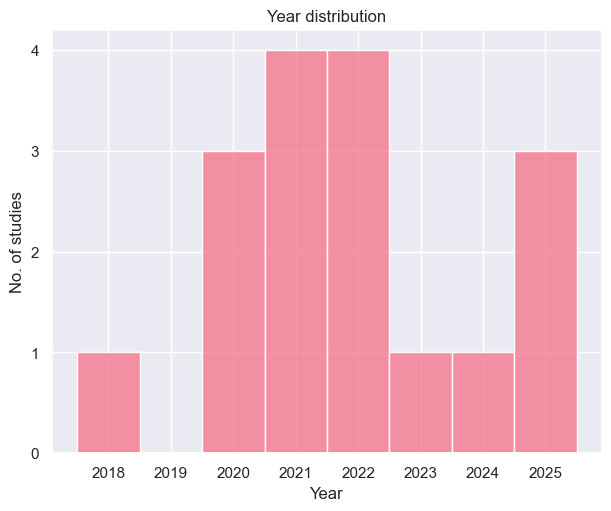

In [15]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.histplot(df['year'], bins=df['year'].nunique(), discrete=True, kde=False, ax=ax)
ax.set_title('Year distribution')
ax.set_xlabel('Year')
ax.set_ylabel('No. of studies')
ax.set_yticks(np.arange(0, 5, 1))
plt.show()

## Region counts

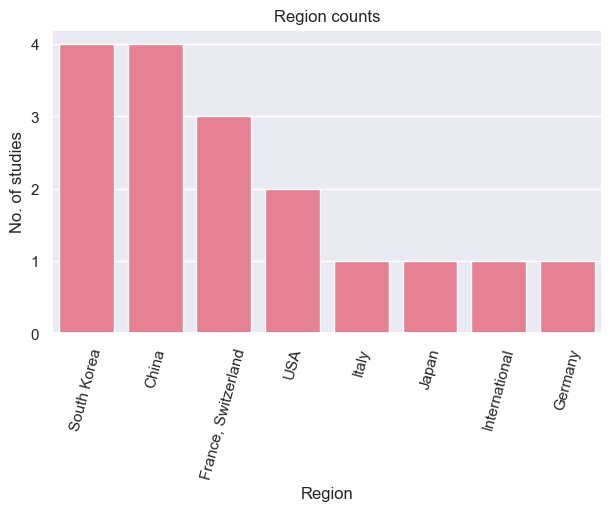

In [16]:
region_counts = df['region'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.barplot(x=region_counts.index, y=region_counts.values, ax=ax)
ax.set_title('Region counts')
ax.set_xlabel('Region')
ax.set_ylabel('No. of studies')
ax.set_yticks(np.arange(0, 5, 1))
ax.tick_params(axis='x', rotation=75)
plt.show()

## Sample sizes

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\87013399.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75)


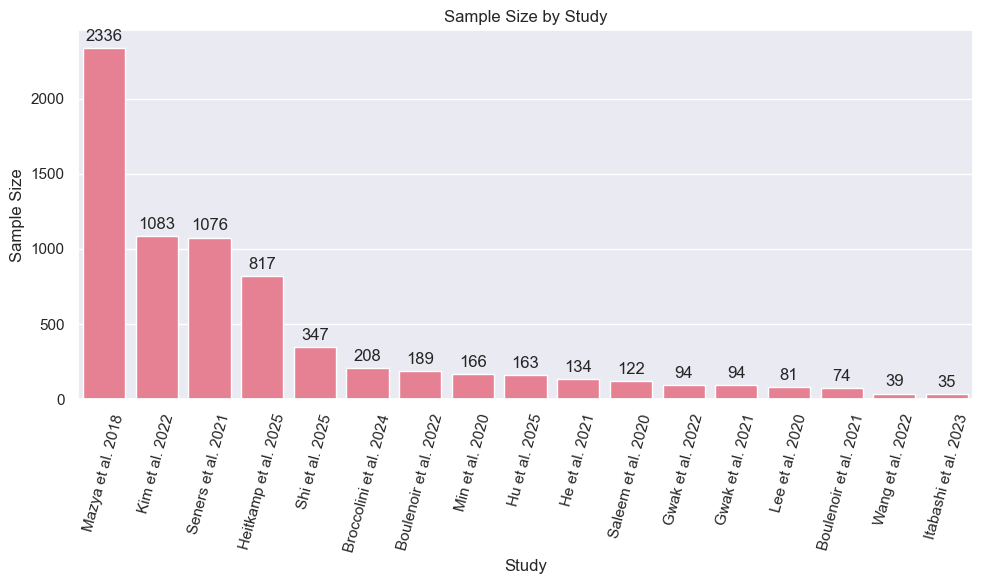

In [17]:
df_sorted = df.sort_values('sample_size', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='display_name', y='sample_size', data=df_sorted, ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=75)
ax.set_title('Sample Size by Study')
ax.set_xlabel('Study')
ax.set_ylabel('Sample Size')
ax.bar_label(ax.containers[0], padding=3)

fig.tight_layout()
plt.show()

## Imaging method

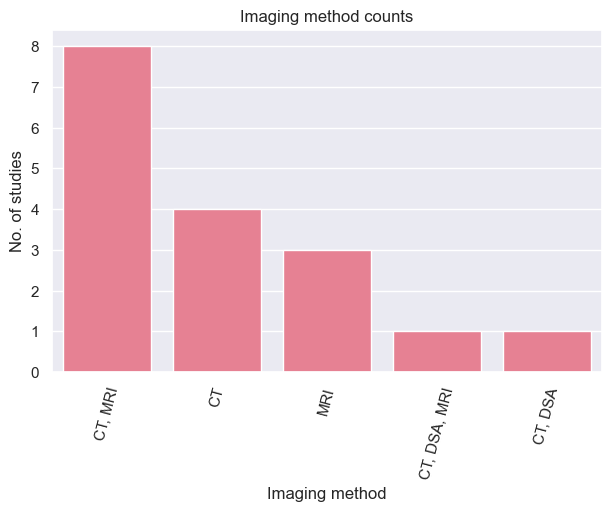

In [18]:
imaging_counts = df['imaging_method'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.barplot(x=imaging_counts.index, y=imaging_counts.values, ax=ax)
ax.set_title('Imaging method counts')
ax.set_xlabel('Imaging method')
ax.set_ylabel('No. of studies')
ax.tick_params(axis='x', rotation=75)

plt.show()

Vizualise it a bit better

In [19]:
# Split into a list, then clean whitespace using a list comprehension
df['imaging_method_list'] = df['imaging_method'].str.split(',').apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)

In [20]:
# .explode creates a new row for every item in the set, but keeps the 'authors' and other data attached.
df_imaging_method = df.explode('imaging_method_list')

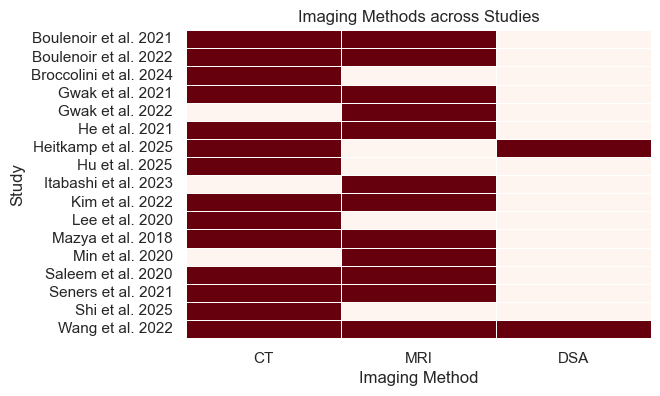

In [21]:
imaging_order = ['CT', 'MRI', 'DSA']

# Create the matrix 
imaging_matrix = pd.crosstab(
    df_imaging_method['display_name'], 
    df_imaging_method['imaging_method_list']
)

imaging_matrix = imaging_matrix.reindex(columns=imaging_order, fill_value=0)

plt.figure(figsize=(6, 4))
sns.heatmap(imaging_matrix, annot=False, cmap="Reds", cbar=False, linewidths=.5)
plt.title('Imaging Methods across Studies')
plt.xlabel('Imaging Method')
plt.ylabel('Study')
plt.xticks(rotation=0)
plt.show()

In [22]:
df_imaging_method[df_imaging_method['primary_evt'] == 'Yes'][['display_name', 'imaging_method_list', 'primary_evt']]

,display_name,imaging_method_list,primary_evt
8,Kim et al. 2022,CT,Yes
8,Kim et al. 2022,MRI,Yes
16,Heitkamp et al. 2025,CT,Yes
16,Heitkamp et al. 2025,DSA,Yes


## Region + Sample sizes + Imaging method

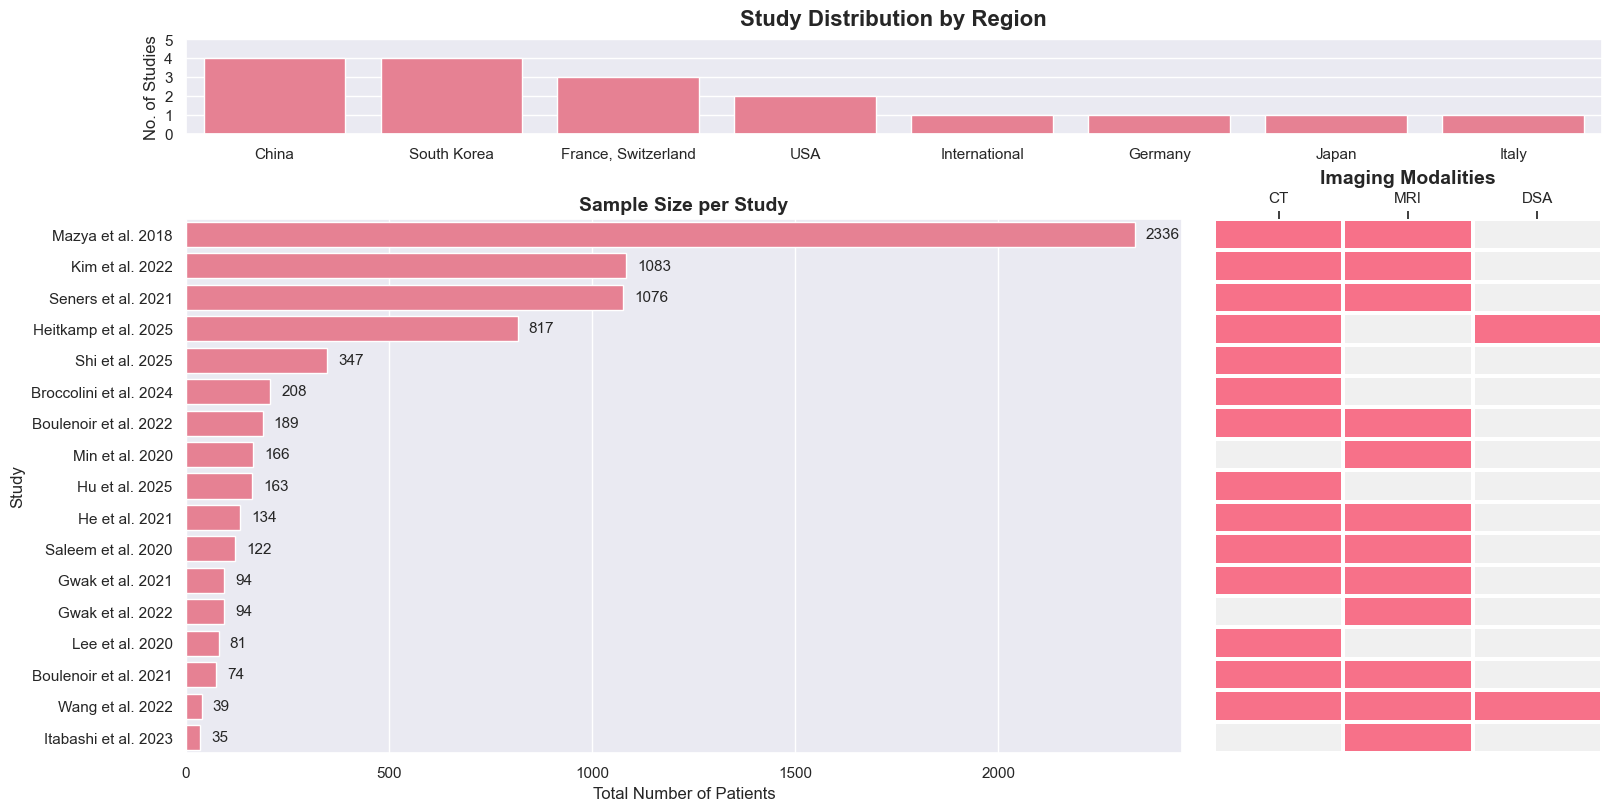

In [92]:
import matplotlib.gridspec as gridspec

# 0. CLEANING & SETTINGS
df.columns = df.columns.str.strip().str.lower()
base_color = sns.color_palette("husl", n_colors=12)[0]

# 1. PREPARE DATA
region_counts = df['region'].value_counts().sort_values(ascending=False)
df_sorted = df.sort_values('sample_size', ascending=False)

df_temp = df.copy()
df_temp['imaging_method_list'] = df_temp['imaging_method'].str.split(',').apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)
df_exploded = df_temp.explode('imaging_method_list')

imaging_matrix = pd.crosstab(
    df_exploded['display_name'], 
    df_exploded['imaging_method_list']
)

imaging_order = ['CT', 'MRI', 'DSA']
imaging_matrix = imaging_matrix.reindex(columns=imaging_order, fill_value=0)
imaging_matrix = imaging_matrix.reindex(df_sorted['display_name'], fill_value=0)

# 2. THE COMBINED PLOT
fig = plt.figure(figsize=(16, 8), constrained_layout=True)

# UPDATED PROPORTIONS HERE:
# height_ratios: [15% top, 85% bottom]
# width_ratios: [72% left chart, 28% right heatmap]
gs = gridspec.GridSpec(2, 2, height_ratios=[0.15, 0.85], width_ratios=[0.72, 0.28], figure=fig)

# --- TOP: Region Counts (Compressed) ---
ax0 = fig.add_subplot(gs[0, :])
sns.barplot(x=region_counts.index, y=region_counts.values, color=base_color, ax=ax0)
ax0.set_title('Study Distribution by Region', fontsize=16, fontweight='bold', pad=10)
ax0.set_ylabel('No. of Studies')
ax0.set_xlabel('') # Removed to save space
ax0.set_yticks(np.arange(0, region_counts.max() + 2, 1))

# --- BOTTOM LEFT: Sample Size (Expanded) ---
ax1 = fig.add_subplot(gs[1, 0])
sns.barplot(x='sample_size', y='display_name', data=df_sorted, color=base_color, ax=ax1)
ax1.set_title('Sample Size per Study', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Number of Patients')
ax1.set_ylabel('Study')
ax1.bar_label(ax1.containers[0], padding=8, fontsize=11) # Slightly larger font for expanded space

# --- BOTTOM RIGHT: Imaging Methods (Narrower) ---
ax2 = fig.add_subplot(gs[1, 1])
sns.heatmap(imaging_matrix, annot=False, cmap=['#f0f0f0', base_color], 
            cbar=False, linewidths=1.5, linecolor='white', ax=ax2)
ax2.set_title('Imaging Modalities', fontsize=14, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_yticklabels([]) 
ax2.xaxis.tick_top() 
ax2.xaxis.set_label_position('top')

# 3. SAVE & SHOW
plt.savefig("Study_Summary_Dashboard_Optimized.pdf", bbox_inches='tight')
plt.show()

## Minor stroke Definition

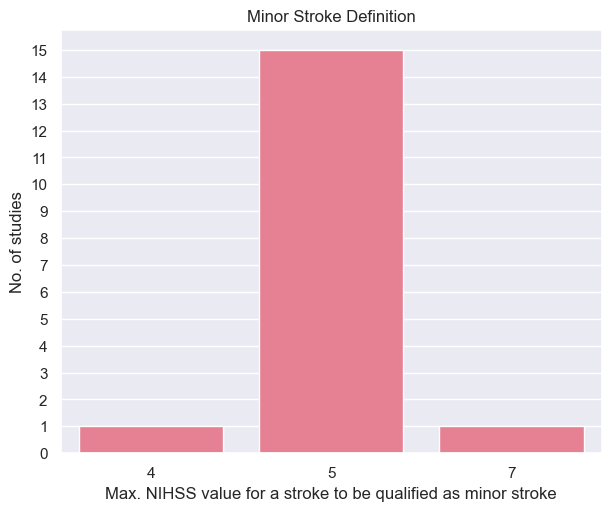

In [23]:
ms_max_nihss_counts = df['ms_max_nihss'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.barplot(x=ms_max_nihss_counts.index, y=ms_max_nihss_counts.values, ax=ax)
ax.set_title('Minor Stroke Definition')
ax.set_xlabel('Max. NIHSS value for a stroke to be qualified as minor stroke')
ax.set_ylabel('No. of studies')
ax.set_yticks(np.arange(0, ms_max_nihss_counts.max() + 1, 1))
plt.show()

## LVO Definition

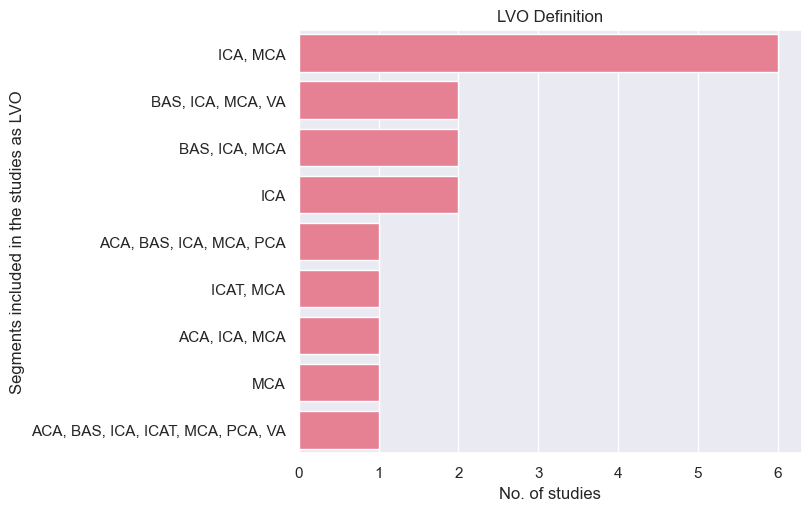

In [24]:
lvo_counts = df['lvo_definition'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.barplot(y=lvo_counts.index, x=lvo_counts.values, ax=ax, orient='h')
ax.set_title('LVO Definition')
ax.set_ylabel('Segments included in the studies as LVO')
ax.set_xlabel('No. of studies')
ax.tick_params(axis='y', rotation=0)
plt.show()

Better vizualisation

In [25]:
# Split into a list, then clean whitespace using a list comprehension
df['lvo_definition_list'] = df['lvo_definition'].str.split(',').apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)

In [26]:
# .explode creates a new row for every item in the set, but keeps the 'authors' and other data attached.
df_lvo_definition = df.explode('lvo_definition_list')

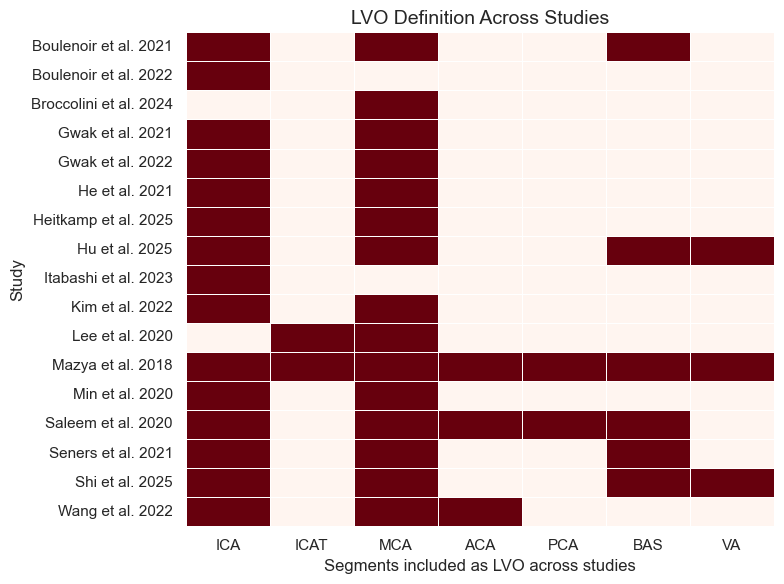

In [27]:
lvo_order = ['ICA', 'ICAT', 'MCA', 'ACA', 'PCA', 'BAS', 'VA']

lvo_definition_matrix = pd.crosstab(
    df_lvo_definition['display_name'], 
    df_lvo_definition['lvo_definition_list']
)

lvo_definition_matrix = lvo_definition_matrix.reindex(columns=lvo_order, fill_value=0)

plt.figure(figsize=(8, 6)) 
sns.heatmap(lvo_definition_matrix, annot=False, cmap="Reds", cbar=False, linewidths=.5)

ax = plt.gca() # Get current axis for formatting
ax.set_title('LVO Definition Across Studies', fontsize=14)
ax.set_xlabel('Segments included as LVO across studies')
ax.set_ylabel('Study', fontsize=12)

# Ensure X labels are clean and not rotated if they are short like 'ICA'
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

## END Definition

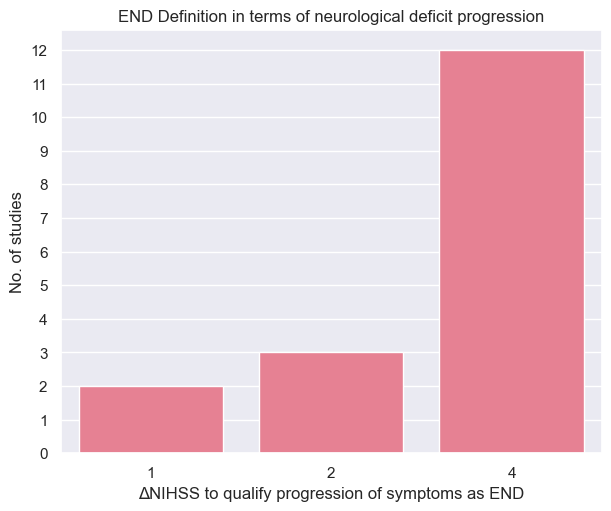

In [28]:
end_delta_nihss_counts = df['end_delta_nihss'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.barplot(x=end_delta_nihss_counts.index, y=end_delta_nihss_counts.values, ax=ax)
ax.set_title('END Definition in terms of neurological deficit progression')
ax.set_xlabel('ΔNIHSS to qualify progression of symptoms as END')
ax.set_ylabel('No. of studies')
ax.set_yticks(np.arange(0, end_delta_nihss_counts.max() + 1, 1))
plt.show()

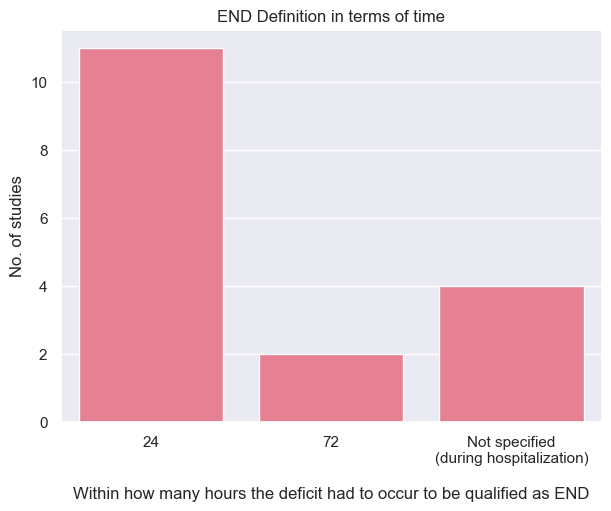

In [29]:
end_hours_counts = df['end_hours'].value_counts(dropna=False).sort_index()

# Prepare labels: replace NaN with custom label, others as int/str
end_hours_labels = []
for x in end_hours_counts.index:
    if pd.isna(x):
        end_hours_labels.append('Not specified\n(during hospitalization)')
    else:
        end_hours_labels.append(str(int(x)) if x == int(x) else str(x))

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.barplot(x=end_hours_labels, y=end_hours_counts.values, ax=ax)
ax.set_title('END Definition in terms of time')
ax.set_xlabel('Within how many hours the deficit had to occur to be qualified as END', labelpad=15)
ax.set_ylabel('No. of studies')
plt.show()

## END Percentage

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\808037387.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75)


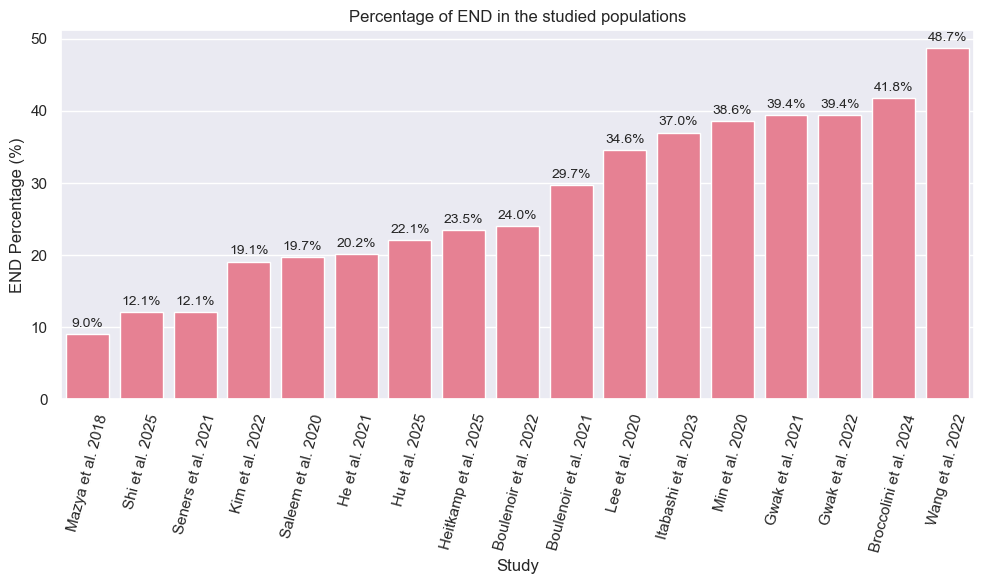

In [30]:
df_sorted = df.sort_values('pct_end')

df_sorted = df.sort_values('pct_end').copy()
df_sorted['pct_end_pct'] = df_sorted['pct_end'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='display_name', y='pct_end_pct', data=df_sorted, ax=ax, errorbar=None)

ax.set_xticklabels(ax.get_xticklabels(), rotation=75)
ax.set_title('Percentage of END in the studied populations')
ax.set_xlabel('Study')
ax.set_ylabel('END Percentage (%)')
ax.bar_label(ax.containers[0], padding=3, fmt='%.1f%%', fontsize=10)

fig.tight_layout()
plt.show()

## IVT

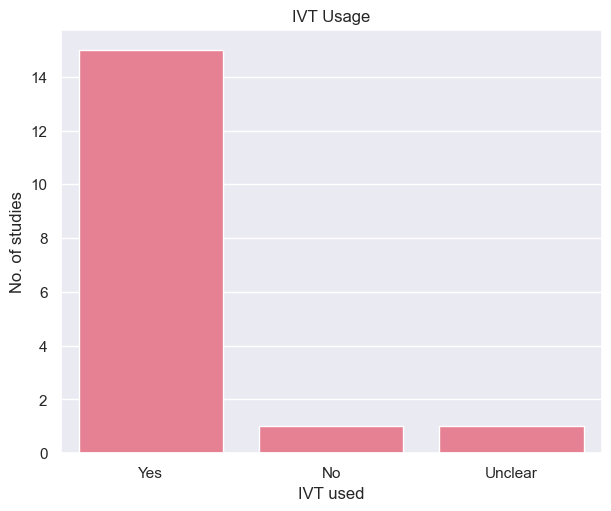

In [31]:
ivt_order = ['Yes', 'No', 'Unclear']
ivt_counts = df['ivt'].value_counts().reindex(ivt_order).fillna(0)

fig4, ax4 = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.barplot(x=ivt_counts.index, y=ivt_counts.values, ax=ax4, order=ivt_order)
ax4.set_title('IVT Usage')
ax4.set_xlabel('IVT used')
ax4.set_ylabel('No. of studies')
plt.show()

In [32]:
df_sorted = df.sort_values('pct_ivt').copy()
print(len(df_sorted.pct_ivt))
print('NAs:', df_sorted.pct_ivt.isna().sum())
df_sorted.pct_ivt

17
NAs: 1


3     0.0000
8     0.1080
9     0.1140
1     0.2540
15    0.2612
12    0.2980
11    0.2980
16    0.4100
2     0.4470
14    0.5000
7     0.6400
4     1.0000
5     1.0000
6     1.0000
10    1.0000
13    1.0000
0        NaN
Name: pct_ivt, dtype: float64

In [33]:
df_sorted['pct_ivt_pct'] = df_sorted['pct_ivt'] * 100
print(len(df_sorted.pct_ivt_pct))
print('NAs:', df_sorted.pct_ivt_pct.isna().sum())
df_sorted.pct_ivt_pct

17
NAs: 1


3       0.00
8      10.80
9      11.40
1      25.40
15     26.12
12     29.80
11     29.80
16     41.00
2      44.70
14     50.00
7      64.00
4     100.00
5     100.00
6     100.00
10    100.00
13    100.00
0        NaN
Name: pct_ivt_pct, dtype: float64

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\4167194927.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75)


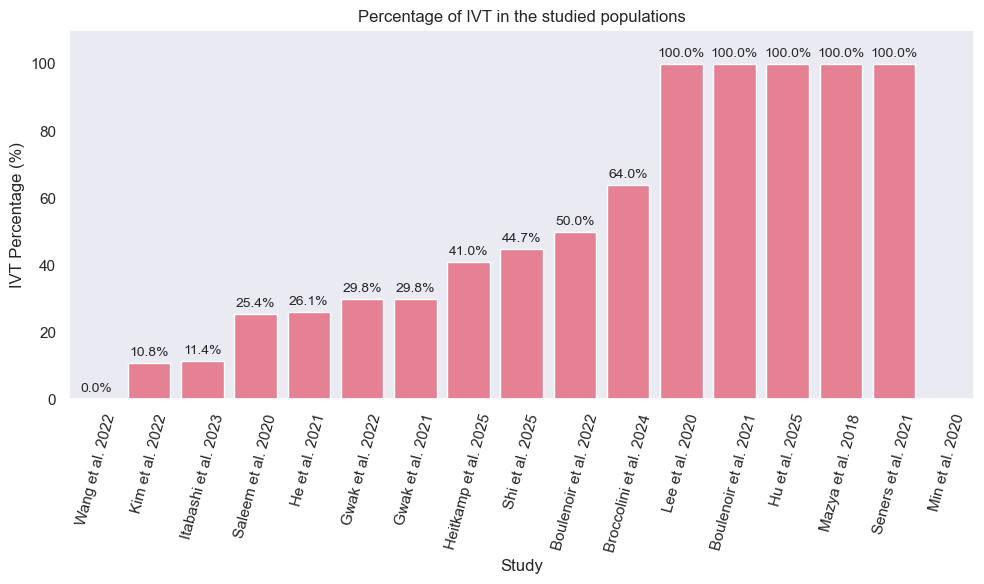

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='display_name', y='pct_ivt_pct', data=df_sorted, ax=ax, errorbar=None)

ax.set_xticklabels(ax.get_xticklabels(), rotation=75)
ax.set_title('Percentage of IVT in the studied populations')
ax.set_xlabel('Study')
ax.set_ylabel('IVT Percentage (%)')
ax.bar_label(ax.containers[0], padding=3, fmt='%.1f%%', fontsize=10)
ax.grid(False)
ax.set_ylim(0, df_sorted['pct_ivt_pct'].max() * 1.1)

fig.tight_layout()
plt.show()

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\158615272.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='display_name', y='pct_ivt_pct', data=df_sorted, ax=ax, errorbar=None, palette=colors)
C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\158615272.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75)


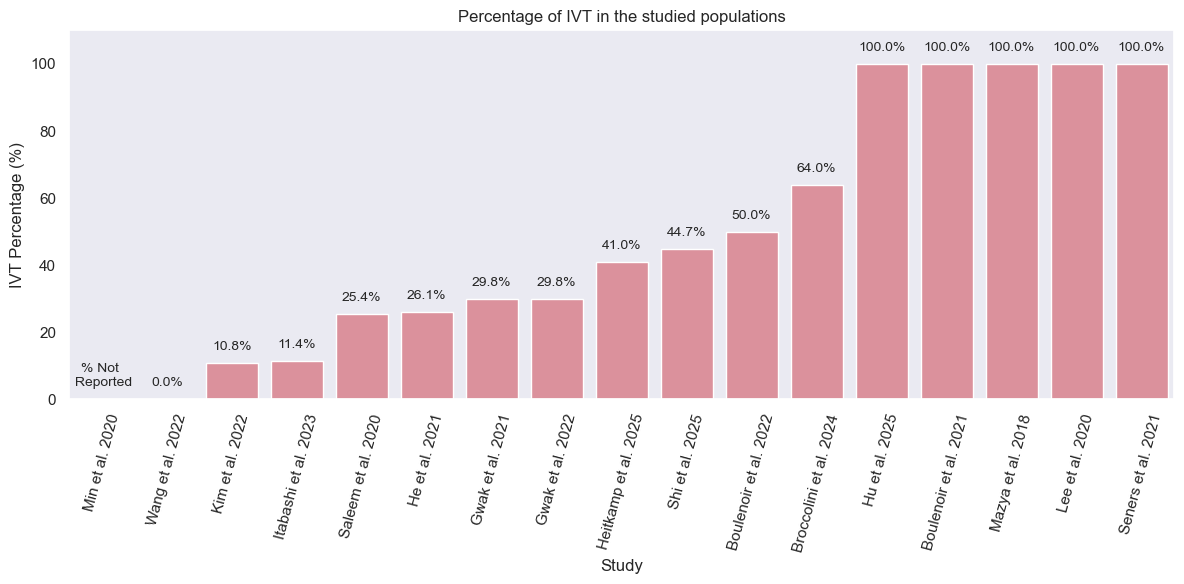

In [35]:
# 1. Final Data Prep (Force reset index to ensure alignment)
df_sorted = df.copy()
df_sorted['display_name'] = df_sorted['authors'] + ' ' + df_sorted['year'].astype(str)
df_sorted['pct_ivt_filled'] = df_sorted['pct_ivt'].fillna(0)
df_sorted['pct_ivt_pct'] = df_sorted['pct_ivt_filled'] * 100
df_sorted = df_sorted.sort_values('pct_ivt_pct').reset_index(drop=True)

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
# We use 'hue' to match the colors list to avoid warnings
colors = ['lightgray' if np.isnan(x) else '#e88493' for x in df_sorted['pct_ivt']]

sns.barplot(x='display_name', y='pct_ivt_pct', data=df_sorted, ax=ax, errorbar=None, palette=colors)

# 3. MANUAL LABELING (The most robust way)
# This loops through each bar (patch) and each label together
for i, bar in enumerate(ax.patches):
    # Get the original value to check for NaN
    orig_val = df_sorted.loc[i, 'pct_ivt']
    pct_val = df_sorted.loc[i, 'pct_ivt_pct']
    
    label = f'{pct_val:.1f}%' if not np.isnan(orig_val) else '% Not \n Reported'
    
    # Get the height of the bar to place the text
    height = bar.get_height()
    
    ax.text(
        bar.get_x() + bar.get_width()/2., # X position: middle of the bar
        height + 3,                       # Y position: top of bar + padding
        label, 
        ha='center', 
        va='bottom', 
        rotation=0, 
        fontsize=10
    )

# 4. Formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=75)
ax.set_title('Percentage of IVT in the studied populations')
ax.set_xlabel('Study')
ax.set_ylabel('IVT Percentage (%)')
ax.set_ylim(0, df_sorted['pct_ivt_pct'].max() * 1.1)
ax.grid(False)

plt.tight_layout()
plt.show()

## Primary EVT

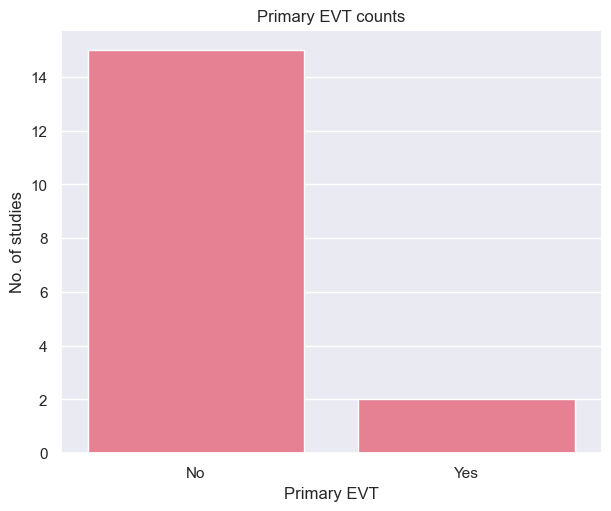

In [36]:
# 1. Final Data Prep
df_sorted = df.copy()
df_sorted['display_name'] = df_sorted['authors'] + ' ' + df_sorted['year'].astype(str)
df_sorted = df_sorted.sort_values('primary_evt').reset_index(drop=True)

# 2. Get value counts
primary_evt_counts = df_sorted['primary_evt'].value_counts().sort_values(ascending=False)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.barplot(x=primary_evt_counts.index, y=primary_evt_counts.values, ax=ax)
ax.set_title('Primary EVT counts')
ax.set_xlabel('Primary EVT')
ax.set_ylabel('No. of studies')
ax.tick_params(axis='x', rotation=0)

plt.show()

## Rescue EVT

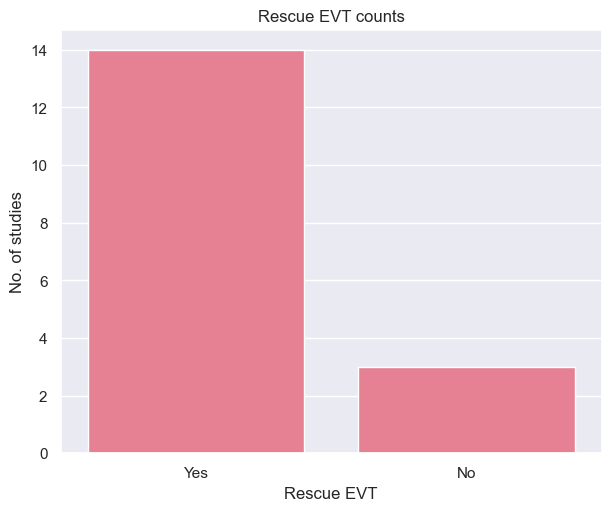

In [37]:
rescue_evt_counts = df['rescue_evt'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.barplot(x=rescue_evt_counts.index, y=rescue_evt_counts.values, ax=ax)
ax.set_title('Rescue EVT counts')
ax.set_xlabel('Rescue EVT')
ax.set_ylabel('No. of studies')
ax.tick_params(axis='x', rotation=0)

plt.show()

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\2971633023.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='display_name', y='pct_rescue_evt_end_pct', data=df_sorted, ax=ax, errorbar=None, palette=colors)
C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\2971633023.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75)


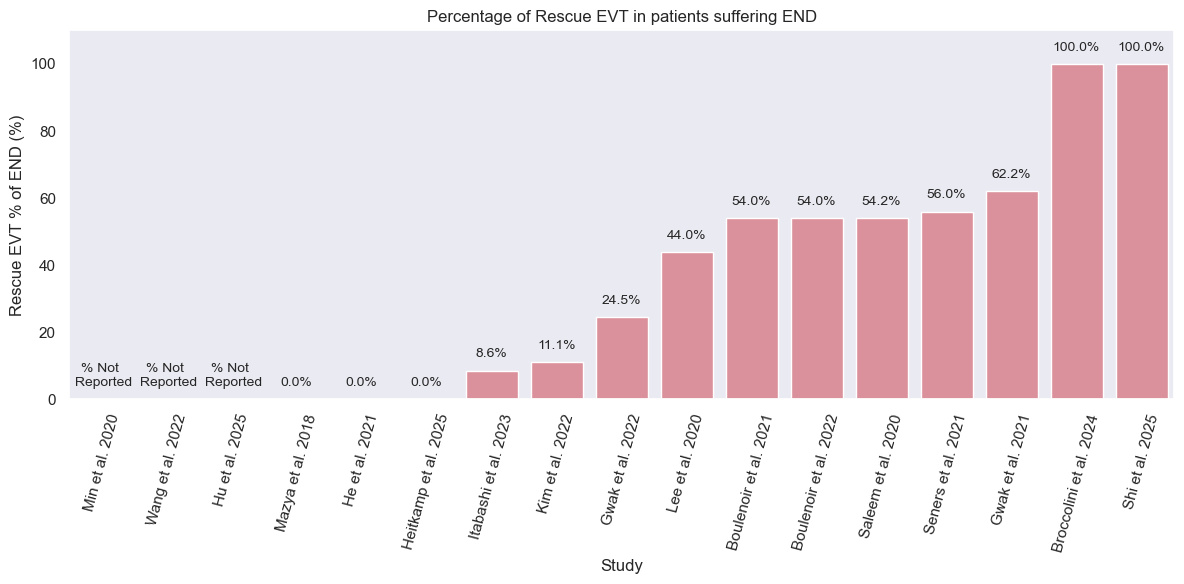

In [38]:
# 1. Final Data Prep (Force reset index to ensure alignment)
df_sorted = df.copy()
df_sorted['display_name'] = df_sorted['authors'] + ' ' + df_sorted['year'].astype(str)
df_sorted['pct_rescue_evt_end_filled'] = df_sorted['pct_rescue_evt_end'].fillna(0)
df_sorted['pct_rescue_evt_end_pct'] = df_sorted['pct_rescue_evt_end_filled'] * 100
df_sorted = df_sorted.sort_values('pct_rescue_evt_end_pct').reset_index(drop=True)

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
# We use 'hue' to match the colors list to avoid warnings
colors = ['lightgray' if np.isnan(x) else '#e88493' for x in df_sorted['pct_rescue_evt_end']]

sns.barplot(x='display_name', y='pct_rescue_evt_end_pct', data=df_sorted, ax=ax, errorbar=None, palette=colors)

# 3. MANUAL LABELING (The most robust way)
# This loops through each bar (patch) and each label together
for i, bar in enumerate(ax.patches):
    # Get the original value to check for NaN
    orig_val = df_sorted.loc[i, 'pct_rescue_evt_end']
    pct_val = df_sorted.loc[i, 'pct_rescue_evt_end_pct']
    
    label = f'{pct_val:.1f}%' if not np.isnan(orig_val) else '% Not \n Reported'
    
    # Get the height of the bar to place the text
    height = bar.get_height()
    
    ax.text(
        bar.get_x() + bar.get_width()/2., # X position: middle of the bar
        height + 3,                       # Y position: top of bar + padding
        label, 
        ha='center', 
        va='bottom', 
        rotation=0, 
        fontsize=10
    )

# 4. Formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=75)
ax.set_title('Percentage of Rescue EVT in patients suffering END')
ax.set_xlabel('Study')
ax.set_ylabel('Rescue EVT % of END (%)')
ax.set_ylim(0, df_sorted['pct_rescue_evt_end_pct'].max() * 1.1)
ax.grid(False)

plt.tight_layout()
plt.show()

## Predictors / Associated factors

### Clinical predictors - univariable analysis

The following is not too useful

In [39]:
# # count unique values in clinical predictors (univariable)
# clin_uni_counts = df['clinical_predictors_uni'].value_counts(dropna=False)

# fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
# sns.barplot(y=clin_uni_counts.index, x=clin_uni_counts.values, ax=ax, orient='h')
# ax.set_title('Number of studies per unique clinical_predictors_uni value')
# ax.set_ylabel('clinical_predictors_uni')
# ax.set_xlabel('Study count')

# plt.show()


Did some modifications, so that the predictors are as a list and plotted against studies and by frequency count

In [40]:
print(df.clinical_predictors_uni.isna().sum())

0


In [41]:
# Split into a list, then clean whitespace using a list comprehension
df['clinical_predictors_uni_list'] = df['clinical_predictors_uni'].str.split(',').apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)

In [42]:
# .explode creates a new row for every item in the set, but keeps the 'authors' and other data attached.
df_clinical_predictors_uni = df.explode('clinical_predictors_uni_list')

In [43]:
print(df_clinical_predictors_uni.shape)
df_clinical_predictors_uni.head(3)

(32, 37)


,name,title,year,region,study_design_1,study_design_2,sample_size,median_age,mean_age,median_nihss,...,ivt,pct_ivt,primary_evt,rescue_evt,pct_rescue_evt_end,authors,display_name,imaging_method_list,lvo_definition_list,clinical_predictors_uni_list
0,"Min et al., “Acute Insular Infarction: Early O...",Acute insular infarction: Early outcomes of mi...,2020,South Korea,retrospective,single-center,166,NaN,66.0,2.0,...,Unclear,NaN,No,Yes,NaN,Min et al.,Min et al. 2020,[MRI],"[ICA, MCA]",none
1,"Saleem et al., “Acute Neurological Deteriorati...",Acute Neurological Deterioration in Large Vess...,2020,USA,retrospective,single-center,122,NaN,62.0,3.0,...,Yes,0.254,No,Yes,0.542,Saleem et al.,Saleem et al. 2020,"[CT, MRI]","[ACA, BAS, ICA, MCA, PCA]",none
2,"Shi et al., “Association of Blood Pressure Par...",Association of blood pressure parameters on ea...,2025,China,retrospective,single-center,347,NaN,66.9,2.0,...,Yes,0.447,No,Yes,1.000,Shi et al.,Shi et al. 2025,[CT],"[BAS, ICA, MCA, VA]",Higher SBP variability


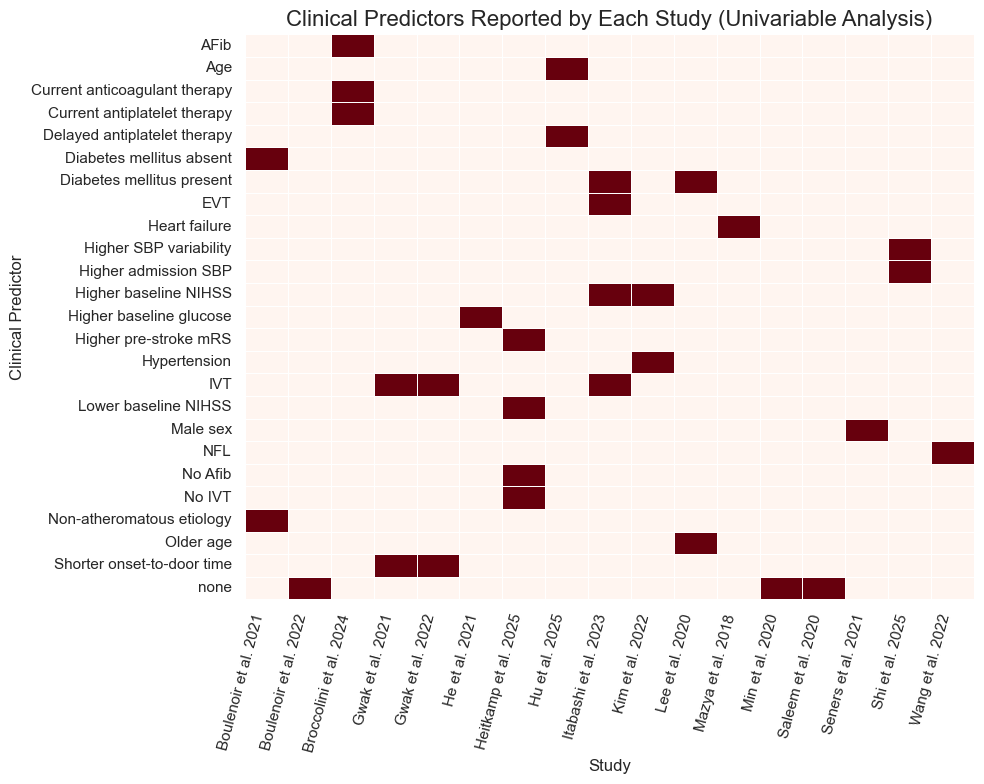

In [44]:
# Create a "Presence Matrix" (1 if study reported it, 0 if not)
matrix1 = pd.crosstab(df_clinical_predictors_uni['clinical_predictors_uni_list'], df_clinical_predictors_uni['display_name'])

# Plotting the matrix1
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix1, annot=False, cmap="Reds", cbar=False, linewidths=.5, ax=ax)

ax.set_title('Clinical Predictors Reported by Each Study (Univariable Analysis)', fontsize=16)
ax.set_xlabel('Study')
ax.set_ylabel('Clinical Predictor')

plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [45]:
clinical_predictors_uni_count = df_clinical_predictors_uni['clinical_predictors_uni_list'].value_counts().reset_index()
clinical_predictors_uni_count.columns = ['Predictor', 'Study_Count']
clinical_predictors_uni_count = clinical_predictors_uni_count.sort_values('Study_Count', ascending=False)

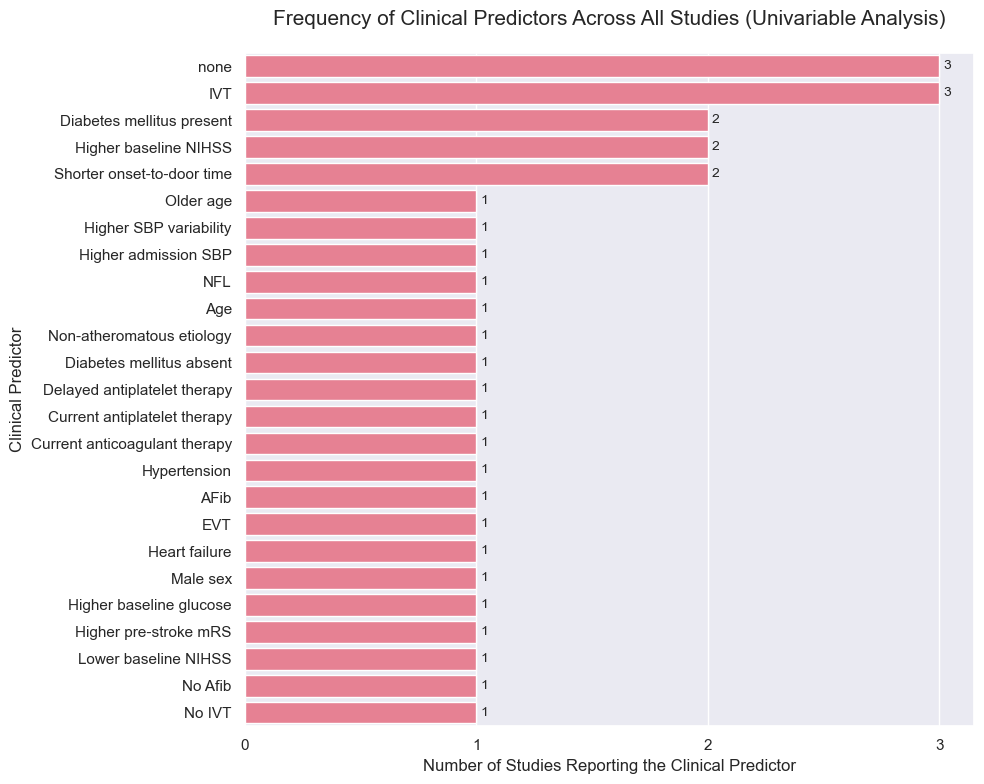

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))

# Create the barplot
sns.barplot(
    x='Study_Count', 
    y='Predictor', 
    data=clinical_predictors_uni_count, 
    ax=ax, 
)

# Add the exact count on the end of each bar
ax.bar_label(ax.containers[0], padding=3, fontsize=10)

# Formatting
ax.set_title('Frequency of Clinical Predictors Across All Studies (Univariable Analysis)', fontsize=15, pad=20)
ax.set_xlabel('Number of Studies Reporting the Clinical Predictor')
ax.set_ylabel('Clinical Predictor')

# Force X-axis to only show whole numbers (since you can't have 1.5 studies)
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### Clinical predictors - multivariable analysis

This is not too useful

In [47]:
# # count unique values in clinical predictors (multivariable)
# clin_multi_counts = df['clinical_predictors_multi'].value_counts(dropna=False)

# fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
# sns.barplot(y=clin_multi_counts.index, x=clin_multi_counts.values, ax=ax, orient='h')
# ax.set_title('Number of studies per unique clinical_predictors_multi value')
# ax.set_ylabel('clinical_predictors_multi')
# ax.set_xlabel('Study count')

# plt.show()

So again made some modifications

In [48]:
print(df.clinical_predictors_multi.isna().sum())

# Split into a list, then clean whitespace using a list comprehension
df['clinical_predictors_multi_list'] = df['clinical_predictors_multi'].str.split(',').apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)

# .explode creates a new row for every item in the set, but keeps the 'authors' and other data attached.
df_clinical_predictors_multi = df.explode('clinical_predictors_multi_list')

print(df_clinical_predictors_multi.shape)
df_clinical_predictors_multi.head(3)

0
(24, 38)


,name,title,year,region,study_design_1,study_design_2,sample_size,median_age,mean_age,median_nihss,...,pct_ivt,primary_evt,rescue_evt,pct_rescue_evt_end,authors,display_name,imaging_method_list,lvo_definition_list,clinical_predictors_uni_list,clinical_predictors_multi_list
0,"Min et al., “Acute Insular Infarction: Early O...",Acute insular infarction: Early outcomes of mi...,2020,South Korea,retrospective,single-center,166,NaN,66.0,2.0,...,NaN,No,Yes,NaN,Min et al.,Min et al. 2020,[MRI],"[ICA, MCA]",[none],none
1,"Saleem et al., “Acute Neurological Deteriorati...",Acute Neurological Deterioration in Large Vess...,2020,USA,retrospective,single-center,122,NaN,62.0,3.0,...,0.254,No,Yes,0.542,Saleem et al.,Saleem et al. 2020,"[CT, MRI]","[ACA, BAS, ICA, MCA, PCA]",[none],none
2,"Shi et al., “Association of Blood Pressure Par...",Association of blood pressure parameters on ea...,2025,China,retrospective,single-center,347,NaN,66.9,2.0,...,0.447,No,Yes,1.000,Shi et al.,Shi et al. 2025,[CT],"[BAS, ICA, MCA, VA]","[Higher SBP variability, Higher admission SBP]",Admission SBP > 150mmHg


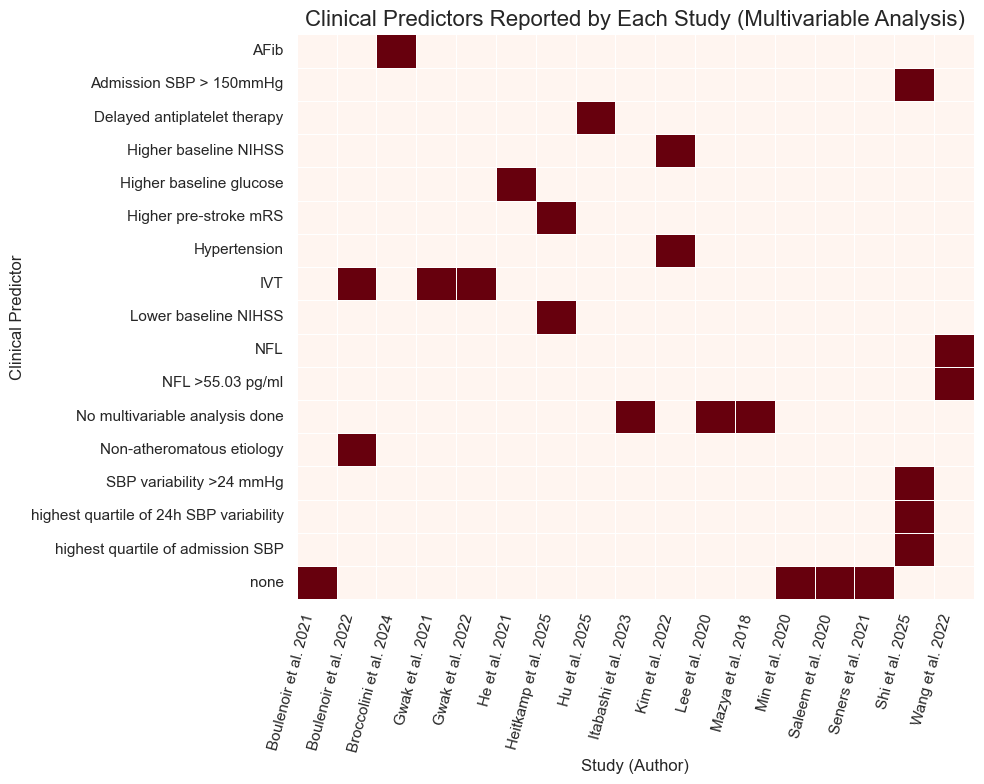

In [49]:
# Create a "Presence Matrix" (1 if study reported it, 0 if not)
matrix2 = pd.crosstab(df_clinical_predictors_multi['clinical_predictors_multi_list'], df_clinical_predictors_multi['display_name'])

# Plotting the matrix2
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix2, annot=False, cmap="Reds", cbar=False, linewidths=.5, ax=ax)

ax.set_title('Clinical Predictors Reported by Each Study (Multivariable Analysis)', fontsize=16)
ax.set_xlabel('Study (Author)')
ax.set_ylabel('Clinical Predictor')

plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [50]:
clinical_predictors_multi_count = df_clinical_predictors_multi['clinical_predictors_multi_list'].value_counts().reset_index()
clinical_predictors_multi_count.columns = ['Predictor', 'Study_Count']
clinical_predictors_multi_count = clinical_predictors_multi_count.sort_values('Study_Count', ascending=False)

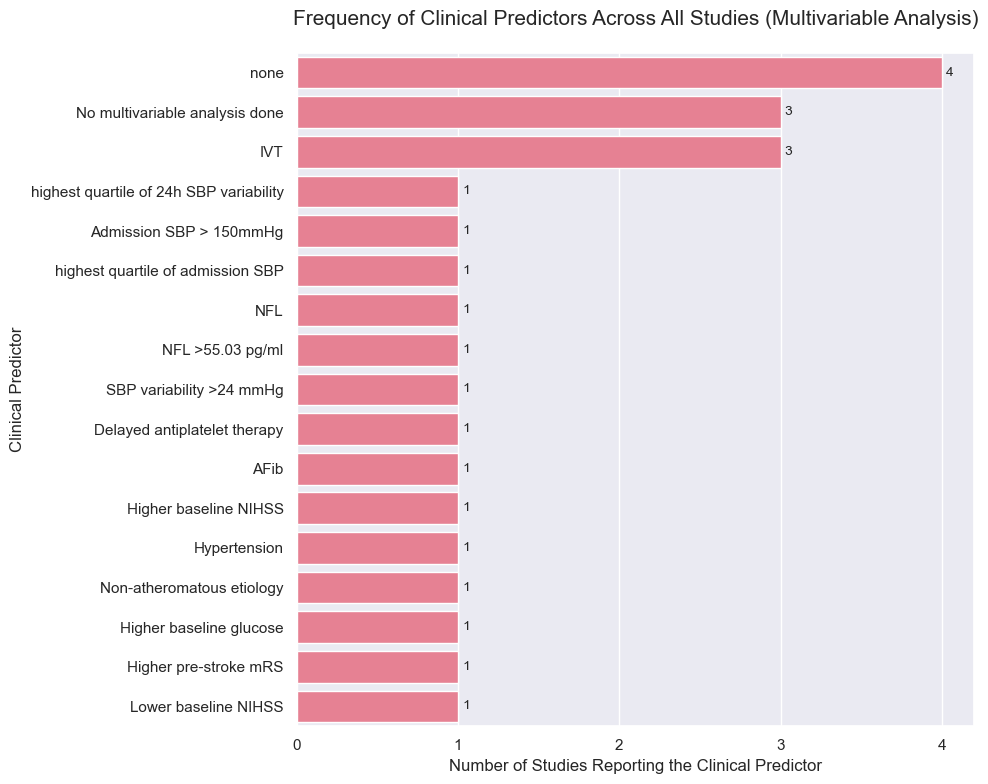

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))

# Create the barplot
sns.barplot(
    x='Study_Count', 
    y='Predictor', 
    data=clinical_predictors_multi_count, 
    ax=ax, 
)

# Add the exact count on the end of each bar
ax.bar_label(ax.containers[0], padding=3, fontsize=10)

# Formatting
ax.set_title('Frequency of Clinical Predictors Across All Studies (Multivariable Analysis)', fontsize=15, pad=20)
ax.set_xlabel('Number of Studies Reporting the Clinical Predictor')
ax.set_ylabel('Clinical Predictor')

# Force X-axis to only show whole numbers (since you can't have 1.5 studies)
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### Radiological predictors - univariable analysis

This again - not useful

In [52]:
# # count unique values in radiological predictors (univariable)
# radio_uni_counts = df['radiological_predictors_uni'].value_counts(dropna=False)

# fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
# sns.barplot(y=radio_uni_counts.index, x=radio_uni_counts.values, ax=ax, orient='h')
# ax.set_title('Number of studies per unique radiological_predictors_uni value')
# ax.set_ylabel('radiological_predictors_uni')
# ax.set_xlabel('Study count')

# plt.show()


Made some modifications for better vizualisation

In [53]:
print(df.radiological_predictors_uni.isna().sum())

# Split into a list, then clean whitespace using a list comprehension
df['radiological_predictors_uni_list'] = df['radiological_predictors_uni'].str.split(',').apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)

# .explode creates a new row for every item in the set, but keeps the 'authors' and other data attached.
df_radiological_predictors_uni = df.explode('radiological_predictors_uni_list')

print(df_radiological_predictors_uni.shape)
df_radiological_predictors_uni.head(3)

0
(31, 39)


,name,title,year,region,study_design_1,study_design_2,sample_size,median_age,mean_age,median_nihss,...,primary_evt,rescue_evt,pct_rescue_evt_end,authors,display_name,imaging_method_list,lvo_definition_list,clinical_predictors_uni_list,clinical_predictors_multi_list,radiological_predictors_uni_list
0,"Min et al., “Acute Insular Infarction: Early O...",Acute insular infarction: Early outcomes of mi...,2020,South Korea,retrospective,single-center,166,NaN,66.0,2.0,...,No,Yes,NaN,Min et al.,Min et al. 2020,[MRI],"[ICA, MCA]",[none],[none],none
1,"Saleem et al., “Acute Neurological Deteriorati...",Acute Neurological Deterioration in Large Vess...,2020,USA,retrospective,single-center,122,NaN,62.0,3.0,...,No,Yes,0.542,Saleem et al.,Saleem et al. 2020,"[CT, MRI]","[ACA, BAS, ICA, MCA, PCA]",[none],[none],none
2,"Shi et al., “Association of Blood Pressure Par...",Association of blood pressure parameters on ea...,2025,China,retrospective,single-center,347,NaN,66.9,2.0,...,No,Yes,1.000,Shi et al.,Shi et al. 2025,[CT],"[BAS, ICA, MCA, VA]","[Higher SBP variability, Higher admission SBP]","[Admission SBP > 150mmHg, SBP variability >24 ...",Higher Tmax>6s volume


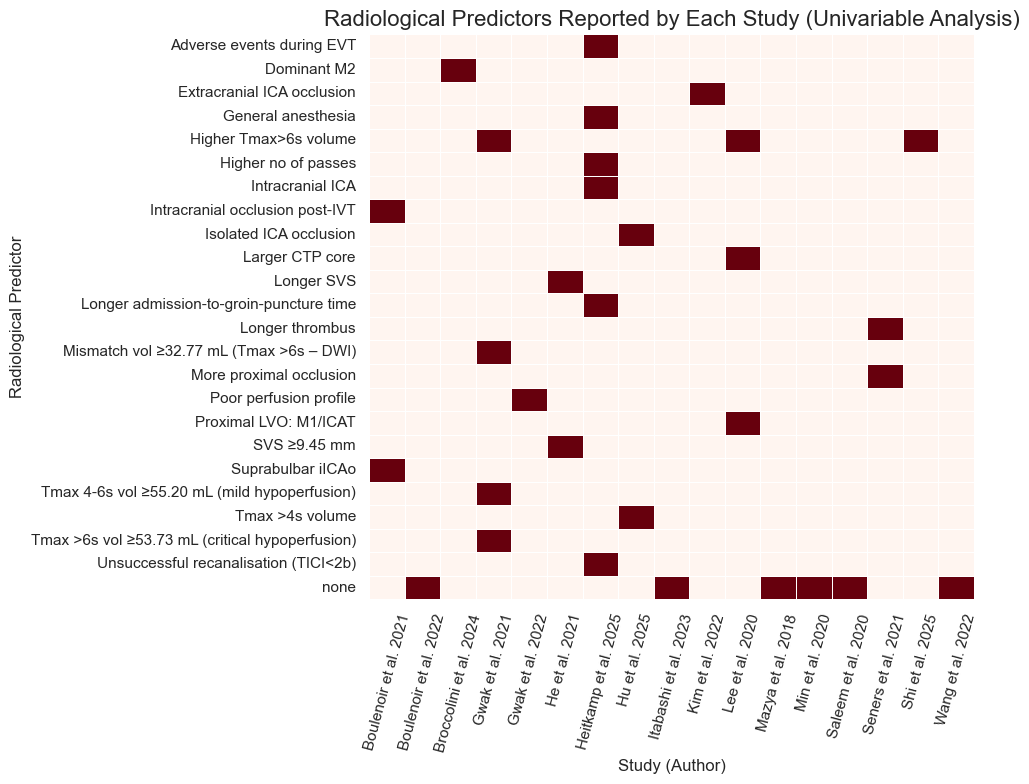

In [54]:
# Create a "Presence Matrix" (1 if study reported it, 0 if not)
matrix3 = pd.crosstab(df_radiological_predictors_uni['radiological_predictors_uni_list'], df_radiological_predictors_uni['display_name'])

# Plotting the matrix3
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix3, annot=False, cmap="Reds", cbar=False, linewidths=.5, ax=ax)

ax.set_title('Radiological Predictors Reported by Each Study (Univariable Analysis)', fontsize=16)
ax.set_xlabel('Study (Author)')
ax.set_ylabel('Radiological Predictor')

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [55]:
radiological_predictors_uni_count = df_radiological_predictors_uni['radiological_predictors_uni_list'].value_counts().reset_index()
radiological_predictors_uni_count.columns = ['Predictor', 'Study_Count']
radiological_predictors_uni_count = radiological_predictors_uni_count.sort_values('Study_Count', ascending=False)

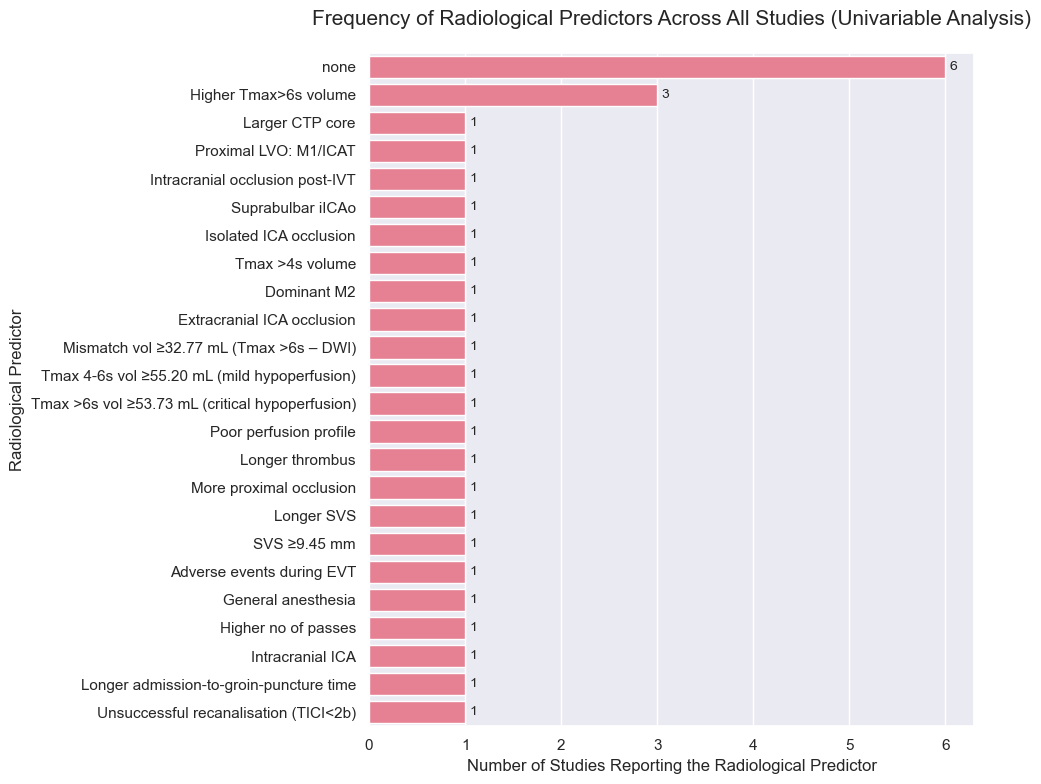

In [56]:
fig, ax = plt.subplots(figsize=(10, 8))

# Create the barplot
sns.barplot(
    x='Study_Count', 
    y='Predictor', 
    data=radiological_predictors_uni_count, 
    ax=ax, 
)

# Add the exact count on the end of each bar
ax.bar_label(ax.containers[0], padding=3, fontsize=10)

# Formatting
ax.set_title('Frequency of Radiological Predictors Across All Studies (Univariable Analysis)', fontsize=15, pad=20)
ax.set_xlabel('Number of Studies Reporting the Radiological Predictor')
ax.set_ylabel('Radiological Predictor')

# Force X-axis to only show whole numbers (since you can't have 1.5 studies)
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### Radiological predictors - multivariable analysis

This is also not useful

In [57]:
# # count unique values in radiological predictors (univariable)
# radio_multi_counts = df['radiological_predictors_multi'].value_counts(dropna=False)

# fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
# sns.barplot(y=radio_multi_counts.index, x=radio_multi_counts.values, ax=ax, orient='h')
# ax.set_title('Number of studies per unique radiological_predictors_multi value')
# ax.set_ylabel('radiological_predictors_multi')
# ax.set_xlabel('Study count')

# plt.show()

So, modified it for better visualization

In [58]:
print(df.radiological_predictors_multi.isna().sum())

# Split into a list, then clean whitespace using a list comprehension
df['radiological_predictors_multi_list'] = df['radiological_predictors_multi'].str.split(',').apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)

# .explode creates a new row for every item in the set, but keeps the 'authors' and other data attached.
df_radiological_predictors_multi = df.explode('radiological_predictors_multi_list')

print(df_radiological_predictors_multi.shape)
df_radiological_predictors_multi.head(3)

0
(27, 40)


,name,title,year,region,study_design_1,study_design_2,sample_size,median_age,mean_age,median_nihss,...,rescue_evt,pct_rescue_evt_end,authors,display_name,imaging_method_list,lvo_definition_list,clinical_predictors_uni_list,clinical_predictors_multi_list,radiological_predictors_uni_list,radiological_predictors_multi_list
0,"Min et al., “Acute Insular Infarction: Early O...",Acute insular infarction: Early outcomes of mi...,2020,South Korea,retrospective,single-center,166,NaN,66.0,2.0,...,Yes,NaN,Min et al.,Min et al. 2020,[MRI],"[ICA, MCA]",[none],[none],[none],Insular lesions
1,"Saleem et al., “Acute Neurological Deteriorati...",Acute Neurological Deterioration in Large Vess...,2020,USA,retrospective,single-center,122,NaN,62.0,3.0,...,Yes,0.542,Saleem et al.,Saleem et al. 2020,"[CT, MRI]","[ACA, BAS, ICA, MCA, PCA]",[none],[none],[none],none
2,"Shi et al., “Association of Blood Pressure Par...",Association of blood pressure parameters on ea...,2025,China,retrospective,single-center,347,NaN,66.9,2.0,...,Yes,1.000,Shi et al.,Shi et al. 2025,[CT],"[BAS, ICA, MCA, VA]","[Higher SBP variability, Higher admission SBP]","[Admission SBP > 150mmHg, SBP variability >24 ...",[Higher Tmax>6s volume],Tmax>6s volume - highest quartile


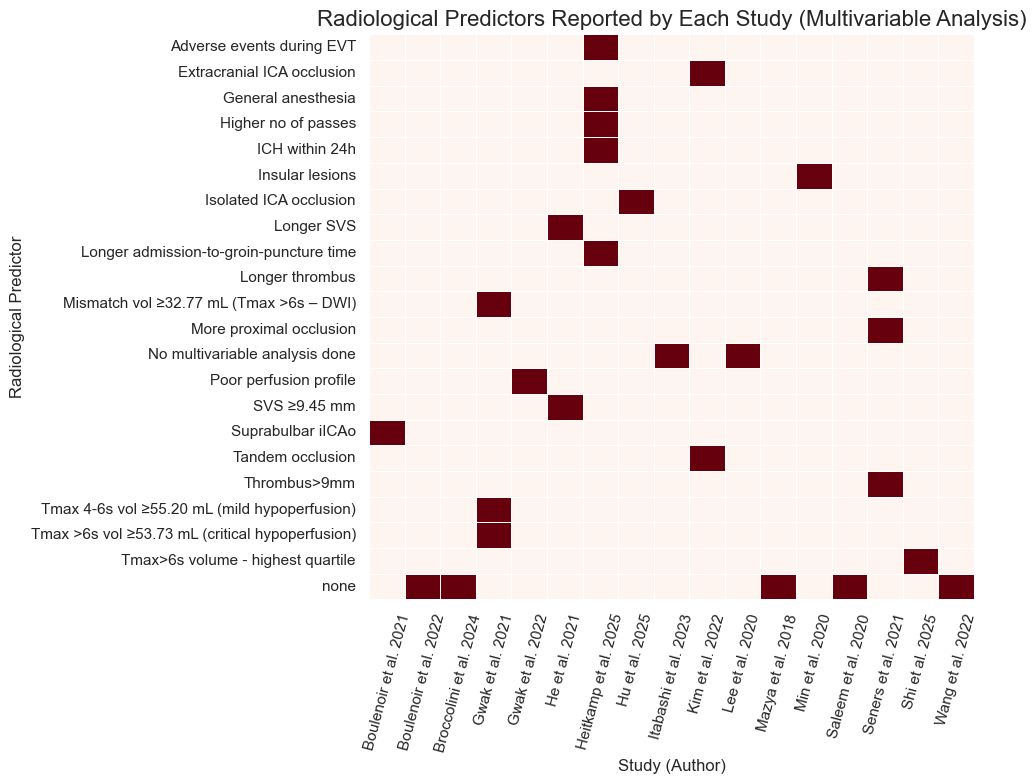

In [59]:
# Create a "Presence Matrix" (1 if study reported it, 0 if not)
matrix3 = pd.crosstab(df_radiological_predictors_multi['radiological_predictors_multi_list'], df_radiological_predictors_multi['display_name'])

# Plotting the matrix3
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix3, annot=False, cmap="Reds", cbar=False, linewidths=.5, ax=ax)

ax.set_title('Radiological Predictors Reported by Each Study (Multivariable Analysis)', fontsize=16)
ax.set_xlabel('Study (Author)')
ax.set_ylabel('Radiological Predictor')

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [60]:
radiological_predictors_multi_count = df_radiological_predictors_multi['radiological_predictors_multi_list'].value_counts().reset_index()
radiological_predictors_multi_count.columns = ['Predictor', 'Study_Count']
radiological_predictors_multi_count = radiological_predictors_multi_count.sort_values('Study_Count', ascending=False)

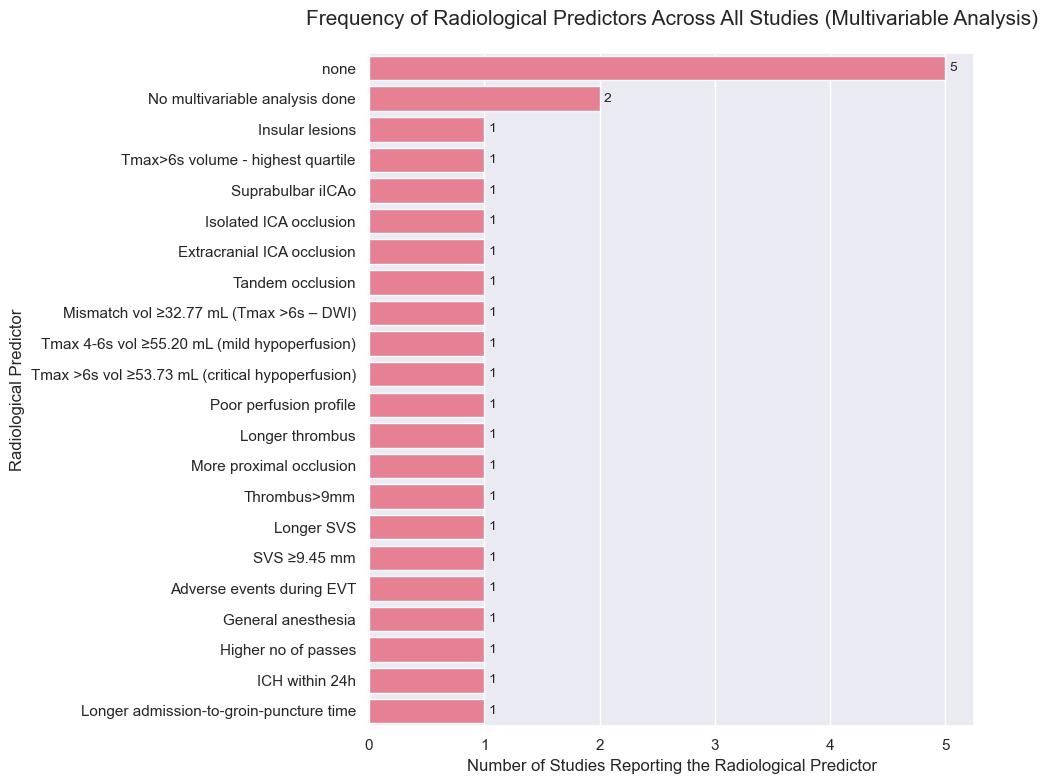

In [61]:
fig, ax = plt.subplots(figsize=(10, 8))

# Create the barplot
sns.barplot(
    x='Study_Count', 
    y='Predictor', 
    data=radiological_predictors_multi_count, 
    ax=ax, 
)

# Add the exact count on the end of each bar
ax.bar_label(ax.containers[0], padding=3, fontsize=10)

# Formatting
ax.set_title('Frequency of Radiological Predictors Across All Studies (Multivariable Analysis)', fontsize=15, pad=20)
ax.set_xlabel('Number of Studies Reporting the Radiological Predictor')
ax.set_ylabel('Radiological Predictor')

# Force X-axis to only show whole numbers (since you can't have 1.5 studies)
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## Overviews

In [62]:
df.columns

Index(['name', 'title', 'year', 'region', 'study_design_1', 'study_design_2',
       'sample_size', 'median_age', 'mean_age', 'median_nihss', 'mean_nihss',
       'ms_max_nihss', 'pct_ms_from_all_ais', 'pct_ms_from_lvo',
       'lvo_definition', 'lvo_segments', 'pct_lvo_from_all_ais',
       'pct_lvo_from_minor_stroke', 'end_delta_nihss', 'end_hours', 'pct_end',
       'clinical_predictors_uni', 'clinical_predictors_multi',
       'radiological_predictors_uni', 'radiological_predictors_multi',
       'mixed_predictors', 'imaging_method', 'ivt', 'pct_ivt', 'primary_evt',
       'rescue_evt', 'pct_rescue_evt_end', 'authors', 'display_name',
       'imaging_method_list', 'lvo_definition_list',
       'clinical_predictors_uni_list', 'clinical_predictors_multi_list',
       'radiological_predictors_uni_list',
       'radiological_predictors_multi_list'],
      dtype='object')

### IVT, primary EVT, rescue EVT and END% alphabetically

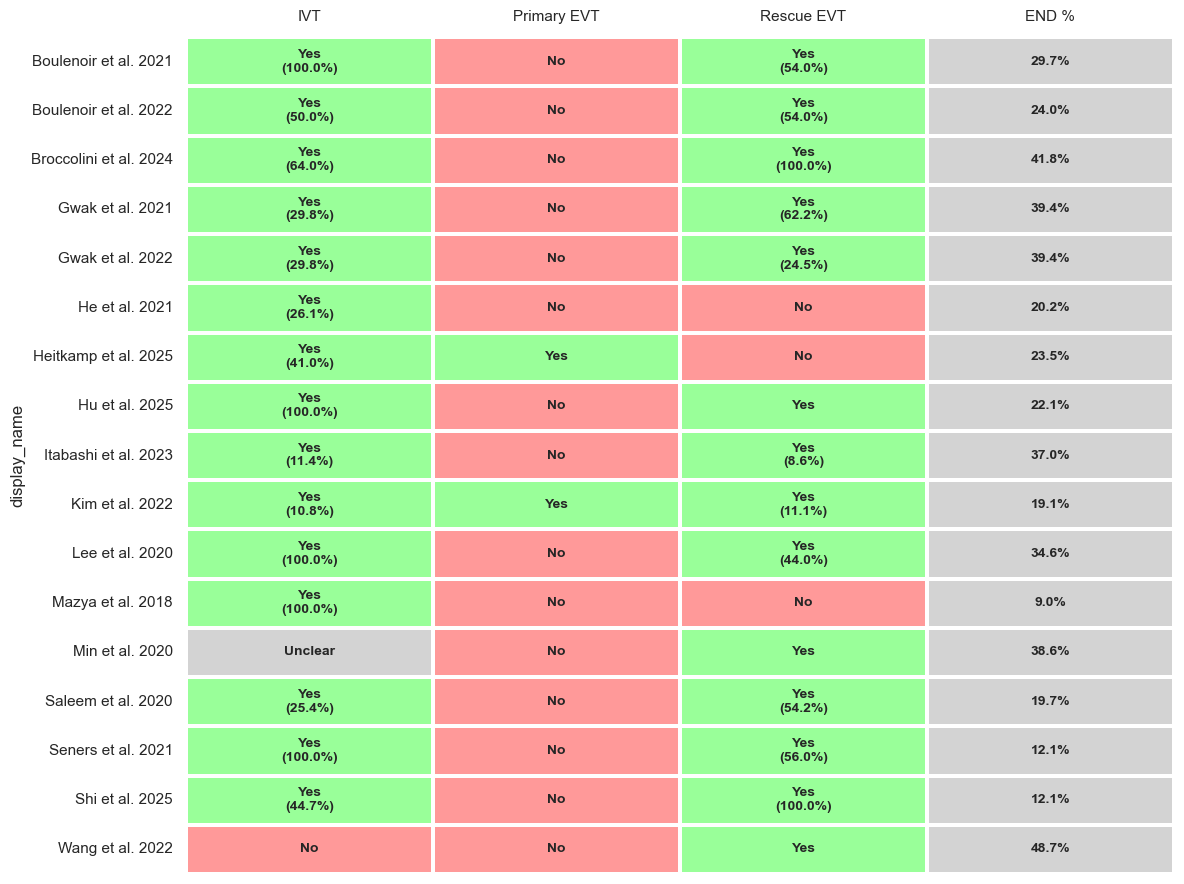

In [63]:
# 1. Sort the original DataFrame alphabetically by study name
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. Setup custom colormap (0=Red, 0.5=Gray, 1=Green)
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)

# 3. Create the Numeric Matrix for Colors (Now automatically sorted)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

color_df = pd.DataFrame(index=df['display_name'])
color_df['IVT'] = df['ivt'].map(color_map).values
color_df['Primary EVT'] = df['primary_evt'].map(color_map).values
color_df['Rescue EVT'] = df['rescue_evt'].map(color_map).values
color_df['END %'] = 0.5 

# 4. Create the Annotation Matrix
annot_df = pd.DataFrame(index=df['display_name'])

def format_treatment(val, pct):
    if pd.isna(pct) or pct == 0:
        return f"{val}"
    return f"{val}\n({pct*100:.1f}%)"

def format_outcome(pct):
    return "N/R" if pd.isna(pct) else f"{pct*100:.1f}%"

annot_df['IVT'] = [format_treatment(v, p) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df['Primary EVT'] = df['primary_evt'].values
annot_df['Rescue EVT'] = [format_treatment(v, p) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df['END %'] = [format_outcome(p) for p in df['pct_end']]

# 5. Plotting
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    color_df, 
    annot=annot_df, 
    fmt="", 
    cmap=my_cmap, 
    cbar=False, 
    linewidths=1.5, 
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

# Move X-axis to top and keep study names horizontal
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', which='both', top=False) # This removes the "I" lines
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

### IVT, primary EVT, rescue EVT and END% ascending by END%

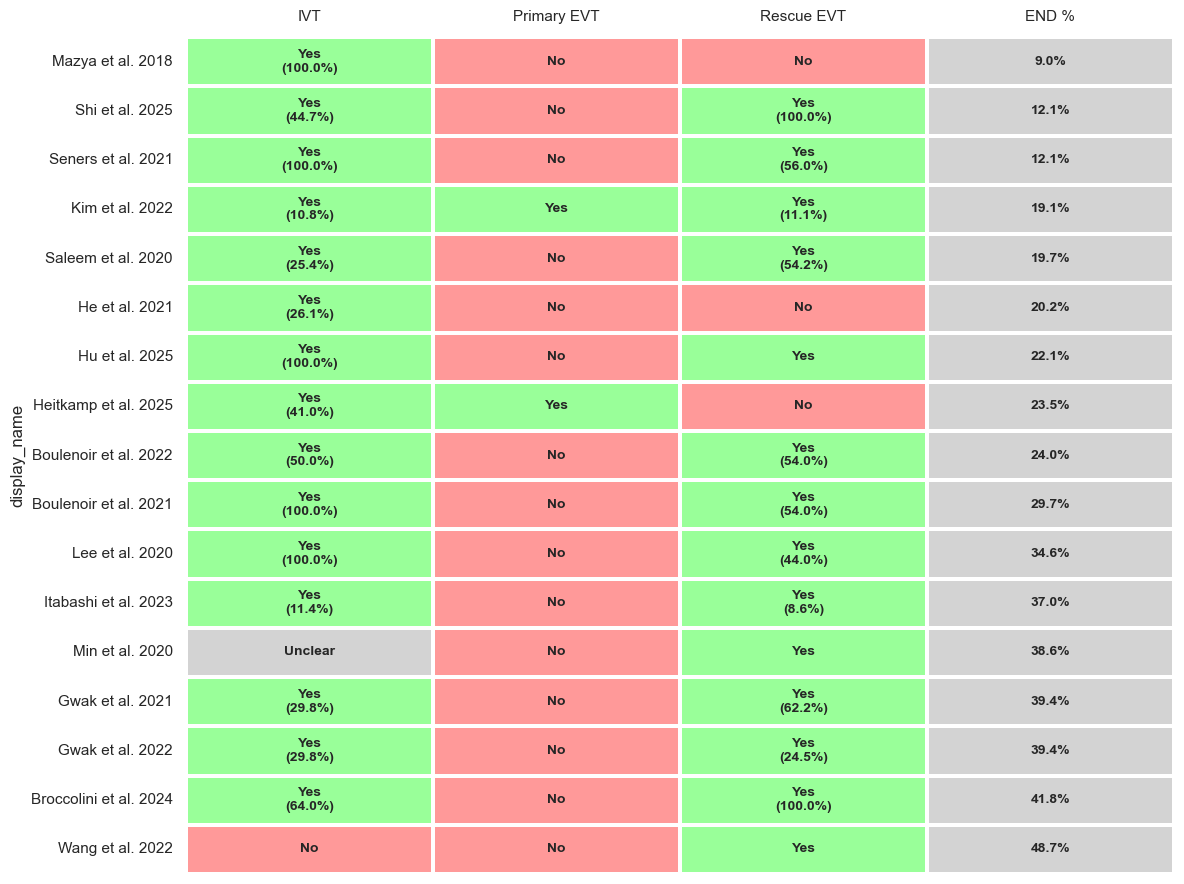

In [64]:
# 1. SORT BY PERCENTAGE OF END (Highest to Lowest)
# na_position='last' ensures studies that didn't report END stay at the bottom
df = df.sort_values('pct_end', ascending=True, na_position='last').reset_index(drop=True)

# 2. Setup custom colormap
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)

# 3. Create matrices (The order is now controlled by the sorted df)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}
color_df = pd.DataFrame(index=df['display_name'])
color_df['IVT'] = df['ivt'].map(color_map).values
color_df['Primary EVT'] = df['primary_evt'].map(color_map).values
color_df['Rescue EVT'] = df['rescue_evt'].map(color_map).values
color_df['END %'] = 0.5 

annot_df = pd.DataFrame(index=df['display_name'])

def format_treatment(val, pct):
    if pd.isna(pct) or pct == 0: return f"{val}"
    return f"{val}\n({pct*100:.1f}%)"

def format_outcome(pct):
    return "N/R" if pd.isna(pct) else f"{pct*100:.1f}%"

annot_df['IVT'] = [format_treatment(v, p) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df['Primary EVT'] = df['primary_evt'].values
annot_df['Rescue EVT'] = [format_treatment(v, p) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df['END %'] = [format_outcome(p) for p in df['pct_end']]

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    color_df, 
    annot=annot_df, 
    fmt="", 
    cmap=my_cmap, 
    cbar=False, 
    linewidths=1.5, 
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

# 5. Fix: Move labels to top and REMOVE the "I" tick lines
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', which='both', top=False) # Removes the "I" marks
ax.tick_params(axis='y', which='both', left=False) # Removes side ticks
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

### IVT, EVT, END% and predictors

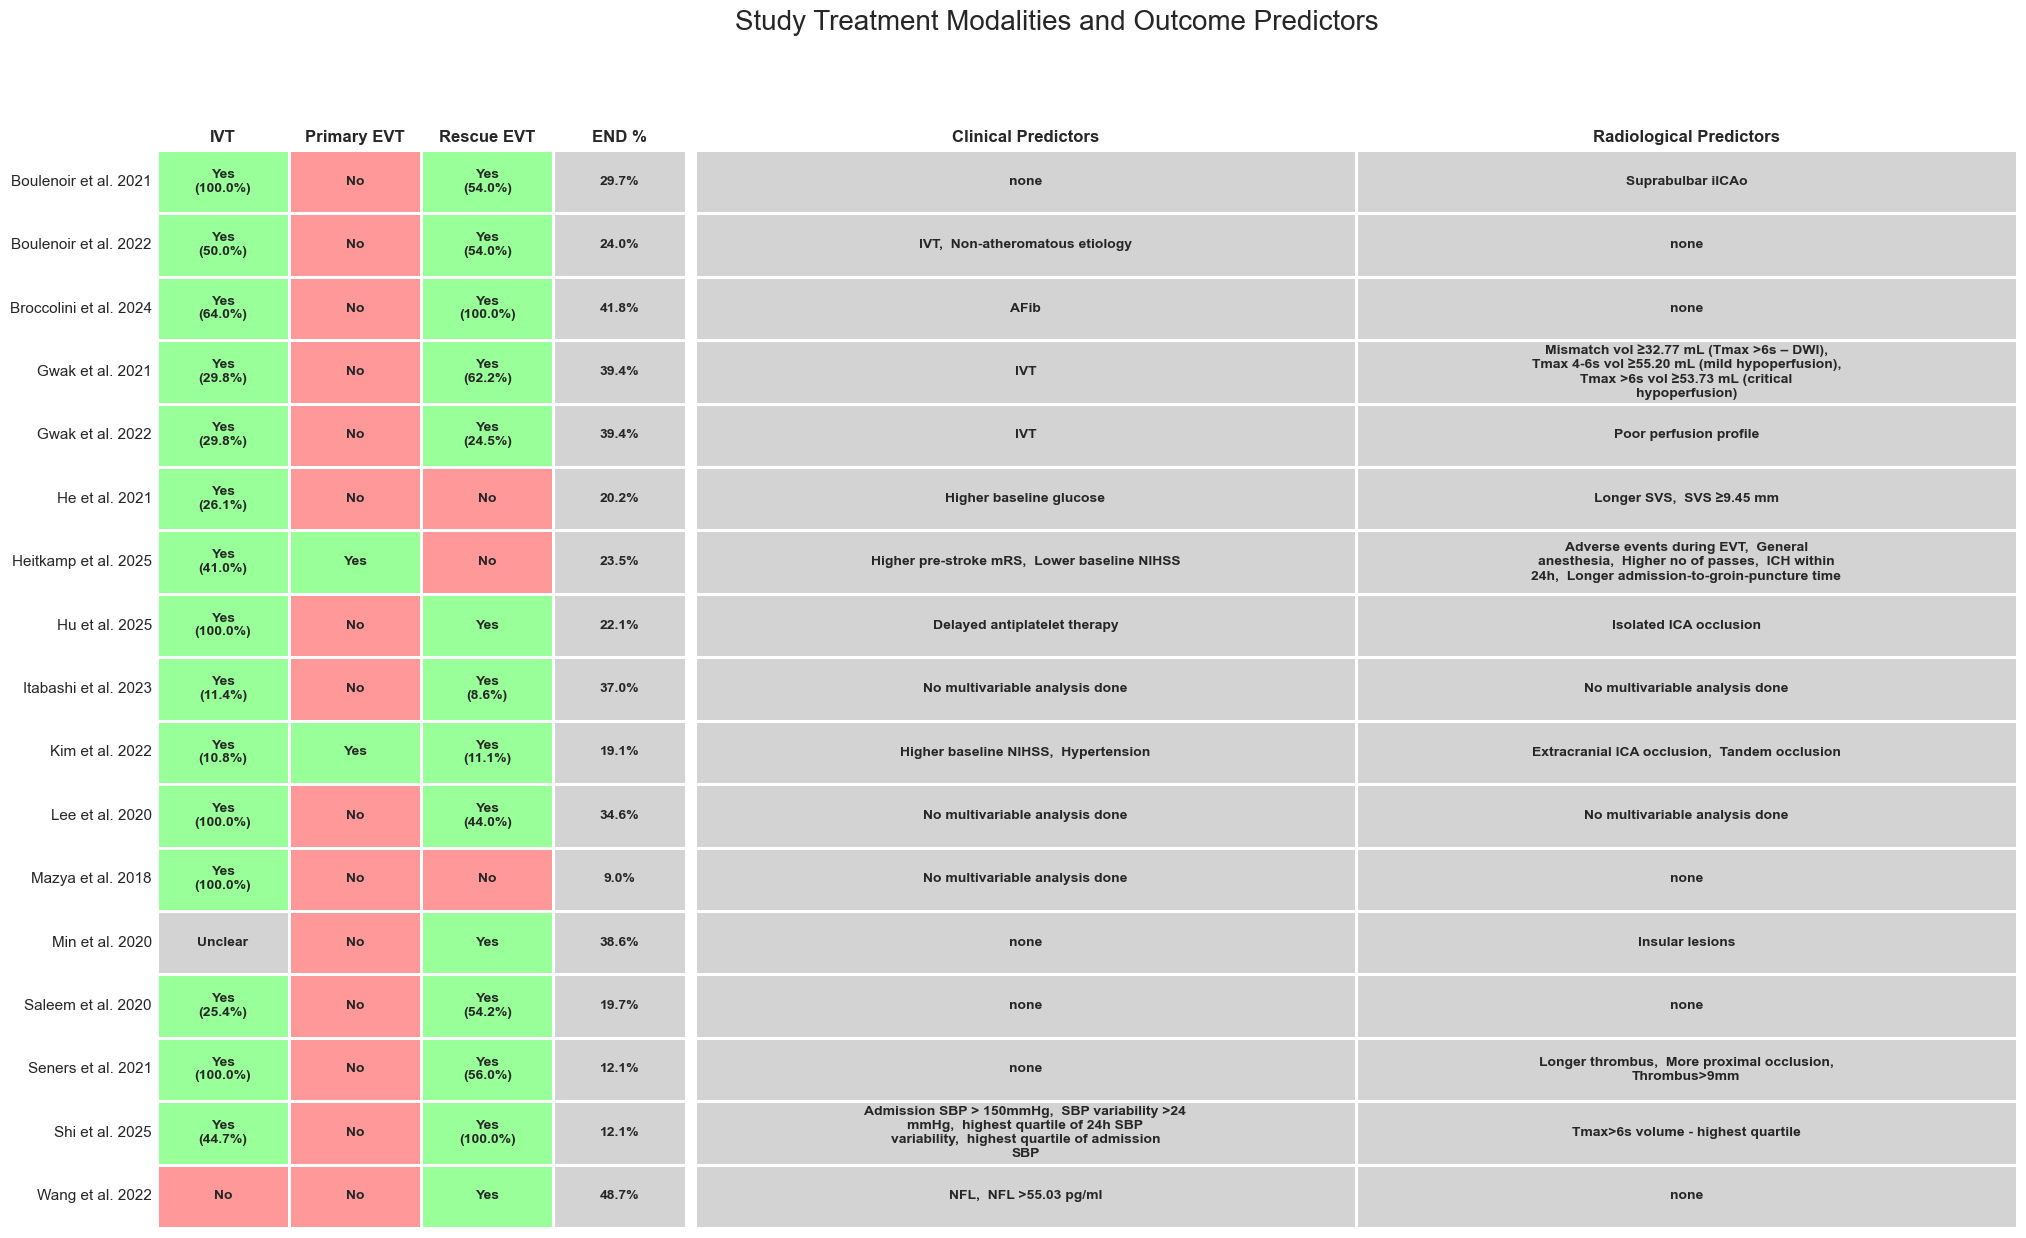

In [65]:
# 1. Sort Alphabetically
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. Setup Colors: [Red (0), Gray (0.5), Green (1)]
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. Helpers
def safe_wrap(text, width=45): 
    if pd.isna(text) or text == "" or str(text).lower() == 'nan':
        return "N/R"
    text = str(text).replace(',', ', ')
    return "\n".join(textwrap.wrap(text, width=width))

def format_treatment(val, pct):
    if pd.isna(pct) or pct == 0: return str(val)
    return f"{val}\n({pct*100:.1f}%)"

# 4. Data Preparation
# Part 1: Status Columns
color_df1 = pd.DataFrame(index=df['display_name'])
color_df1['IVT'] = df['ivt'].map(color_map).values
color_df1['Primary EVT'] = df['primary_evt'].map(color_map).values
color_df1['Rescue EVT'] = df['rescue_evt'].map(color_map).values
color_df1['END %'] = 0.5

annot_df1 = pd.DataFrame(index=df['display_name'])
annot_df1['IVT'] = [format_treatment(v, p) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].values
annot_df1['Rescue EVT'] = [format_treatment(v, p) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END %'] = ["N/R" if pd.isna(p) else f"{p*100:.1f}%" for p in df['pct_end']]

# Part 2: Predictor Columns (Forced to 0.5 for Gray)
color_df2 = pd.DataFrame(index=df['display_name'])
color_df2['Clinical Predictors'] = 0.5
color_df2['Radiological Predictors'] = 0.5

annot_df2 = pd.DataFrame(index=df['display_name'])
annot_df2['Clinical Predictors'] = [safe_wrap(x, 45) for x in df['clinical_predictors_multi']]
annot_df2['Radiological Predictors'] = [safe_wrap(x, 45) for x in df['radiological_predictors_multi']]

# 5. Plotting with Fixed Color Limits
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 14), 
                               gridspec_kw={'width_ratios': [1, 2.5], 'wspace': 0.01})

# Heatmap 1: vmin and vmax ensure colors map correctly
sns.heatmap(color_df1, annot=annot_df1, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1,  # CRITICAL: Fixes the color mapping
            linewidths=2, linecolor='white', annot_kws={"size": 10, "weight": "bold"}, ax=ax1)

# Heatmap 2: Predictors
sns.heatmap(color_df2, annot=annot_df2, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1,  # CRITICAL: Ensures 0.5 stays Gray
            linewidths=2, linecolor='white', annot_kws={"size": 10, "weight": "bold"}, ax=ax2)

# 6. Formatting Polish
for ax in [ax1, ax2]:
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0) # Removes all tick marks ("I" lines)
    ax.set_ylabel("")

ax2.set_yticklabels([]) # Hide duplicate names on the second plot

plt.setp(ax1.get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(ax2.get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(ax1.get_yticklabels(), rotation=0, fontsize=11)

fig.suptitle('Study Treatment Modalities and Outcome Predictors', fontsize=20, y=0.98)
plt.show()

### IVT, EVT, END%, LVO with segments, and predictors

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\3321924961.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


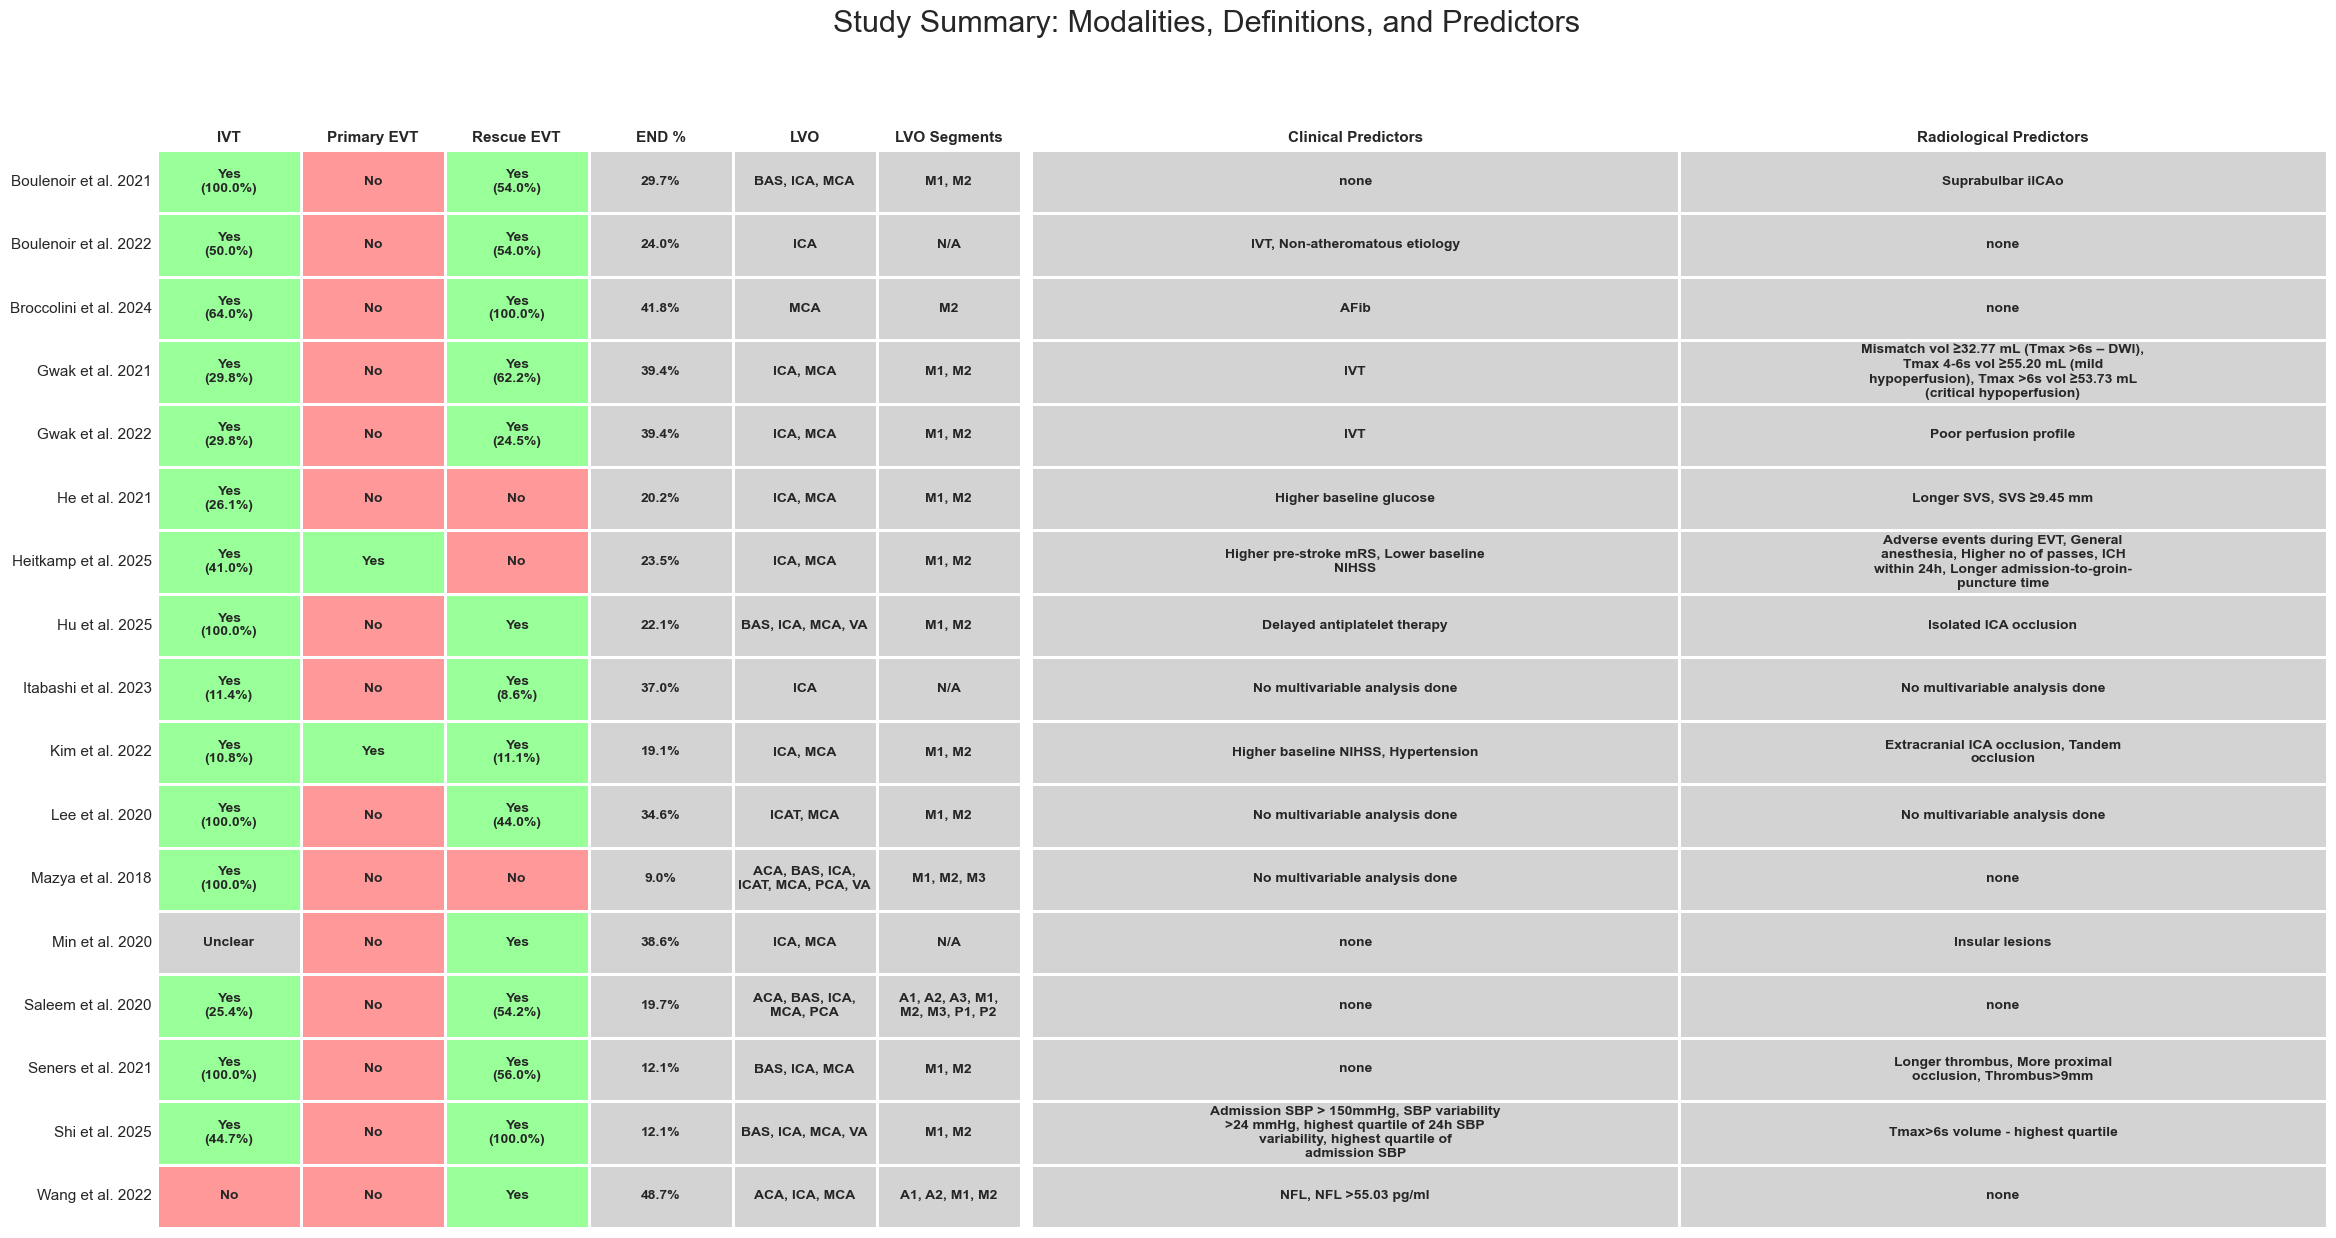

In [66]:
# 1. Sort Alphabetically
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. Setup Colors: 0=Red, 0.5=Gray, 1=Green
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. The Bulletproof safe_wrap (Handles lists/sets/strings)
def safe_wrap(text, width=30): 
    if isinstance(text, (list, set)):
        if len(text) == 0: return "N/A"
        text = ", ".join(map(str, text))
    if pd.isna(text) or str(text).strip() == "" or str(text).lower() == 'nan':
        return "N/A"
    clean_text = str(text).replace(',', ', ').replace('  ', ' ')
    return "\n".join(textwrap.wrap(clean_text, width=width))

def format_treatment(val, pct):
    if pd.isna(pct) or pct == 0: return str(val)
    return f"{val}\n({pct*100:.1f}%)"

# 4. DATA PREPARATION
# --- PART 1: Thin Columns (LVO Definition renamed to LVO) ---
cols1 = ['IVT', 'Primary EVT', 'Rescue EVT', 'END %', 'LVO', 'LVO Segments']
color_df1 = pd.DataFrame(index=df['display_name'])

color_df1['IVT'] = df['ivt'].map(color_map).fillna(0.5).values
color_df1['Primary EVT'] = df['primary_evt'].map(color_map).fillna(0.5).values
color_df1['Rescue EVT'] = df['rescue_evt'].map(color_map).fillna(0.5).values
color_df1['END %'] = 0.5
color_df1['LVO'] = 0.5          # Background color for LVO
color_df1['LVO Segments'] = 0.5

annot_df1 = pd.DataFrame(index=df['display_name'])
annot_df1['IVT'] = [format_treatment(v, p) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].values
annot_df1['Rescue EVT'] = [format_treatment(v, p) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END %'] = ["N/R" if pd.isna(p) else f"{p*100:.1f}%" for p in df['pct_end']]

# Pulling from lvo_definition_list but labeling it "LVO"
annot_df1['LVO'] = [safe_wrap(x, 18) for x in df['lvo_definition_list']]
annot_df1['LVO Segments'] = [safe_wrap(x, 18) for x in df['lvo_segments']]

# Ensure column order matches the list
color_df1 = color_df1[cols1]
annot_df1 = annot_df1[cols1]

# --- PART 2: Wide Columns ---
cols2 = ['Clinical Predictors', 'Radiological Predictors']
color_df2 = pd.DataFrame(0.5, index=df['display_name'], columns=cols2)

annot_df2 = pd.DataFrame(index=df['display_name'])
annot_df2['Clinical Predictors'] = [safe_wrap(x, 40) for x in df['clinical_predictors_multi']]
annot_df2['Radiological Predictors'] = [safe_wrap(x, 40) for x in df['radiological_predictors_multi']]

# 5. PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 14), 
                               gridspec_kw={'width_ratios': [2, 3], 'wspace': 0.01})

# Left Side
sns.heatmap(color_df1, annot=annot_df1, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=2, linecolor='white', 
            annot_kws={"size": 10, "weight": "bold"}, ax=ax1)

# Right Side
sns.heatmap(color_df2, annot=annot_df2, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=2, linecolor='white', 
            annot_kws={"size": 10, "weight": "bold"}, ax=ax2)

# 6. FORMATTING
for ax in [ax1, ax2]:
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_ylabel("")

ax2.set_yticklabels([]) 
plt.setp(ax1.get_xticklabels(), fontsize=11, fontweight='bold')
plt.setp(ax2.get_xticklabels(), fontsize=11, fontweight='bold')
plt.setp(ax1.get_yticklabels(), rotation=0, fontsize=11)

fig.suptitle('Study Summary: Modalities, Definitions, and Predictors', fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Studies characteristics 1

In [67]:
# 1. Strip hidden spaces from column names and make them lowercase
df.columns = df.columns.str.strip().str.lower()

# 2. Convert 'nan' strings or empty spaces into actual Null values
df['median_age'] = pd.to_numeric(df['median_age'], errors='coerce')
df['mean_age'] = pd.to_numeric(df['mean_age'], errors='coerce')

# 3. DEBUG PRINT: Run this and check your terminal/console!
# It should show numbers or NaN, not the string "nan"
print("--- AGE DATA DEBUG ---")
print(df[['display_name', 'median_age', 'mean_age']].head())

--- AGE DATA DEBUG ---
             display_name  median_age  mean_age
0   Boulenoir et al. 2021         NaN      64.0
1   Boulenoir et al. 2022         NaN      65.0
2  Broccolini et al. 2024        70.0       NaN
3        Gwak et al. 2021         NaN      66.9
4        Gwak et al. 2022         NaN      66.9


C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\126552839.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


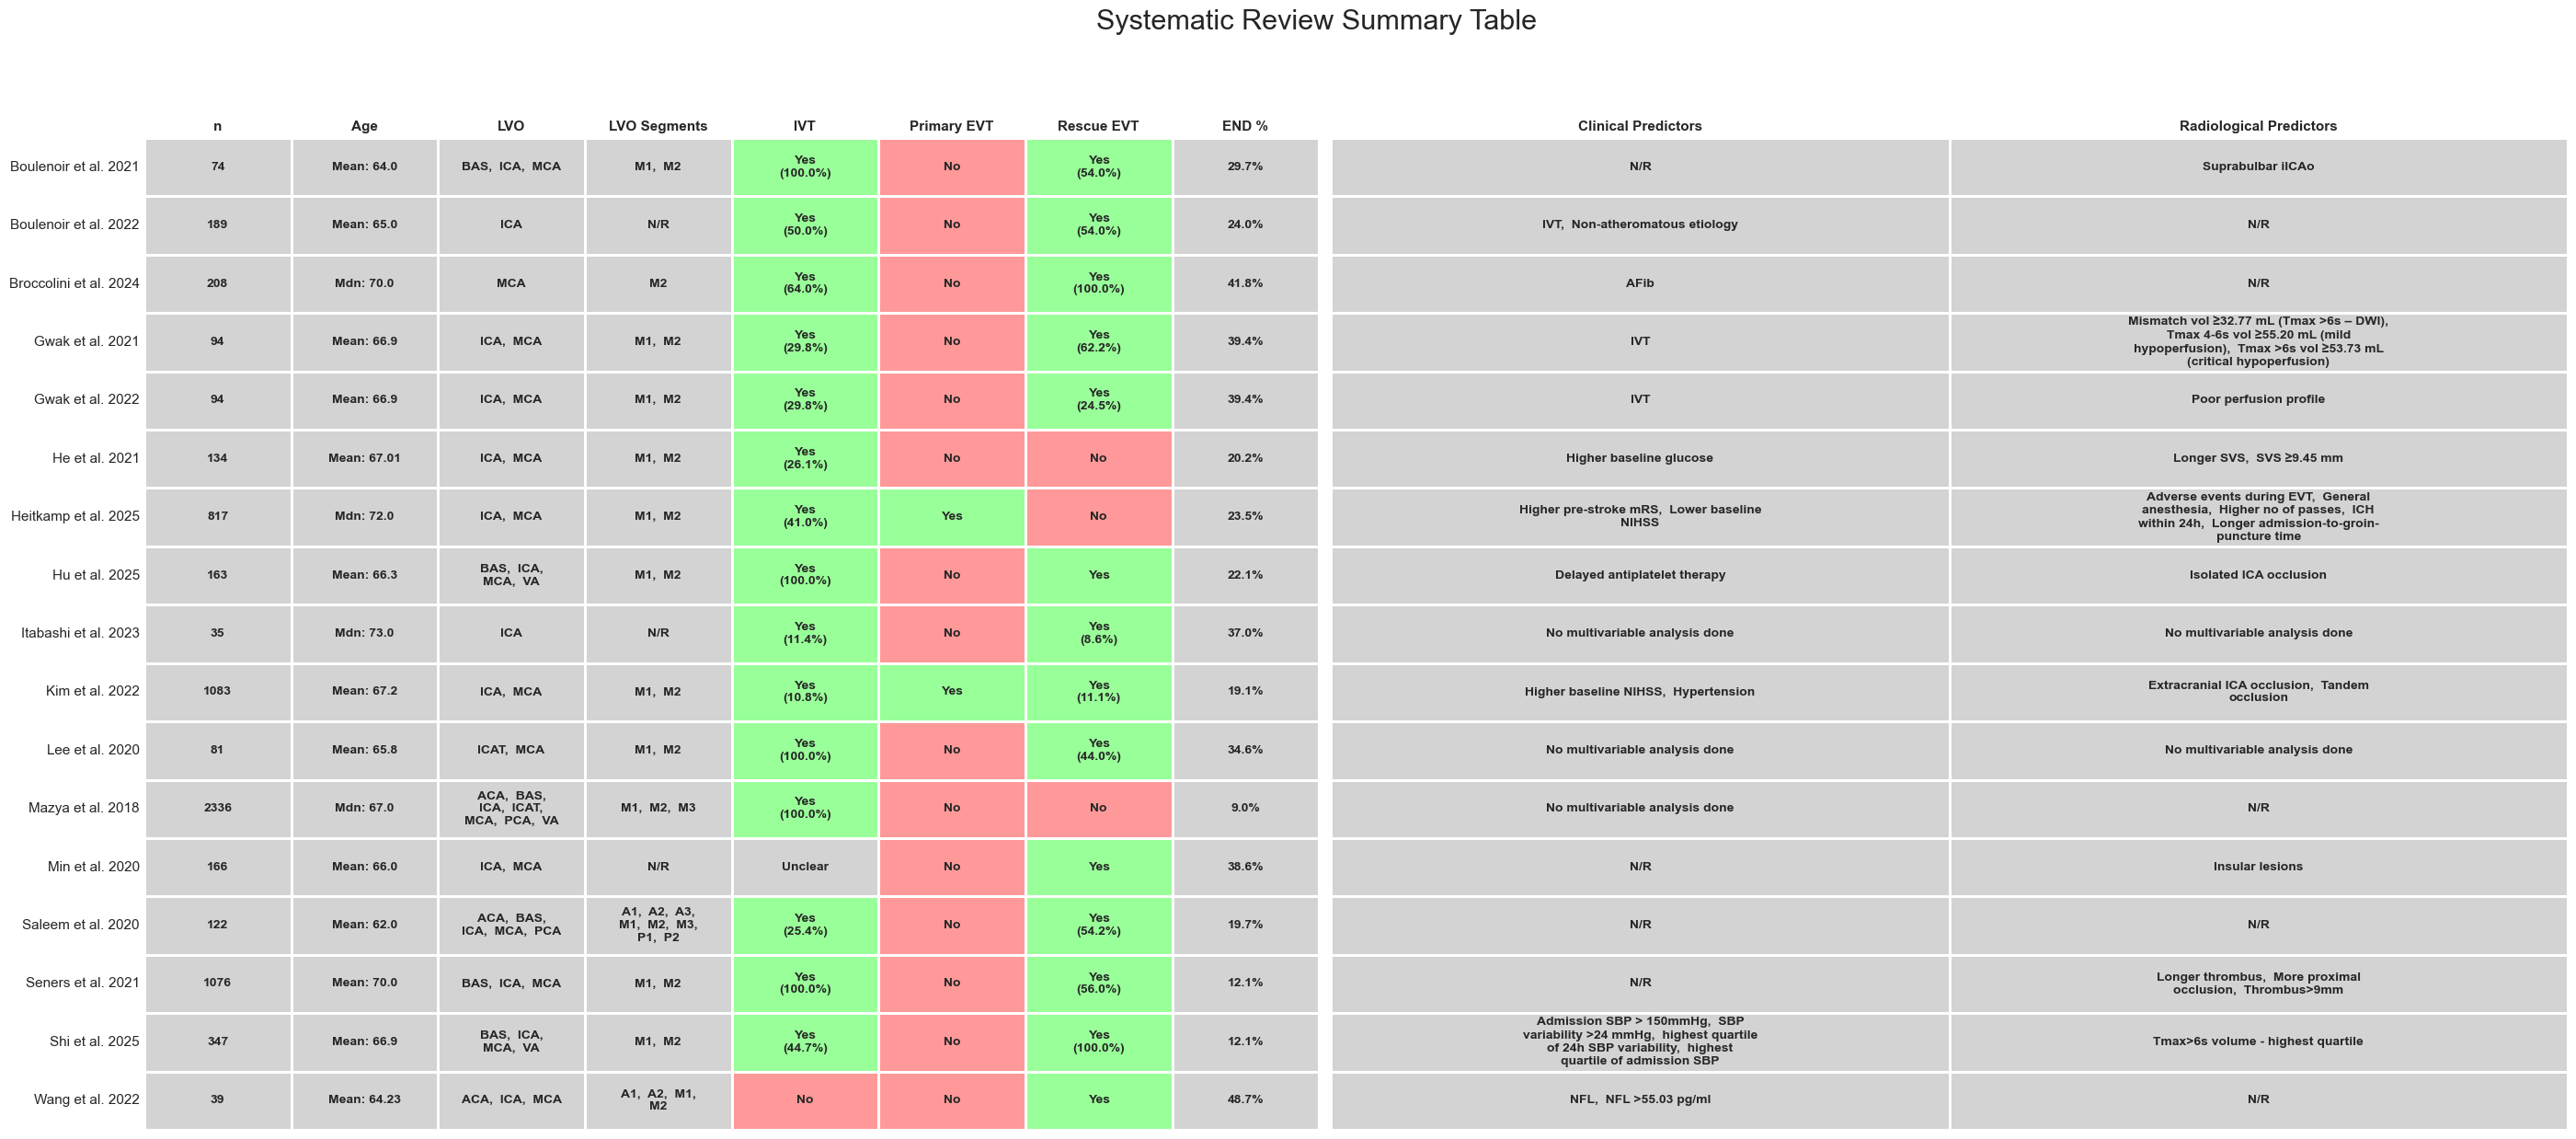

In [68]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORS: 0=Red, 0.5=Gray, 1=Green
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. HELPERS
def safe_wrap(text, width=25): 
    if isinstance(text, (list, set)):
        if len(text) == 0: return "N/R"
        text = ", ".join(map(str, text))
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "N/R"
    return "\n".join(textwrap.wrap(str(text).replace(',', ', '), width=width))

def format_treatment(val, pct):
    if pd.isna(pct) or pct == 0: return str(val)
    return f"{val}\n({pct*100:.1f}%)"

def get_age_display(row):
    med, avg = row.get('median_age'), row.get('mean_age')
    if pd.notna(med) and str(med).lower() != 'nan': return f"Mdn: {med}"
    if pd.notna(avg) and str(avg).lower() != 'nan': return f"Mean: {avg}"
    return "N/R"

# 4. DATA PREPARATION
# --- PART 1: Thin Columns (Order: n, Age, LVO, LVO Segments, IVT, Primary EVT, Rescue EVT, END %) ---
cols1 = ['n', 'Age', 'LVO', 'LVO Segments', 'IVT', 'Primary EVT', 'Rescue EVT', 'END %']
color_df1 = pd.DataFrame(index=df.index)

# Assign Background Colors
color_df1['n'] = 0.5
color_df1['Age'] = 0.5
color_df1['LVO'] = 0.5
color_df1['LVO Segments'] = 0.5
color_df1['IVT'] = df['ivt'].map(color_map).fillna(0.5).values
color_df1['Primary EVT'] = df['primary_evt'].map(color_map).fillna(0.5).values
color_df1['Rescue EVT'] = df['rescue_evt'].map(color_map).fillna(0.5).values
color_df1['END %'] = 0.5

# Assign Text Annotations
annot_df1 = pd.DataFrame(index=df.index)
annot_df1['n'] = [f"{int(x)}" if pd.notna(x) and str(x).lower() != 'nan' else "N/R" for x in df['sample_size']]
annot_df1['Age'] = df.apply(get_age_display, axis=1)
annot_df1['LVO'] = [safe_wrap(x, 15) for x in df['lvo_definition_list']]
annot_df1['LVO Segments'] = [safe_wrap(x, 15) for x in df['lvo_segments']]
annot_df1['IVT'] = [format_treatment(v, p) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [format_treatment(v, p) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END %'] = [f"{p*100:.1f}%" if pd.notna(p) and str(p).lower() != 'nan' else "N/R" for p in df['pct_end']]

# --- PART 2: Wide Columns ---
cols2 = ['Clinical Predictors', 'Radiological Predictors']
color_df2 = pd.DataFrame(0.5, index=df.index, columns=cols2)
annot_df2 = pd.DataFrame(index=df.index)
annot_df2['Clinical Predictors'] = [safe_wrap(x, 40) for x in df['clinical_predictors_multi']]
annot_df2['Radiological Predictors'] = [safe_wrap(x, 40) for x in df['radiological_predictors_multi']]

# 5. PLOTTING
# width_ratios [3.8, 4] balances the 8 thin vs 2 wide columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(34, 14), 
                               gridspec_kw={'width_ratios': [3.8, 4], 'wspace': 0.01})

sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=2, linecolor='white', 
            annot_kws={"size": 10, "weight": "bold"}, ax=ax1)

sns.heatmap(color_df2, annot=annot_df2, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=2, linecolor='white', 
            annot_kws={"size": 10, "weight": "bold"}, ax=ax2)

# 6. FORMATTING
ax1.set_yticklabels(df['display_name'], rotation=0, fontsize=11)

for ax in [ax1, ax2]:
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_ylabel("")

ax2.set_yticklabels([]) 
plt.setp(ax1.get_xticklabels(), fontsize=11, fontweight='bold')
plt.setp(ax2.get_xticklabels(), fontsize=11, fontweight='bold')

fig.suptitle('Systematic Review Summary Table', fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Studies characteristics 2

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\4104128785.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


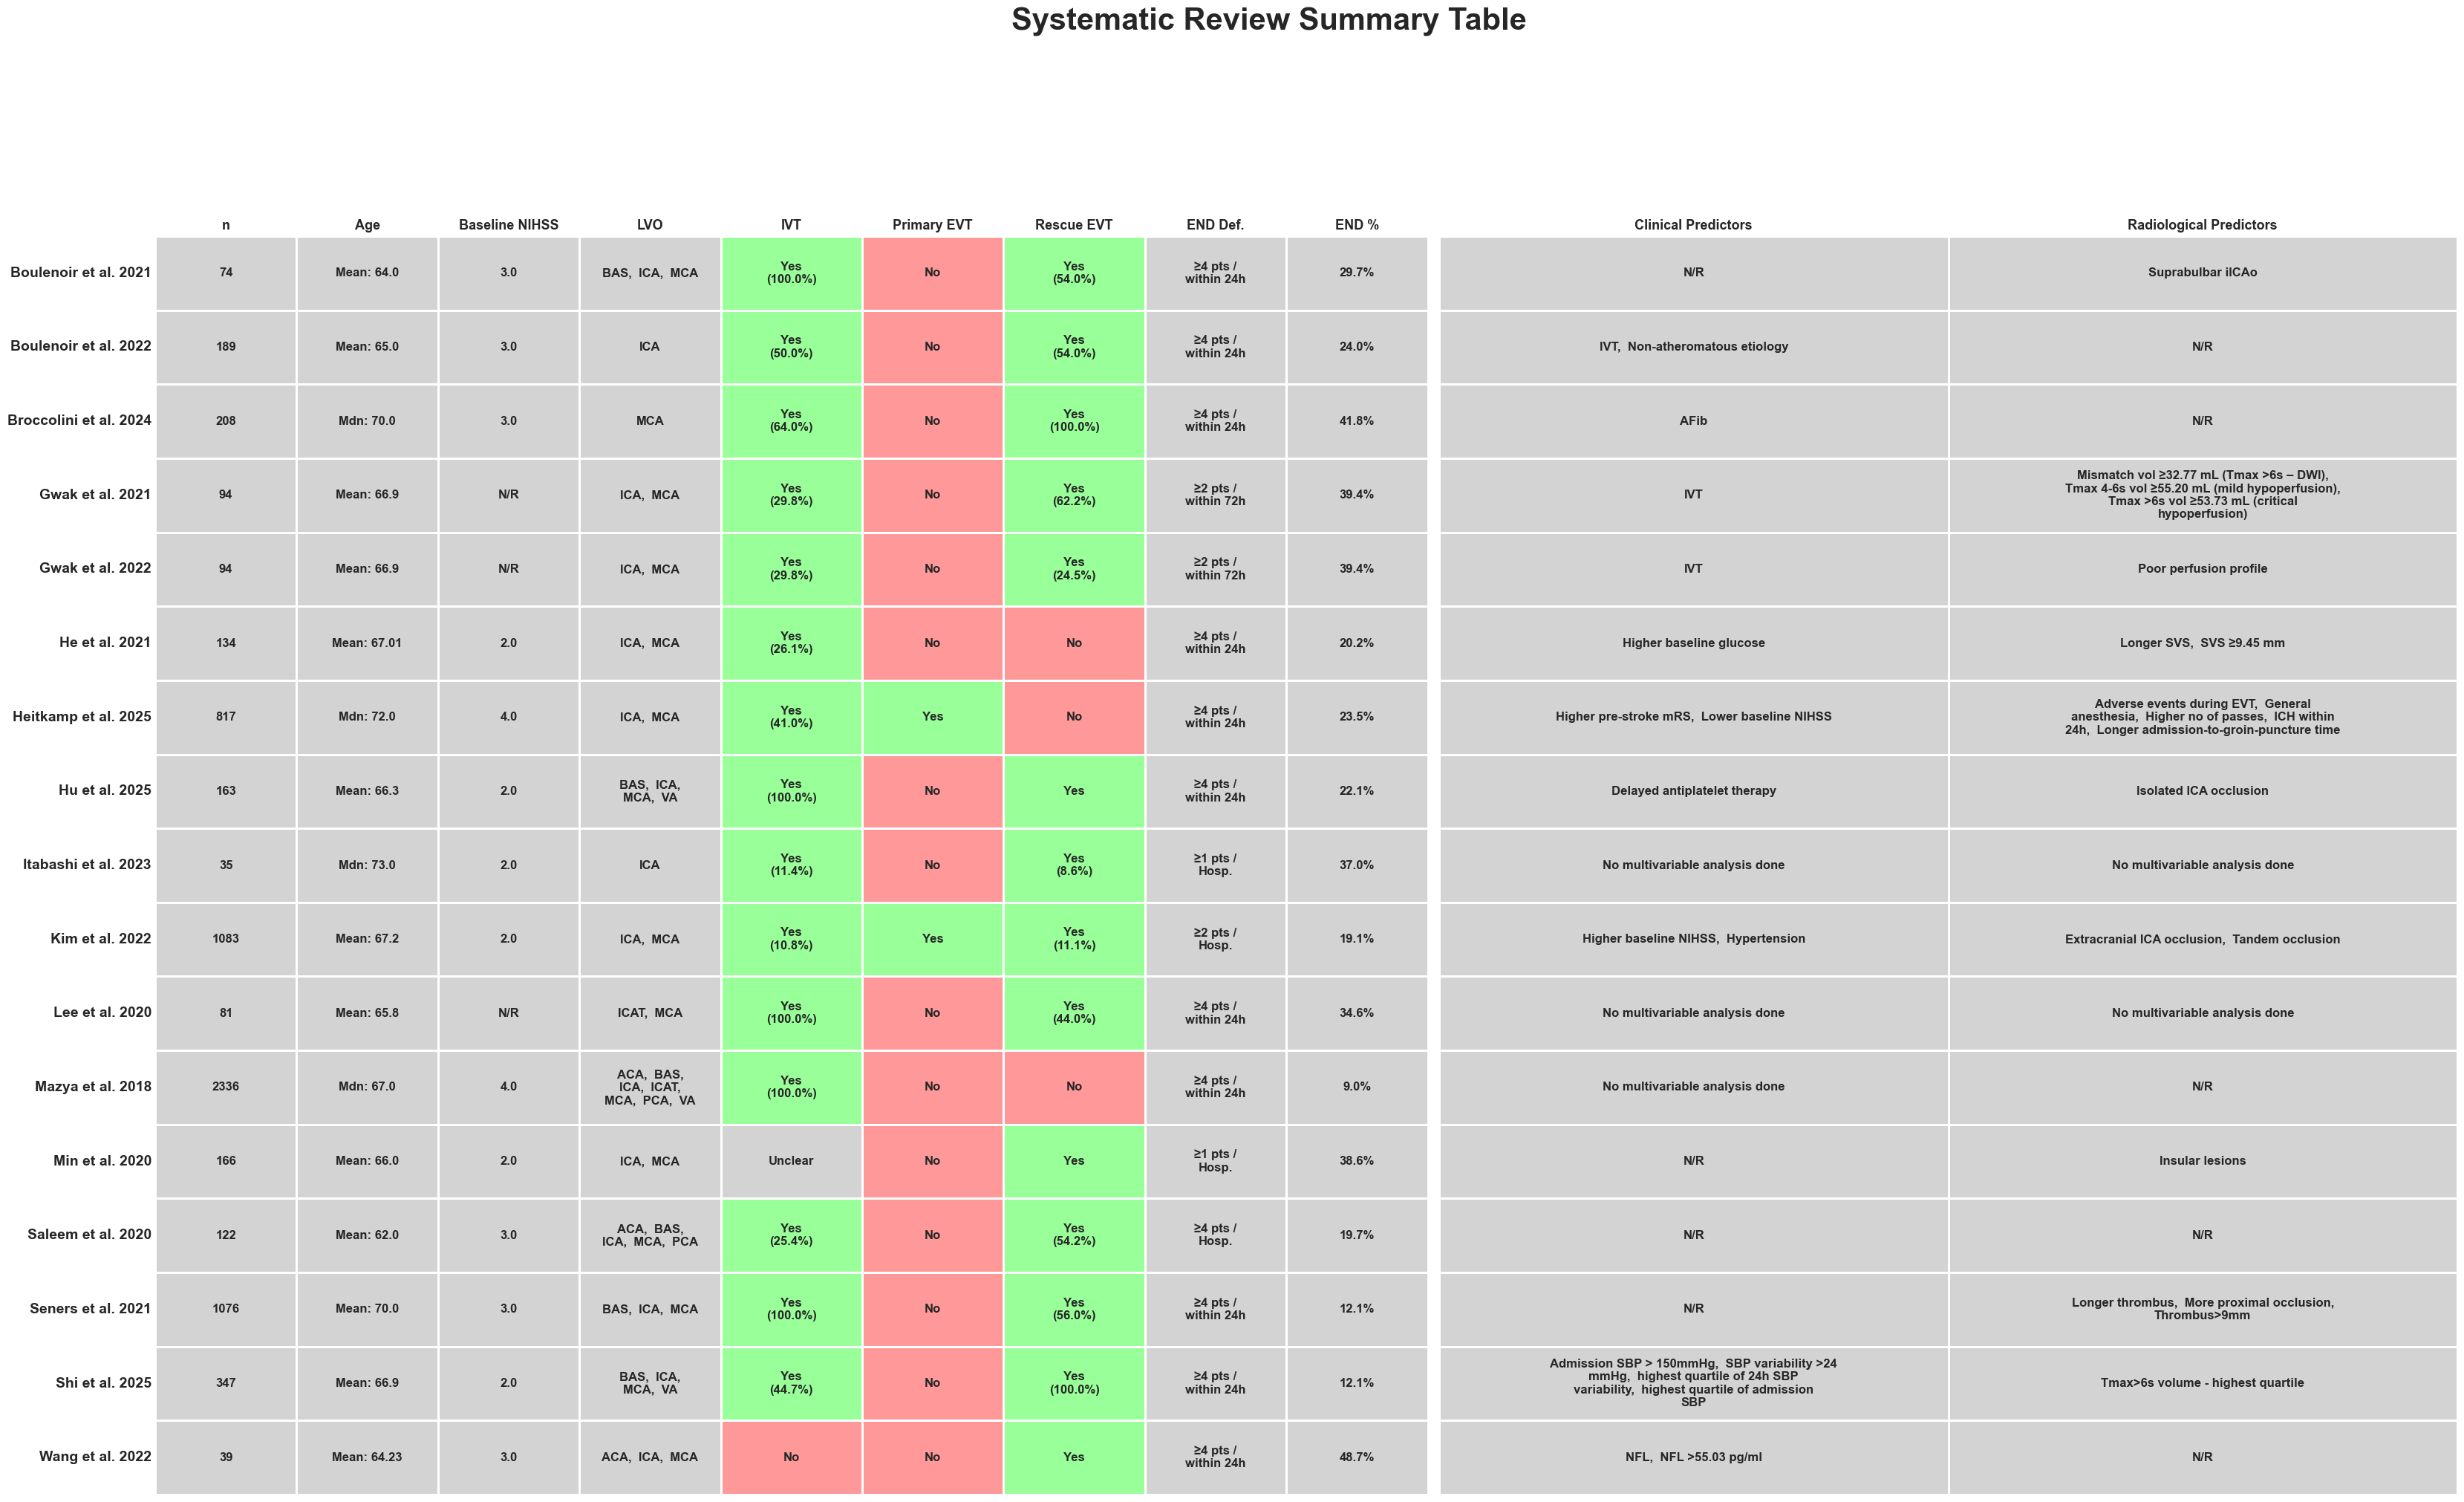

In [69]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORS
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. HELPERS
def safe_wrap(text, width=35): 
    if isinstance(text, (list, set)):
        if len(text) == 0: return "N/R"
        text = ", ".join(map(str, text))
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "N/R"
    return "\n".join(textwrap.wrap(str(text).replace(',', ', '), width=width))

def format_treatment(val, pct):
    if pd.isna(pct) or pct == 0: return str(val)
    return f"{val}\n({pct*100:.1f}%)"

def get_age_display(row):
    med, avg = row.get('median_age'), row.get('mean_age')
    if pd.notna(med) and str(med).lower() != 'nan': return f"Mdn: {med}"
    if pd.notna(avg) and str(avg).lower() != 'nan': return f"Mean: {avg}"
    return "N/R"

def get_end_definition(row):
    delta = row.get('end_delta_nihss')
    hours = row.get('end_hours')
    d_str = f"≥{int(delta)} pts" if pd.notna(delta) else "Any Δ"
    # Abbreviating Hospitalization to Hosp. to save space
    t_str = "Hosp." if pd.isna(hours) else f"within {int(hours)}h"
    return f"{d_str} /\n{t_str}"

# 4. DATA PREPARATION
cols1 = ['n', 'Age', 'Baseline NIHSS', 'LVO', 'IVT', 'Primary EVT', 'Rescue EVT', 'END Def.', 'END %']
color_df1 = pd.DataFrame(index=df.index)

for col in cols1:
    key = col.lower().replace(' ', '_').replace('baseline_', '').replace('end_def.', 'end_definition')
    if col in ['IVT', 'Primary EVT', 'Rescue EVT']:
        color_df1[col] = df[key].map(color_map).fillna(0.5).values
    else:
        color_df1[col] = 0.5

annot_df1 = pd.DataFrame(index=df.index)
annot_df1['n'] = [f"{int(x)}" if pd.notna(x) and str(x).lower() != 'nan' else "N/R" for x in df['sample_size']]
annot_df1['Age'] = df.apply(get_age_display, axis=1)
annot_df1['Baseline NIHSS'] = [f"{x}" if pd.notna(x) else "N/R" for x in df['median_nihss']]
annot_df1['LVO'] = [safe_wrap(x, 15) for x in df['lvo_definition_list']]
annot_df1['IVT'] = [format_treatment(v, p) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [format_treatment(v, p) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END Def.'] = df.apply(get_end_definition, axis=1)
annot_df1['END %'] = [f"{p*100:.1f}%" if pd.notna(p) and str(p).lower() != 'nan' else "N/R" for p in df['pct_end']]

# Predictors
cols2 = ['Clinical Predictors', 'Radiological Predictors']
color_df2 = pd.DataFrame(0.5, index=df.index, columns=cols2)
annot_df2 = pd.DataFrame(index=df.index)
annot_df2['Clinical Predictors'] = [safe_wrap(x, 45) for x in df['clinical_predictors_multi']]
annot_df2['Radiological Predictors'] = [safe_wrap(x, 45) for x in df['radiological_predictors_multi']]

# 5. PLOTTING - MASSIVE INCREASE IN SIZE
# Height increased to 22, Width to 40
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 22), 
                               gridspec_kw={'width_ratios': [5, 4], 'wspace': 0.01})

# Increased font size to 12 for readability
sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=2, linecolor='white', 
            annot_kws={"size": 12, "weight": "bold"}, ax=ax1)

sns.heatmap(color_df2, annot=annot_df2, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=2, linecolor='white', 
            annot_kws={"size": 12, "weight": "bold"}, ax=ax2)

# 6. FORMATTING
ax1.set_yticklabels(df['display_name'], rotation=0, fontsize=14, fontweight='bold')

for ax in [ax1, ax2]:
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_ylabel("")

ax2.set_yticklabels([]) 
plt.setp(ax1.get_xticklabels(), fontsize=13, fontweight='bold')
plt.setp(ax2.get_xticklabels(), fontsize=13, fontweight='bold')

fig.suptitle('Systematic Review Summary Table', fontsize=30, y=1.02, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])

# 7. SAVE AS PDF (This is the secret for readability!)
plt.savefig("Stroke_Study_Matrix.pdf", bbox_inches='tight', dpi=300)
plt.show()

### Studies characteristics separated from predictors

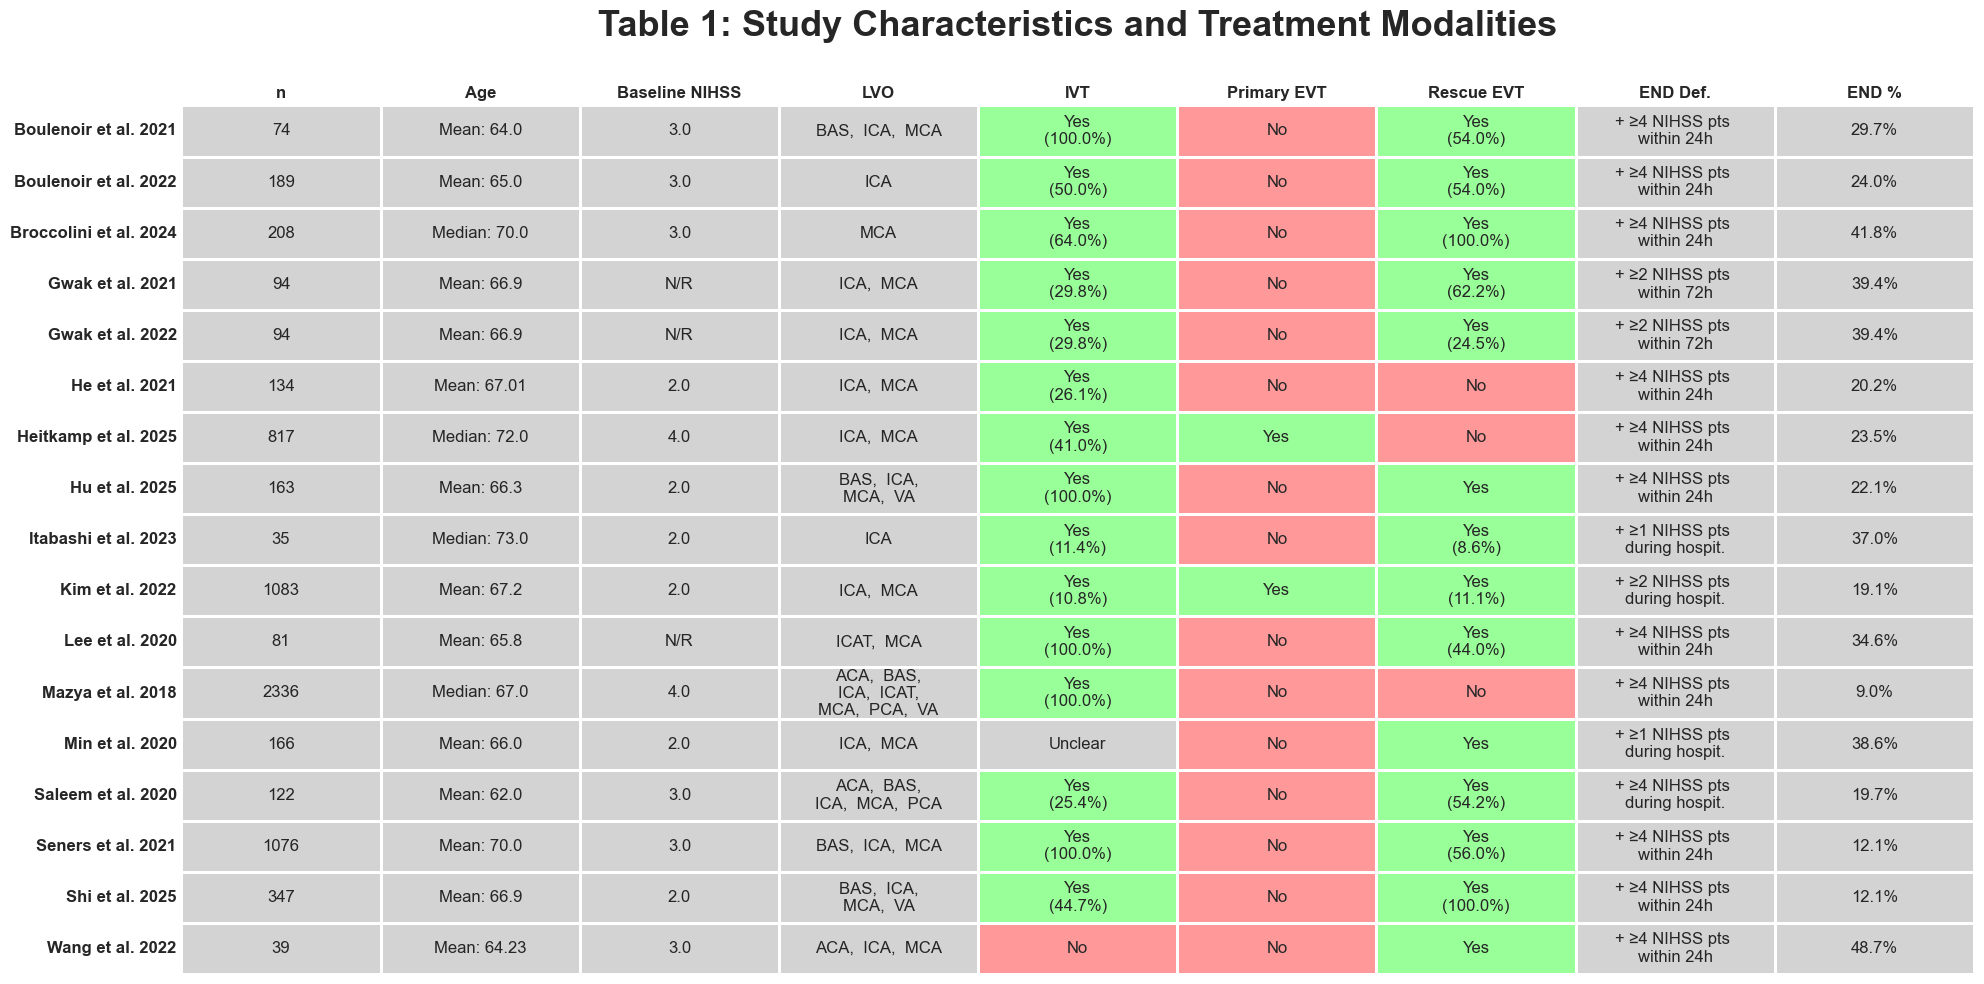

In [70]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORS
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. UPDATED HELPERS (Fixes the ValueError)
def safe_wrap(text, width=20): 
    # Check for lists/arrays BEFORE checking for NaN
    if isinstance(text, (list, set, np.ndarray)):
        if len(text) == 0: return "N/R"
        text = ", ".join(map(str, text))
    
    # Now it's safe to check for NaN/Empty strings
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]: 
        return "N/R"
        
    return "\n".join(textwrap.wrap(str(text).replace(',', ', '), width=width))

def get_age_display(row):
    med, avg = row.get('median_age'), row.get('mean_age')
    if pd.notna(med) and str(med).lower() != 'nan': return f"Median: {med}"
    if pd.notna(avg) and str(avg).lower() != 'nan': return f"Mean: {avg}"
    return "N/R"

def get_end_definition(row):
    delta, hours = row.get('end_delta_nihss'), row.get('end_hours')
    d_str = f"+ ≥{int(delta)} NIHSS pts" if pd.notna(delta) else "Any Δ"
    t_str = "during hospit." if pd.isna(hours) else f"within {int(hours)}h"
    return f"{d_str} \n{t_str}"

# --- PLOT 1: CLINICAL & TREATMENT DATA ---
cols1 = ['n', 'Age', 'Baseline NIHSS', 'LVO', 'IVT', 'Primary EVT', 'Rescue EVT', 'END Def.', 'END %']
color_df1 = pd.DataFrame(index=df.index)
annot_df1 = pd.DataFrame(index=df.index)

for col in cols1:
    if col in ['IVT', 'Primary EVT', 'Rescue EVT']:
        key = col.lower().replace(' ', '_')
        color_df1[col] = df[key].map(color_map).fillna(0.5).values
    else:
        color_df1[col] = 0.5

annot_df1['n'] = [f"{int(x)}" if pd.notna(x) else "N/R" for x in df['sample_size']]
annot_df1['Age'] = df.apply(get_age_display, axis=1)
annot_df1['Baseline NIHSS'] = [f"{x}" if pd.notna(x) else "N/R" for x in df['median_nihss']]
annot_df1['LVO'] = [safe_wrap(x, 15) for x in df['lvo_definition_list']]
annot_df1['IVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END Def.'] = df.apply(get_end_definition, axis=1)
annot_df1['END %'] = [f"{p*100:.1f}%" if pd.notna(p) else "N/R" for p in df['pct_end']]

fig1, ax1 = plt.subplots(figsize=(20, 10))
sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=2, linecolor='white', 
            annot_kws={"size": 12}, ax=ax1)

ax1.set_yticklabels(df['display_name'], rotation=0, fontsize=12, fontweight='bold')
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
plt.setp(ax1.get_xticklabels(), fontsize=12, fontweight='bold')
ax1.set_title("Table 1: Study Characteristics and Treatment Modalities", fontsize=26, pad=50, fontweight='bold')
# Remove the tick marks (the "little lines") from both tables
for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='both', length=0)  # Sets the line length to zero
    ax.xaxis.tick_top()                                 # Keeps labels at top
    ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.savefig("Table1_Clinical.pdf")
plt.show()

### Both tables together (studies characteristics and predictors multivariate)

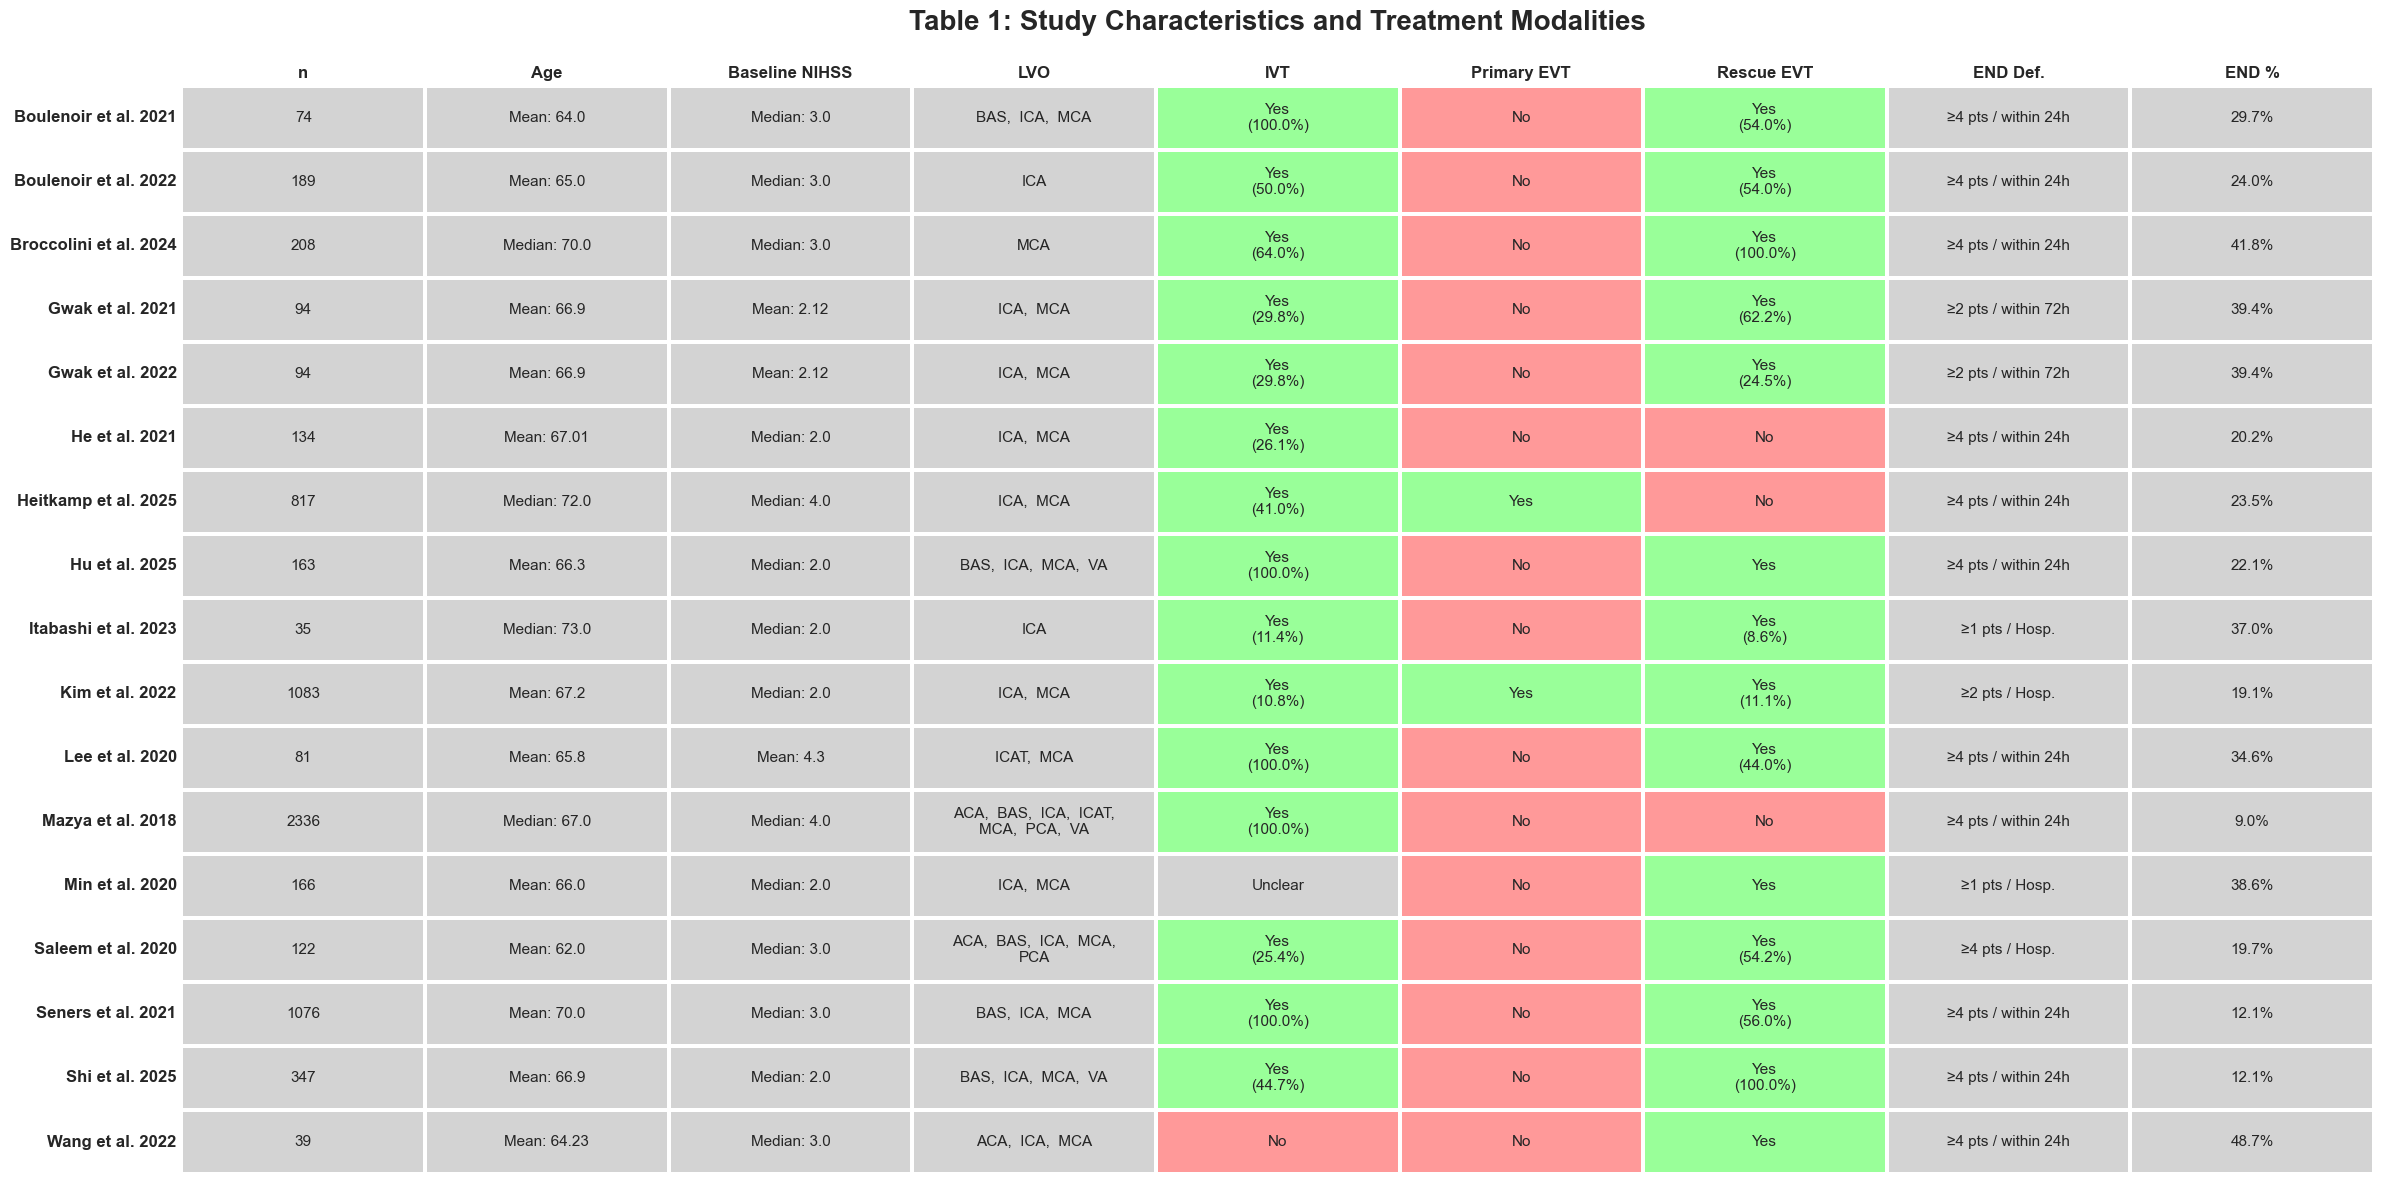

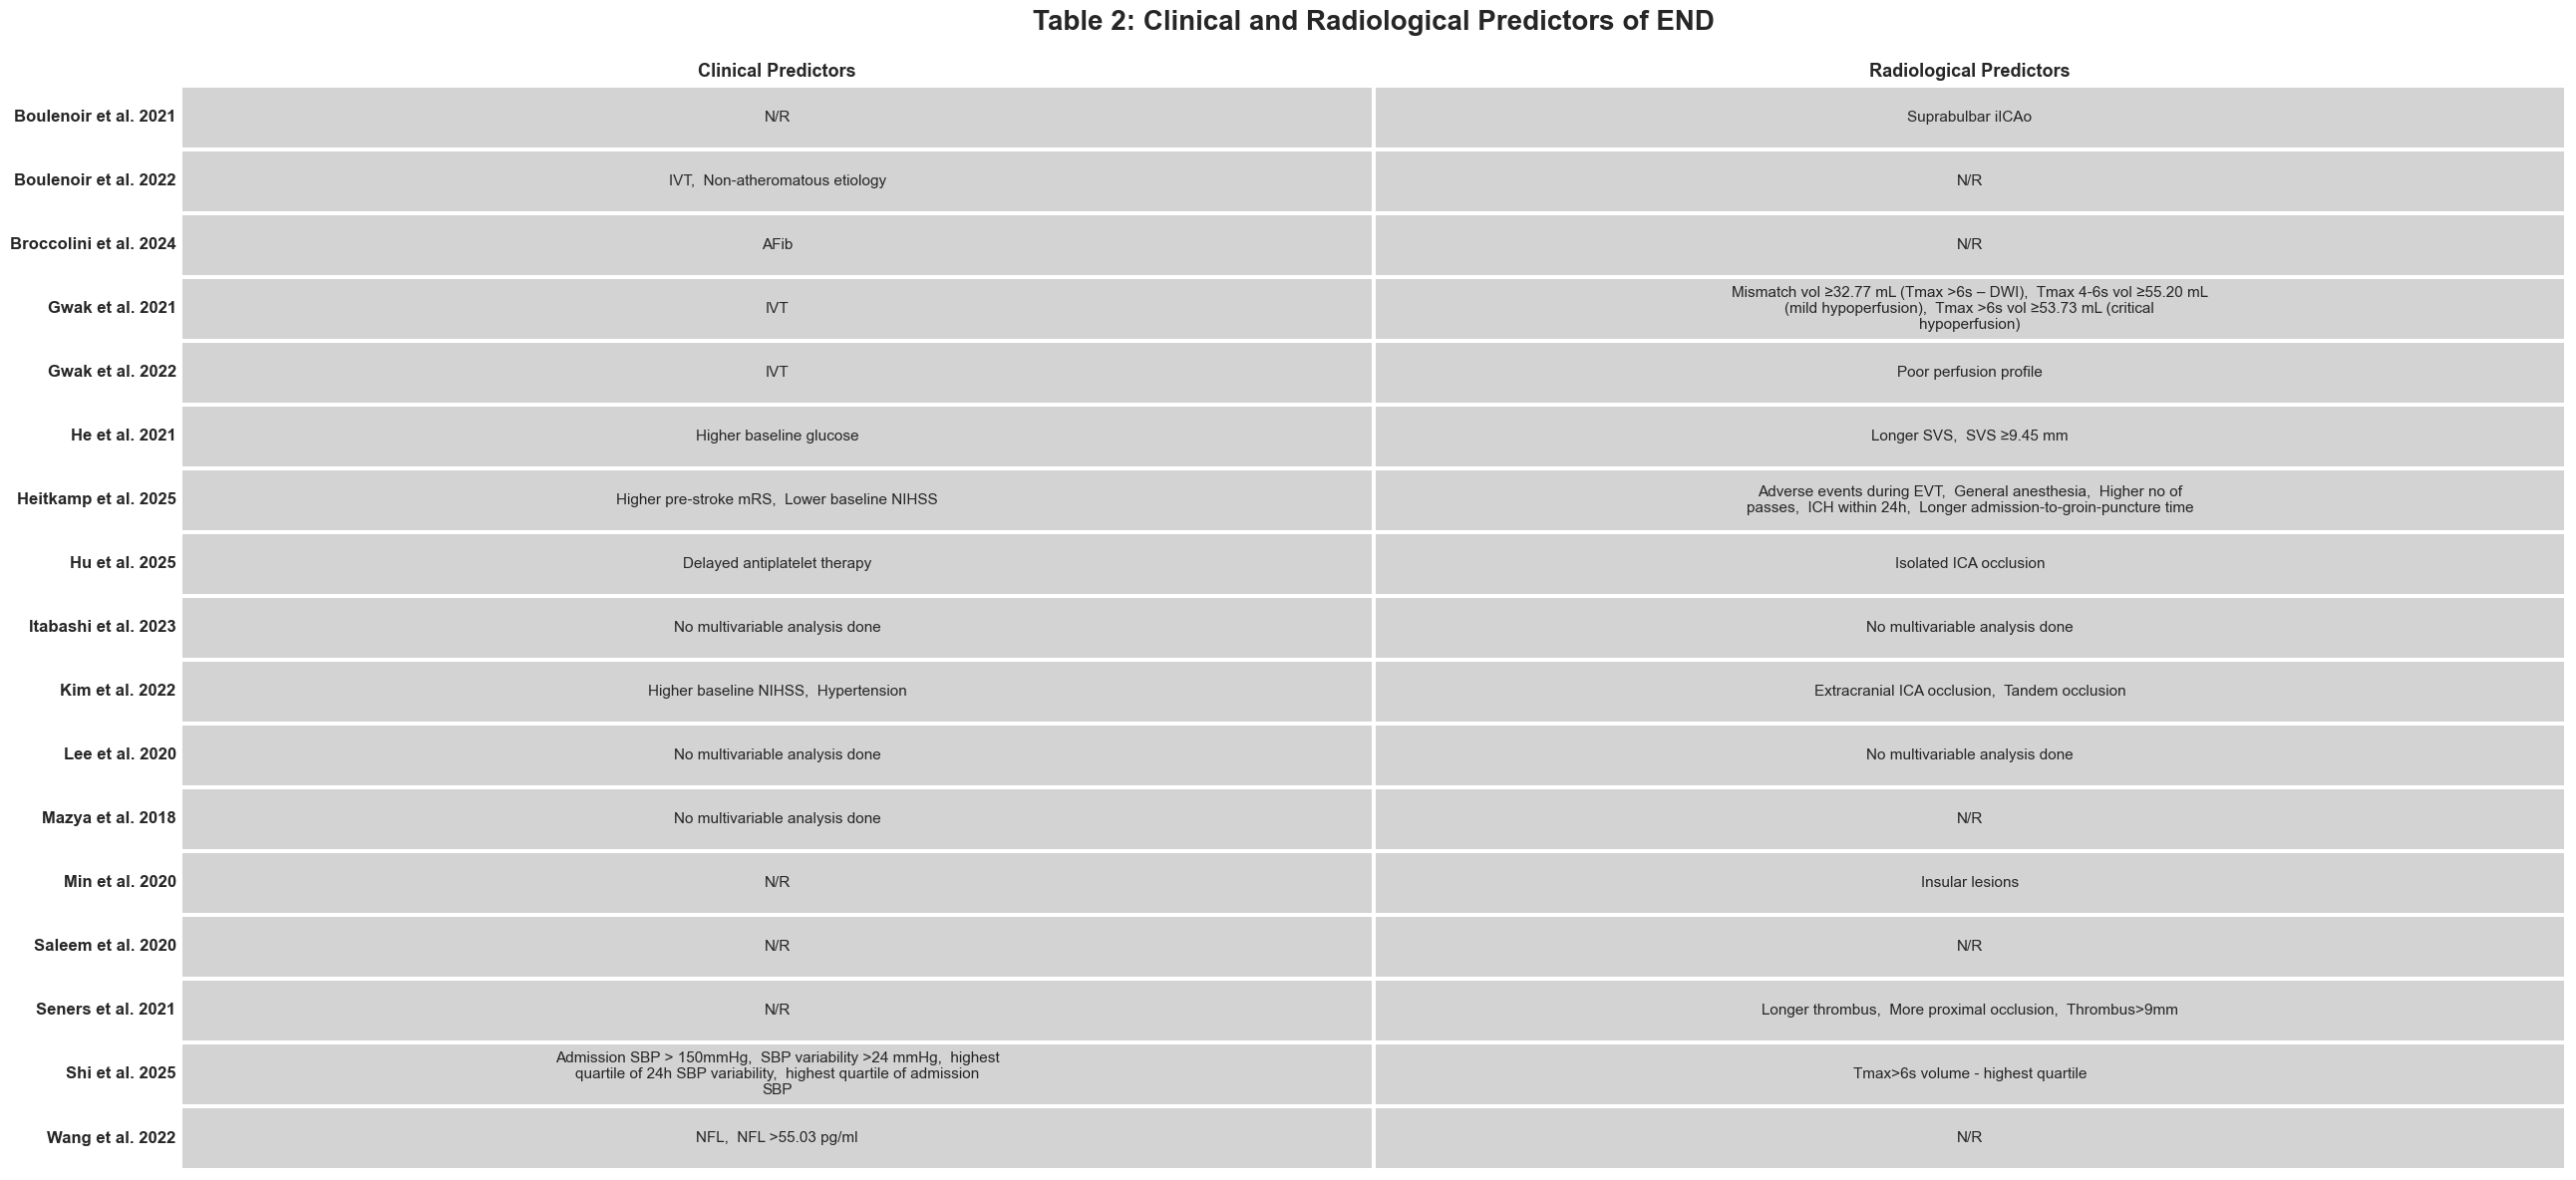

In [71]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORS
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. ROBUST HELPERS
def safe_wrap(text, width=20): 
    if isinstance(text, (list, set, np.ndarray)):
        if len(text) == 0: return "N/R"
        text = ", ".join(map(str, text))
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "N/R"
    return "\n".join(textwrap.wrap(str(text).replace(',', ', '), width=width))

def get_age_display(row):
    med, avg = row.get('median_age'), row.get('mean_age')
    if pd.notna(med) and str(med).lower() != 'nan': return f"Median: {med}"
    if pd.notna(avg) and str(avg).lower() != 'nan': return f"Mean: {avg}"
    return "N/R"

def get_nihss_display(row):
    med, avg = row.get('median_nihss'), row.get('mean_nihss')
    if pd.notna(med) and str(med).lower() != 'nan': return f"Median: {med}"
    if pd.notna(avg) and str(avg).lower() != 'nan': return f"Mean: {avg}"
    return "N/R"

def get_end_definition(row):
    delta, hours = row.get('end_delta_nihss'), row.get('end_hours')
    d_str = f"≥{int(delta)} pts" if pd.notna(delta) else "Any Δ"
    t_str = "Hosp." if pd.isna(hours) else f"within {int(hours)}h"
    return f"{d_str} / {t_str}" # Removed \n to keep row thin

# --- PART 1: CLINICAL & TREATMENT DATA ---
cols1 = ['n', 'Age', 'Baseline NIHSS', 'LVO', 'IVT', 'Primary EVT', 'Rescue EVT', 'END Def.', 'END %']
color_df1 = pd.DataFrame(index=df.index)
annot_df1 = pd.DataFrame(index=df.index)

for col in cols1:
    if col in ['IVT', 'Primary EVT', 'Rescue EVT']:
        key = col.lower().replace(' ', '_')
        color_df1[col] = df[key].map(color_map).fillna(0.5).values
    else:
        color_df1[col] = 0.5

annot_df1['n'] = [f"{int(x)}" if pd.notna(x) else "N/R" for x in df['sample_size']]
annot_df1['Age'] = df.apply(get_age_display, axis=1)
annot_df1['Baseline NIHSS'] = df.apply(get_nihss_display, axis=1)
annot_df1['LVO'] = [safe_wrap(x, 25) for x in df['lvo_definition_list']]
annot_df1['IVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END Def.'] = df.apply(get_end_definition, axis=1)
annot_df1['END %'] = [f"{p*100:.1f}%" if pd.notna(p) else "N/R" for p in df['pct_end']]

# Figsize height reduced to 12 for thinner rows
fig1, ax1 = plt.subplots(figsize=(24, 12))
sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 11, "weight": "normal"}, ax=ax1)

# --- PART 2: PREDICTORS ---
cols2 = ['Clinical Predictors', 'Radiological Predictors']
color_df2 = pd.DataFrame(0.5, index=df.index, columns=cols2)
annot_df2 = pd.DataFrame(index=df.index)
# Width increased to 65 to keep text on fewer lines
annot_df2['Clinical Predictors'] = [safe_wrap(x, 65) for x in df['clinical_predictors_multi']]
annot_df2['Radiological Predictors'] = [safe_wrap(x, 65) for x in df['radiological_predictors_multi']]

# Figsize height reduced to 12
fig2, ax2 = plt.subplots(figsize=(26, 12))
sns.heatmap(color_df2, annot=annot_df2, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 11, "weight": "normal", "va": "center"}, ax=ax2)

# --- FINAL FORMATTING ---
ax1.set_yticklabels(df['display_name'], rotation=0, fontsize=12, fontweight='bold')
ax2.set_yticklabels(df['display_name'], rotation=0, fontsize=12, fontweight='bold')

for ax in [ax1, ax2]:
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0) # Hidden ticks
    ax.set_ylabel("")

plt.setp(ax1.get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(ax2.get_xticklabels(), fontsize=13, fontweight='bold')

ax1.set_title("Table 1: Study Characteristics and Treatment Modalities", fontsize=20, pad=40, fontweight='bold')
ax2.set_title("Table 2: Clinical and Radiological Predictors of END", fontsize=20, pad=40, fontweight='bold')

fig1.tight_layout()
fig2.tight_layout()

# Export
fig1.savefig("Table1_ThinRows.pdf")
fig2.savefig("Table2_ThinRows.pdf")

plt.show()

### T1 Studies characteristics

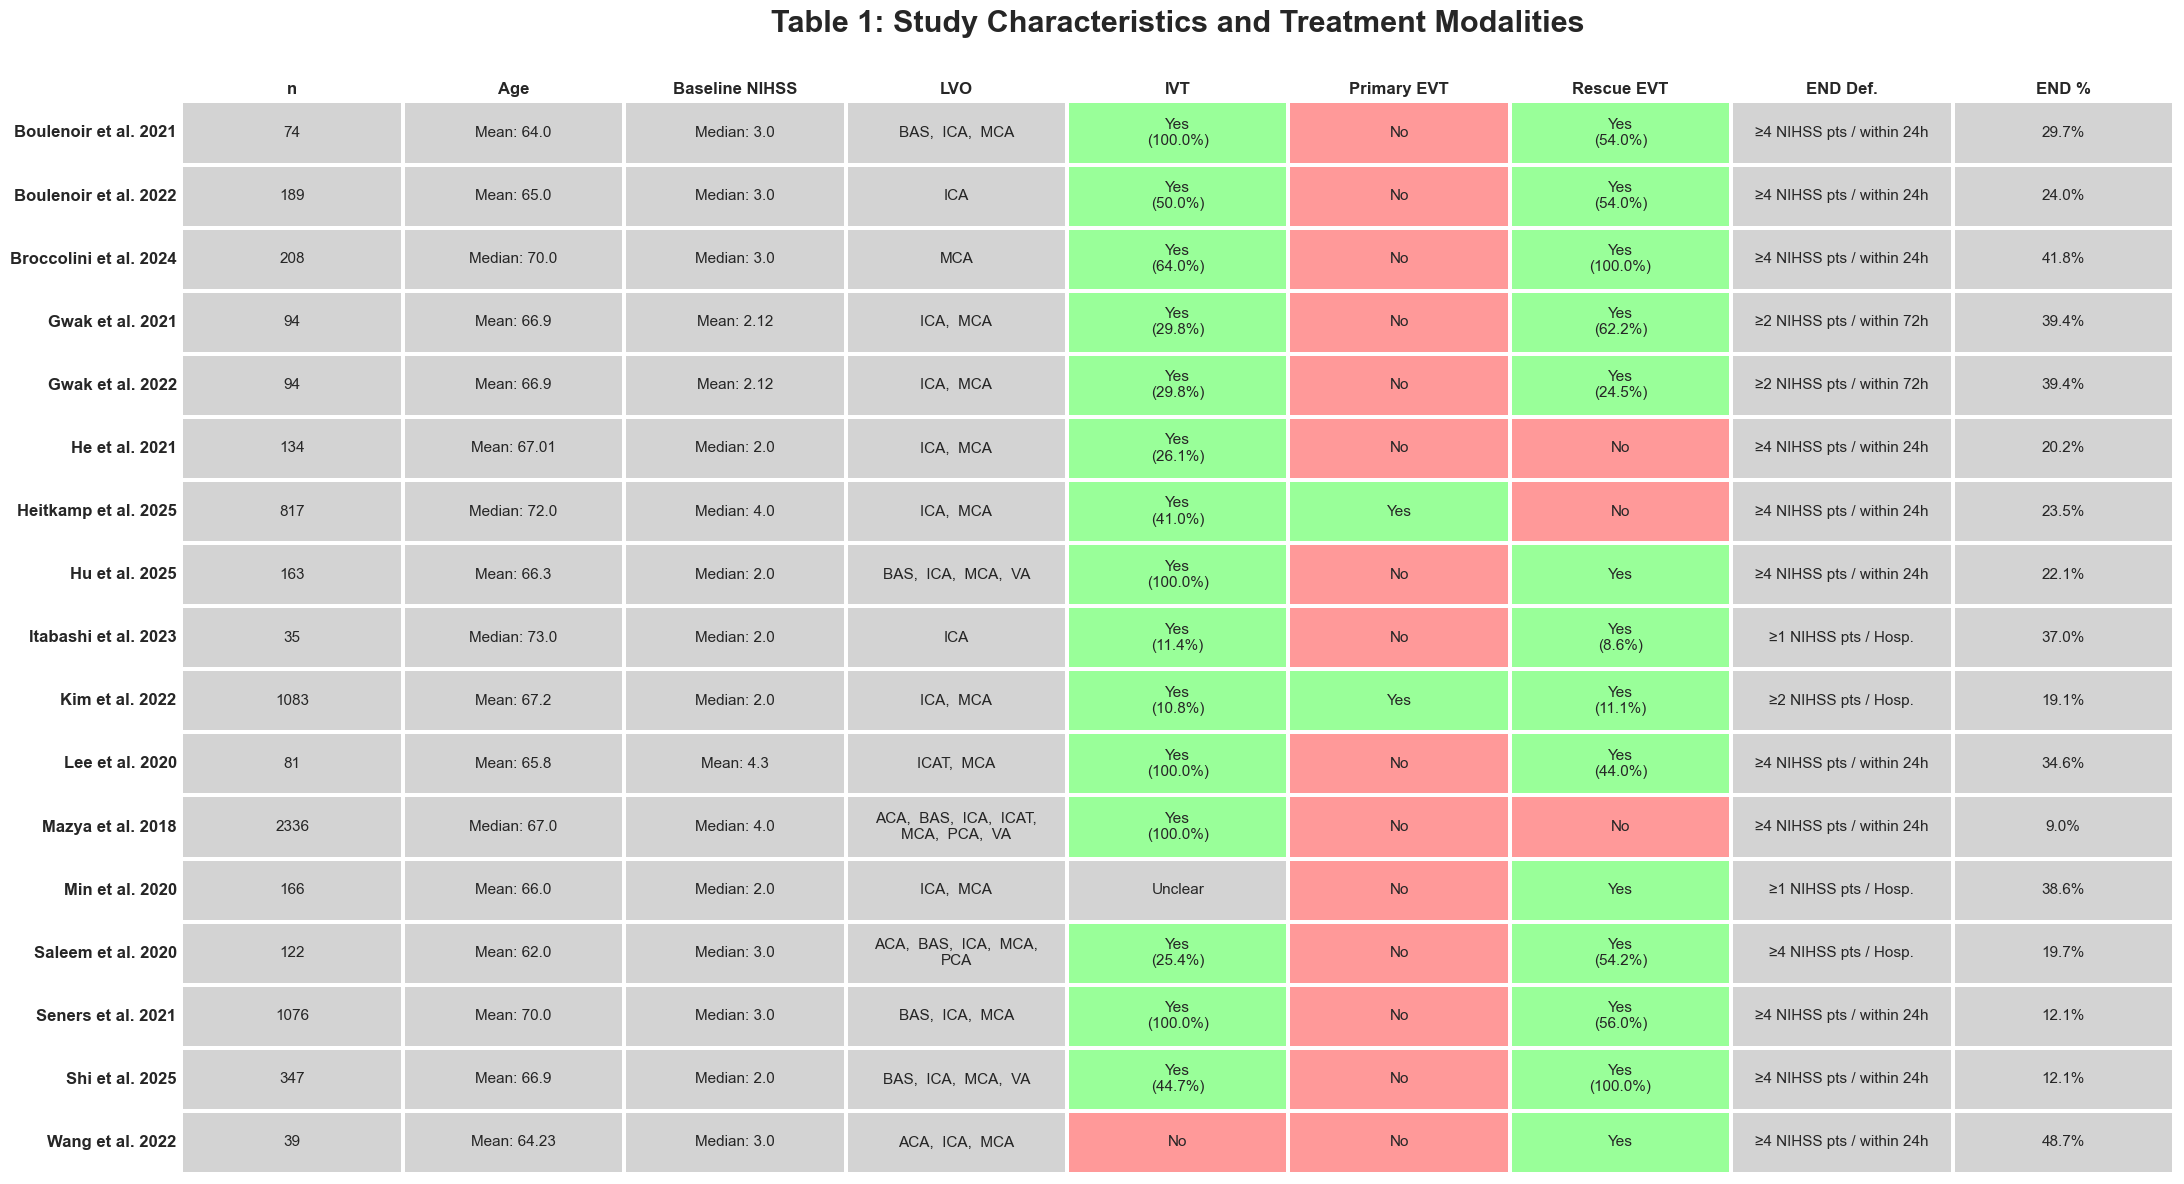

In [72]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORS (Red, Gray, Green)
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. ROBUST HELPERS
def safe_wrap(text, width=20): 
    if isinstance(text, (list, set, np.ndarray)):
        if len(text) == 0: return "N/R"
        text = ", ".join(map(str, text))
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "N/R"
    return "\n".join(textwrap.wrap(str(text).replace(',', ', '), width=width))

def get_age_display(row):
    med, avg = row.get('median_age'), row.get('mean_age')
    if pd.notna(med) and str(med).lower() != 'nan': return f"Median: {med}"
    if pd.notna(avg) and str(avg).lower() != 'nan': return f"Mean: {avg}"
    return "N/R"

def get_nihss_display(row):
    med, avg = row.get('median_nihss'), row.get('mean_nihss')
    if pd.notna(med) and str(med).lower() != 'nan': return f"Median: {med}"
    if pd.notna(avg) and str(avg).lower() != 'nan': return f"Mean: {avg}"
    return "N/R"

def get_end_definition(row):
    delta, hours = row.get('end_delta_nihss'), row.get('end_hours')
    d_str = f"≥{int(delta)} NIHSS pts" if pd.notna(delta) else "Any Δ"
    t_str = "Hosp." if pd.isna(hours) else f"within {int(hours)}h"
    return f"{d_str} / {t_str}"

# 4. DATA PREPARATION (Clinical & Treatment Summary)
cols1 = ['n', 'Age', 'Baseline NIHSS', 'LVO', 'IVT', 'Primary EVT', 'Rescue EVT', 'END Def.', 'END %']
color_df1 = pd.DataFrame(index=df.index)
annot_df1 = pd.DataFrame(index=df.index)

for col in cols1:
    # Color logic: only treatment columns get Red/Green
    if col in ['IVT', 'Primary EVT', 'Rescue EVT']:
        key = col.lower().replace(' ', '_')
        color_df1[col] = df[key].map(color_map).fillna(0.5).values
    else:
        color_df1[col] = 0.5

# Populate annotations
annot_df1['n'] = [f"{int(x)}" if pd.notna(x) else "N/R" for x in df['sample_size']]
annot_df1['Age'] = df.apply(get_age_display, axis=1)
annot_df1['Baseline NIHSS'] = df.apply(get_nihss_display, axis=1)
annot_df1['LVO'] = [safe_wrap(x, 25) for x in df['lvo_definition_list']]
annot_df1['IVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END Def.'] = df.apply(get_end_definition, axis=1)
annot_df1['END %'] = [f"{p*100:.1f}%" if pd.notna(p) else "N/R" for p in df['pct_end']]

# 5. PLOTTING
# Adjusted figsize: width 22, height 12 for thin rows
fig, ax = plt.subplots(figsize=(22, 12))

sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 11, "weight": "normal"}, ax=ax)

# 6. FINAL FORMATTING
ax.set_yticklabels(df['display_name'], rotation=0, fontsize=12, fontweight='bold')

# Move labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Remove those "little lines" (ticks)
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel("")

plt.setp(ax.get_xticklabels(), fontsize=12, fontweight='bold')
ax.set_title("Table 1: Study Characteristics and Treatment Modalities", fontsize=22, pad=50, fontweight='bold')

plt.tight_layout()

# 7. EXPORT
plt.savefig("Table1_Clinical_Summary.pdf", bbox_inches='tight')
plt.show()

### T2 Predictors

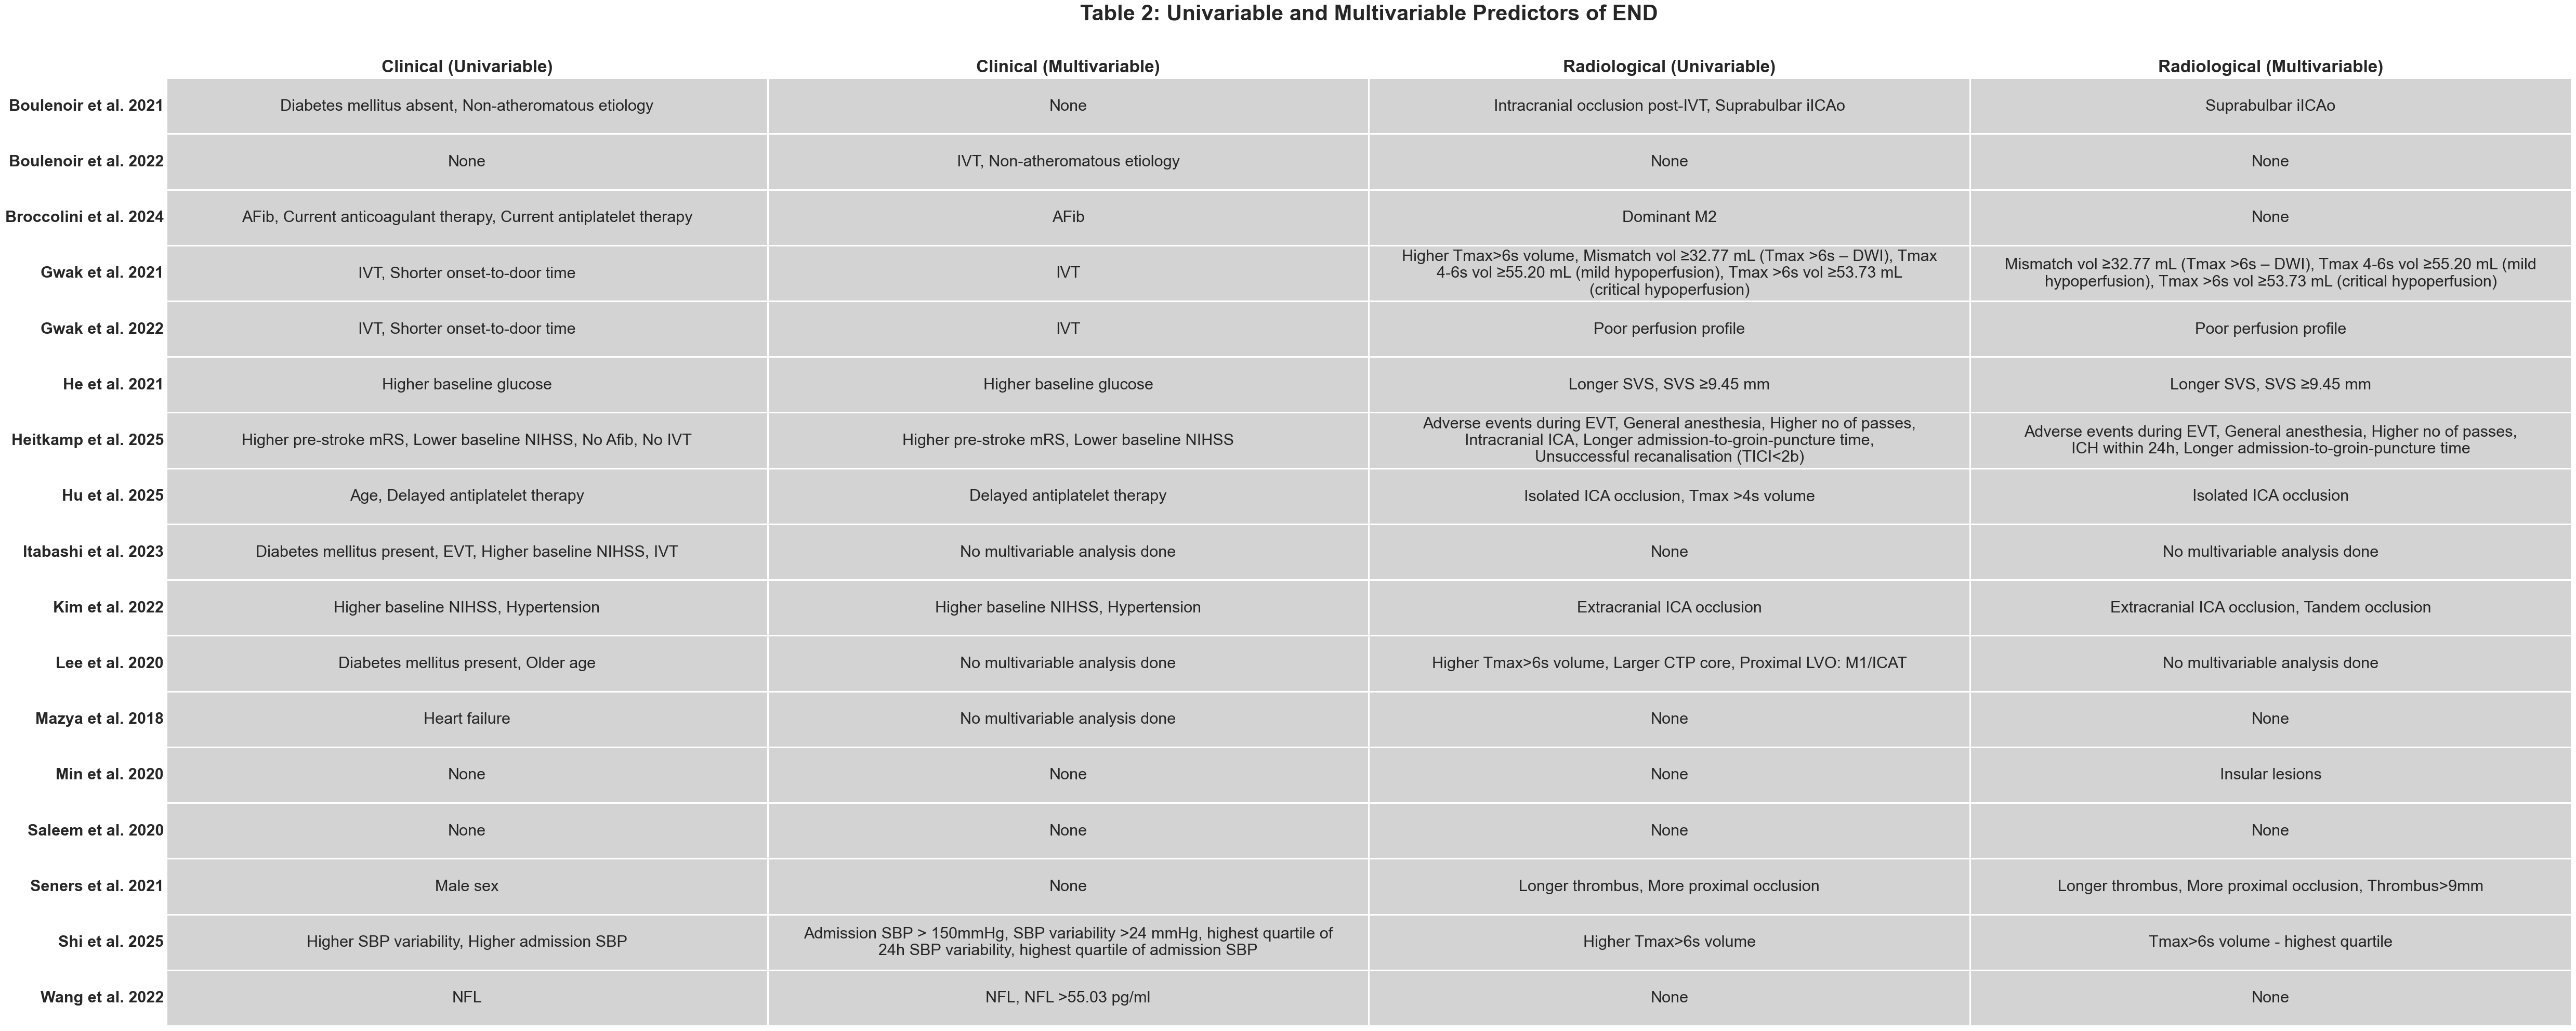

In [73]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORS
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)

# 3. ROBUST HELPERS
# Increase width to 60 so text spreads out horizontally
def safe_wrap(text, width=60): 
    if isinstance(text, (list, set, np.ndarray)):
        if len(text) == 0: return "None"
        text = ", ".join(map(str, text))
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "None"
    
    clean_text = str(text).replace(',', ', ').replace('  ', ' ')
    return "\n".join(textwrap.wrap(clean_text, width=width))

# --- PART 2: THE EXPANDED PREDICTORS TABLE ---
cols2 = [
    'Clinical (Univariable)', 'Clinical (Multivariable)', 
    'Radiological (Univariable)', 'Radiological (Multivariable)'
]

color_df2 = pd.DataFrame(0.5, index=df.index, columns=cols2)
annot_df2 = pd.DataFrame(index=df.index)

# Width 60 makes the cells "wider" and "shorter"
annot_df2['Clinical (Univariable)'] = [safe_wrap(x, 70) for x in df['clinical_predictors_uni_list']]
annot_df2['Clinical (Multivariable)'] = [safe_wrap(x, 70) for x in df['clinical_predictors_multi_list']]
annot_df2['Radiological (Univariable)'] = [safe_wrap(x, 70) for x in df['radiological_predictors_uni_list']]
annot_df2['Radiological (Multivariable)'] = [safe_wrap(x, 70) for x in df['radiological_predictors_multi_list']]

# 4. PLOTTING - MASSIVE CANVAS
# Width increased to 50, Height to 20 to ensure plenty of room for 13pt font
fig2, ax2 = plt.subplots(figsize=(50, 20))

sns.heatmap(color_df2, annot=annot_df2, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=2, linecolor='white', 
            # Increased font size to 13pt and removed bold
            annot_kws={"size": 22, "weight": "normal", "va": "center", "ha": "center"}, ax=ax2)

# --- FINAL FORMATTING ---
ax2.set_yticklabels(df['display_name'], rotation=0, fontsize=22, fontweight='bold')
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')

# Remove the "little lines"
ax2.tick_params(axis='both', which='both', length=0)
ax2.set_ylabel("")

plt.setp(ax2.get_xticklabels(), fontsize=24, fontweight='bold')
ax2.set_title("Table 2: Univariable and Multivariable Predictors of END", fontsize=30, pad=80, fontweight='bold')

plt.tight_layout()

# 5. EXPORT AS PDF
# This is crucial: a PDF will let you zoom in on the text without blur
plt.savefig("Table2_Predictors_Readable.pdf", bbox_inches='tight', dpi=300)
plt.show()

### Best overview?

#### Without Minor stroke definition

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\2859882812.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


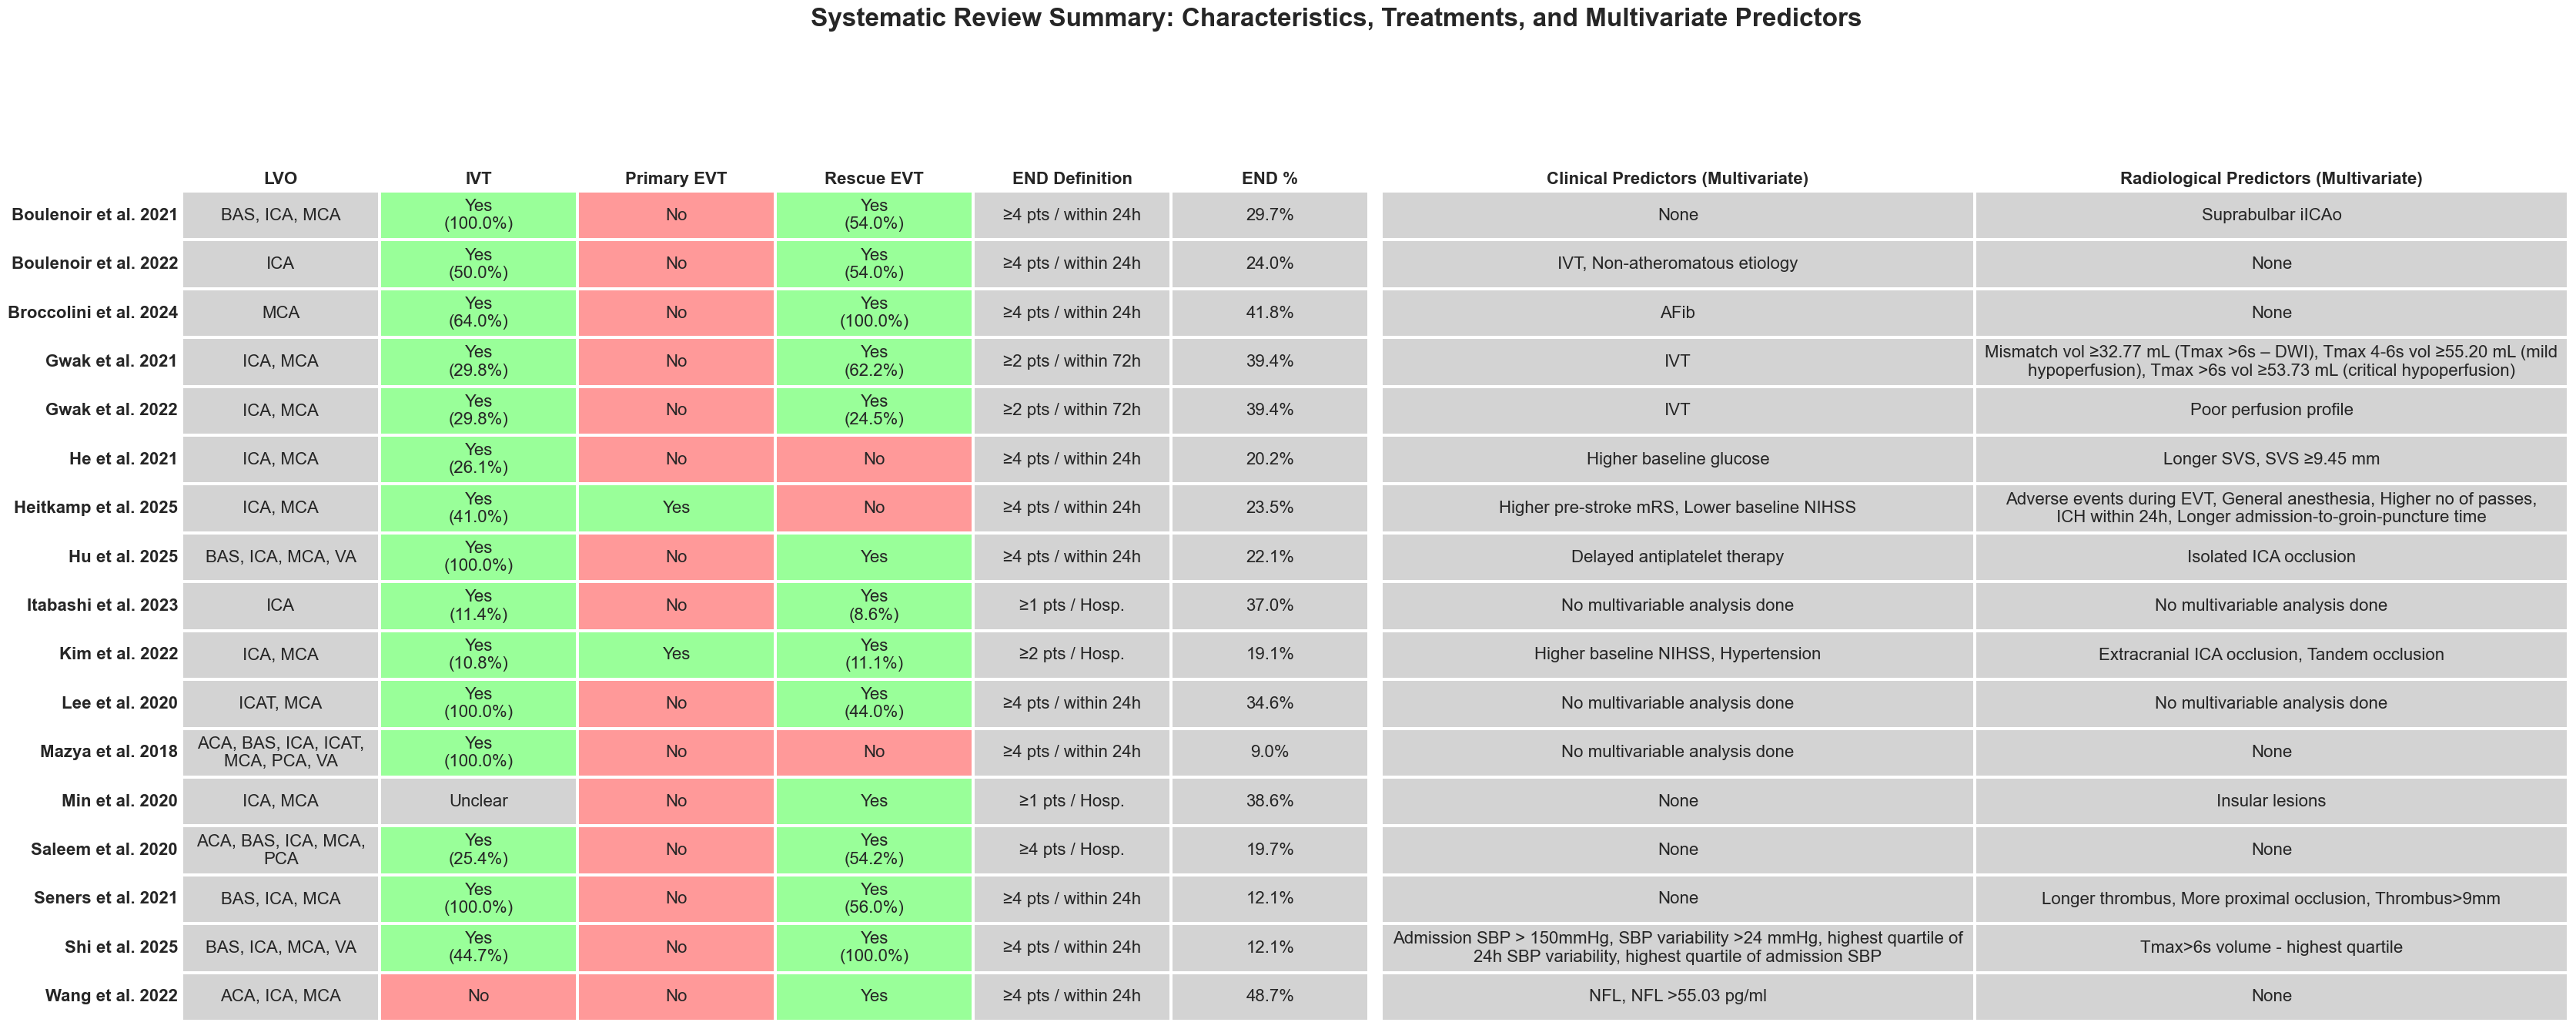

In [74]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORS
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. ROBUST HELPERS
def safe_wrap(text, width=80): 
    if isinstance(text, (list, set, np.ndarray)):
        if len(text) == 0: return "None"
        text = ", ".join(map(str, text))
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "None"
    clean_text = str(text).replace(',', ', ').replace('  ', ' ')
    return "\n".join(textwrap.wrap(clean_text, width=width))

def get_end_definition(row):
    delta, hours = row.get('end_delta_nihss'), row.get('end_hours')
    d_str = f"≥{int(delta)} pts" if pd.notna(delta) else "Any Δ"
    t_str = "Hosp." if pd.isna(hours) else f"within {int(hours)}h"
    return f"{d_str} / {t_str}"

# 4. DATA PREPARATION
# Group 1: Characteristics & Treatments (Removed n and Age)
cols1 = ['LVO', 'IVT', 'Primary EVT', 'Rescue EVT', 'END Definition', 'END %']
color_df1 = pd.DataFrame(index=df.index)
annot_df1 = pd.DataFrame(index=df.index)

# Group 2: Multivariate Predictors Only
cols2 = ['Clinical Predictors (Multivariate)', 'Radiological Predictors (Multivariate)']
color_df2 = pd.DataFrame(0.5, index=df.index, columns=cols2)
annot_df2 = pd.DataFrame(index=df.index)

# Fill Group 1
for col in cols1:
    if col in ['IVT', 'Primary EVT', 'Rescue EVT']:
        key = col.lower().replace(' ', '_')
        color_df1[col] = df[key].map(color_map).fillna(0.5).values
    else:
        color_df1[col] = 0.5

annot_df1['LVO'] = [safe_wrap(x, 20) for x in df['lvo_definition_list']]
annot_df1['IVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END Definition'] = df.apply(get_end_definition, axis=1)
annot_df1['END %'] = [f"{p*100:.1f}%" if pd.notna(p) else "N/R" for p in df['pct_end']]

# Fill Group 2 (Wider wrap for readability)
annot_df2['Clinical Predictors (Multi)'] = [safe_wrap(x, 70) for x in df['clinical_predictors_multi_list']]
annot_df2['Radiological Predictors (Multi)'] = [safe_wrap(x, 70) for x in df['radiological_predictors_multi_list']]

# 5. PLOTTING
# Width (40) is still large to ensure predictors breathe, Height (14) for thin rows
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 14), 
                               gridspec_kw={'width_ratios': [2, 2], 'wspace': 0.01})

# Table 1: Status & Characteristics
sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 16, "weight": "normal"}, ax=ax1)

# Table 2: Multivariate Predictors
sns.heatmap(color_df2, annot=annot_df2, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 16, "weight": "normal", "va": "center"}, ax=ax2)

# 6. FINAL FORMATTING
ax1.set_yticklabels(df['display_name'], rotation=0, fontsize=16, fontweight='bold')
ax2.set_yticklabels([]) # Hide duplicate study names

for ax in [ax1, ax2]:
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), fontsize=16, fontweight='bold')

fig.suptitle('Systematic Review Summary: Characteristics, Treatments, and Multivariate Predictors', 
             fontsize=24, y=1.05, fontweight='bold')

plt.tight_layout()

# 7. EXPORT
plt.savefig("Multivariate_Matrix_No_Demographics.pdf", bbox_inches='tight', dpi=300)
plt.show()

#### With minor stroke definition

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\2420995401.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


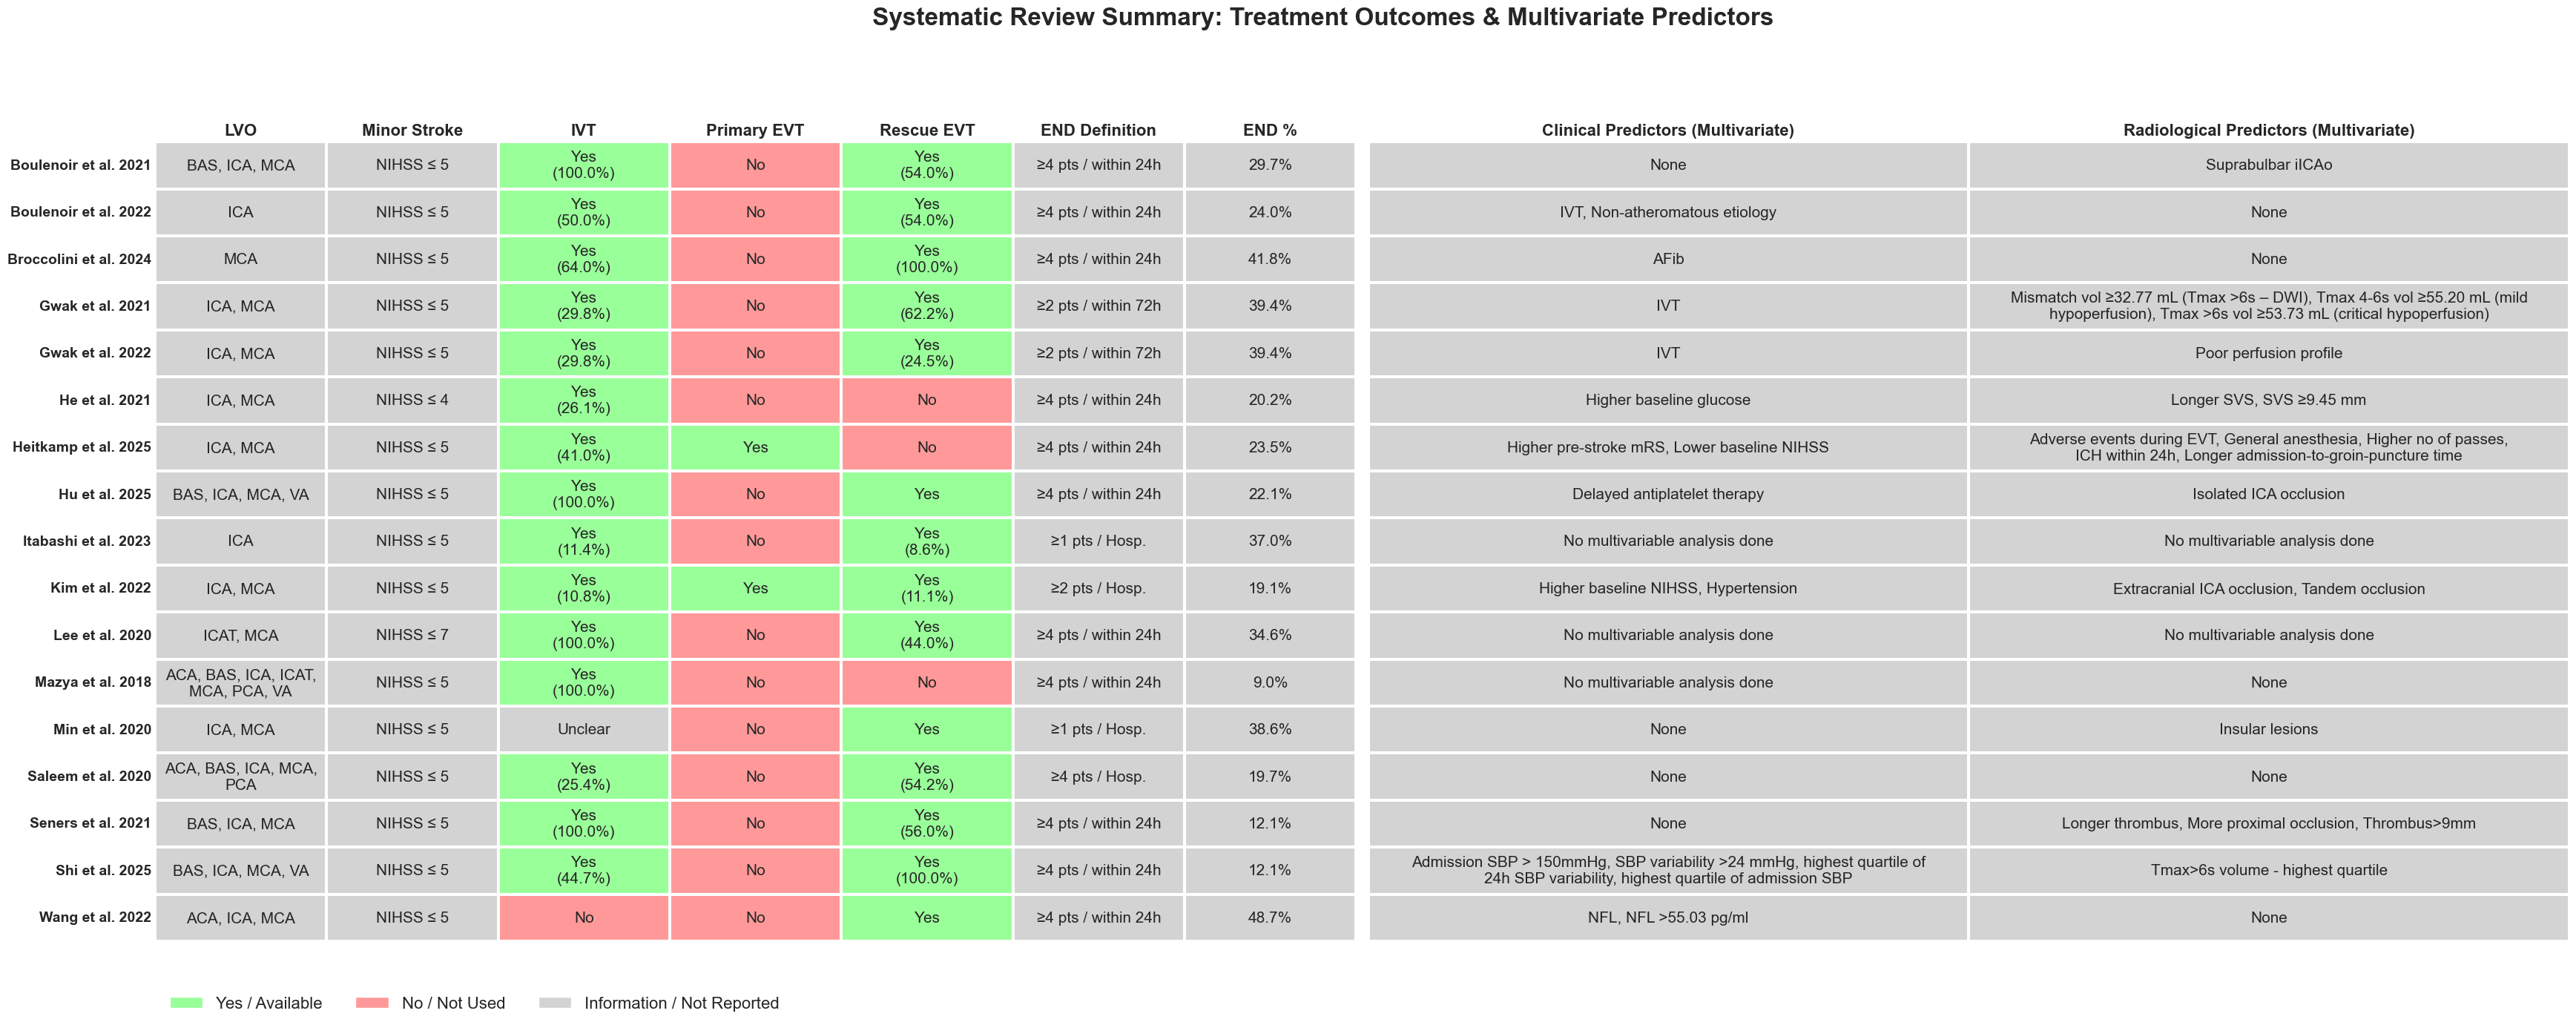

In [75]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORS
my_colors = ["#ff9999", "#d3d3d3", "#99ff99"] 
my_cmap = ListedColormap(my_colors)
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# 3. ROBUST HELPERS
def safe_wrap(text, width=65): 
    if isinstance(text, (list, set, np.ndarray)):
        if len(text) == 0: return "None"
        text = ", ".join(map(str, text))
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "None"
    clean_text = str(text).replace(',', ', ').replace('  ', ' ')
    return "\n".join(textwrap.wrap(clean_text, width=width))

def get_minor_stroke_display(row):
    val = row.get('ms_max_nihss')
    if pd.notna(val) and str(val).lower() != 'nan':
        return f"NIHSS ≤ {int(val)}"
    return "N/R"

def get_end_definition(row):
    delta, hours = row.get('end_delta_nihss'), row.get('end_hours')
    d_str = f"≥{int(delta)} pts" if pd.notna(delta) else "Any Δ"
    t_str = "Hosp." if pd.isna(hours) else f"within {int(hours)}h"
    return f"{d_str} / {t_str}"

# 4. DATA PREPARATION
cols1 = ['LVO', 'Minor Stroke', 'IVT', 'Primary EVT', 'Rescue EVT', 'END Definition', 'END %']
color_df1 = pd.DataFrame(index=df.index)
annot_df1 = pd.DataFrame(index=df.index)

cols2 = ['Clinical Predictors (Multivariate)', 'Radiological Predictors (Multivariate)']
color_df2 = pd.DataFrame(0.5, index=df.index, columns=cols2)
annot_df2 = pd.DataFrame(index=df.index)

# Fill Group 1
for col in cols1:
    if col in ['IVT', 'Primary EVT', 'Rescue EVT']:
        key = col.lower().replace(' ', '_')
        color_df1[col] = df[key].map(color_map).fillna(0.5).values
    else:
        color_df1[col] = 0.5

annot_df1['LVO'] = [safe_wrap(x, 20) for x in df['lvo_definition_list']] # Narrower wrap
annot_df1['Minor Stroke'] = df.apply(get_minor_stroke_display, axis=1)
annot_df1['IVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END Definition'] = df.apply(get_end_definition, axis=1)
annot_df1['END %'] = [f"{p*100:.1f}%" if pd.notna(p) else "N/R" for p in df['pct_end']]

# Fill Group 2
annot_df2['Clinical Predictors (Multivariate)'] = [safe_wrap(x, 70) for x in df['clinical_predictors_multi_list']]
annot_df2['Radiological Predictors (Multivariate)'] = [safe_wrap(x, 70) for x in df['radiological_predictors_multi_list']]

# 5. PLOTTING
# width_ratios changed to [1.6, 2] to shrink the left side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(42, 14), 
                               gridspec_kw={'width_ratios': [1.6, 1.6], 'wspace': 0.01})

sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 15, "weight": "normal"}, ax=ax1)

sns.heatmap(color_df2, annot=annot_df2, fmt="", cmap=my_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 15, "weight": "normal", "va": "center"}, ax=ax2)

# 6. FINAL FORMATTING
ax1.set_yticklabels(df['display_name'], rotation=0, fontsize=14, fontweight='bold')
ax2.set_yticklabels([]) 

for ax in [ax1, ax2]:
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), fontsize=16, fontweight='bold')

# 7. LEGEND
legend_elements = [
    Patch(facecolor='#99ff99', edgecolor='white', label='Yes / Available'),
    Patch(facecolor='#ff9999', edgecolor='white', label='No / Not Used'),
    Patch(facecolor='#d3d3d3', edgecolor='white', label='Information / Not Reported')
]
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, -0.05), 
           ncol=3, fontsize=16, frameon=False)

fig.suptitle('Systematic Review Summary: Treatment Outcomes & Multivariate Predictors', 
             fontsize=24, y=1.01, fontweight='bold')

plt.tight_layout()
plt.savefig("Multivariate_Matrix_Compact.pdf", bbox_inches='tight', dpi=300)
plt.show()

#### Color coded END%

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\230491716.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


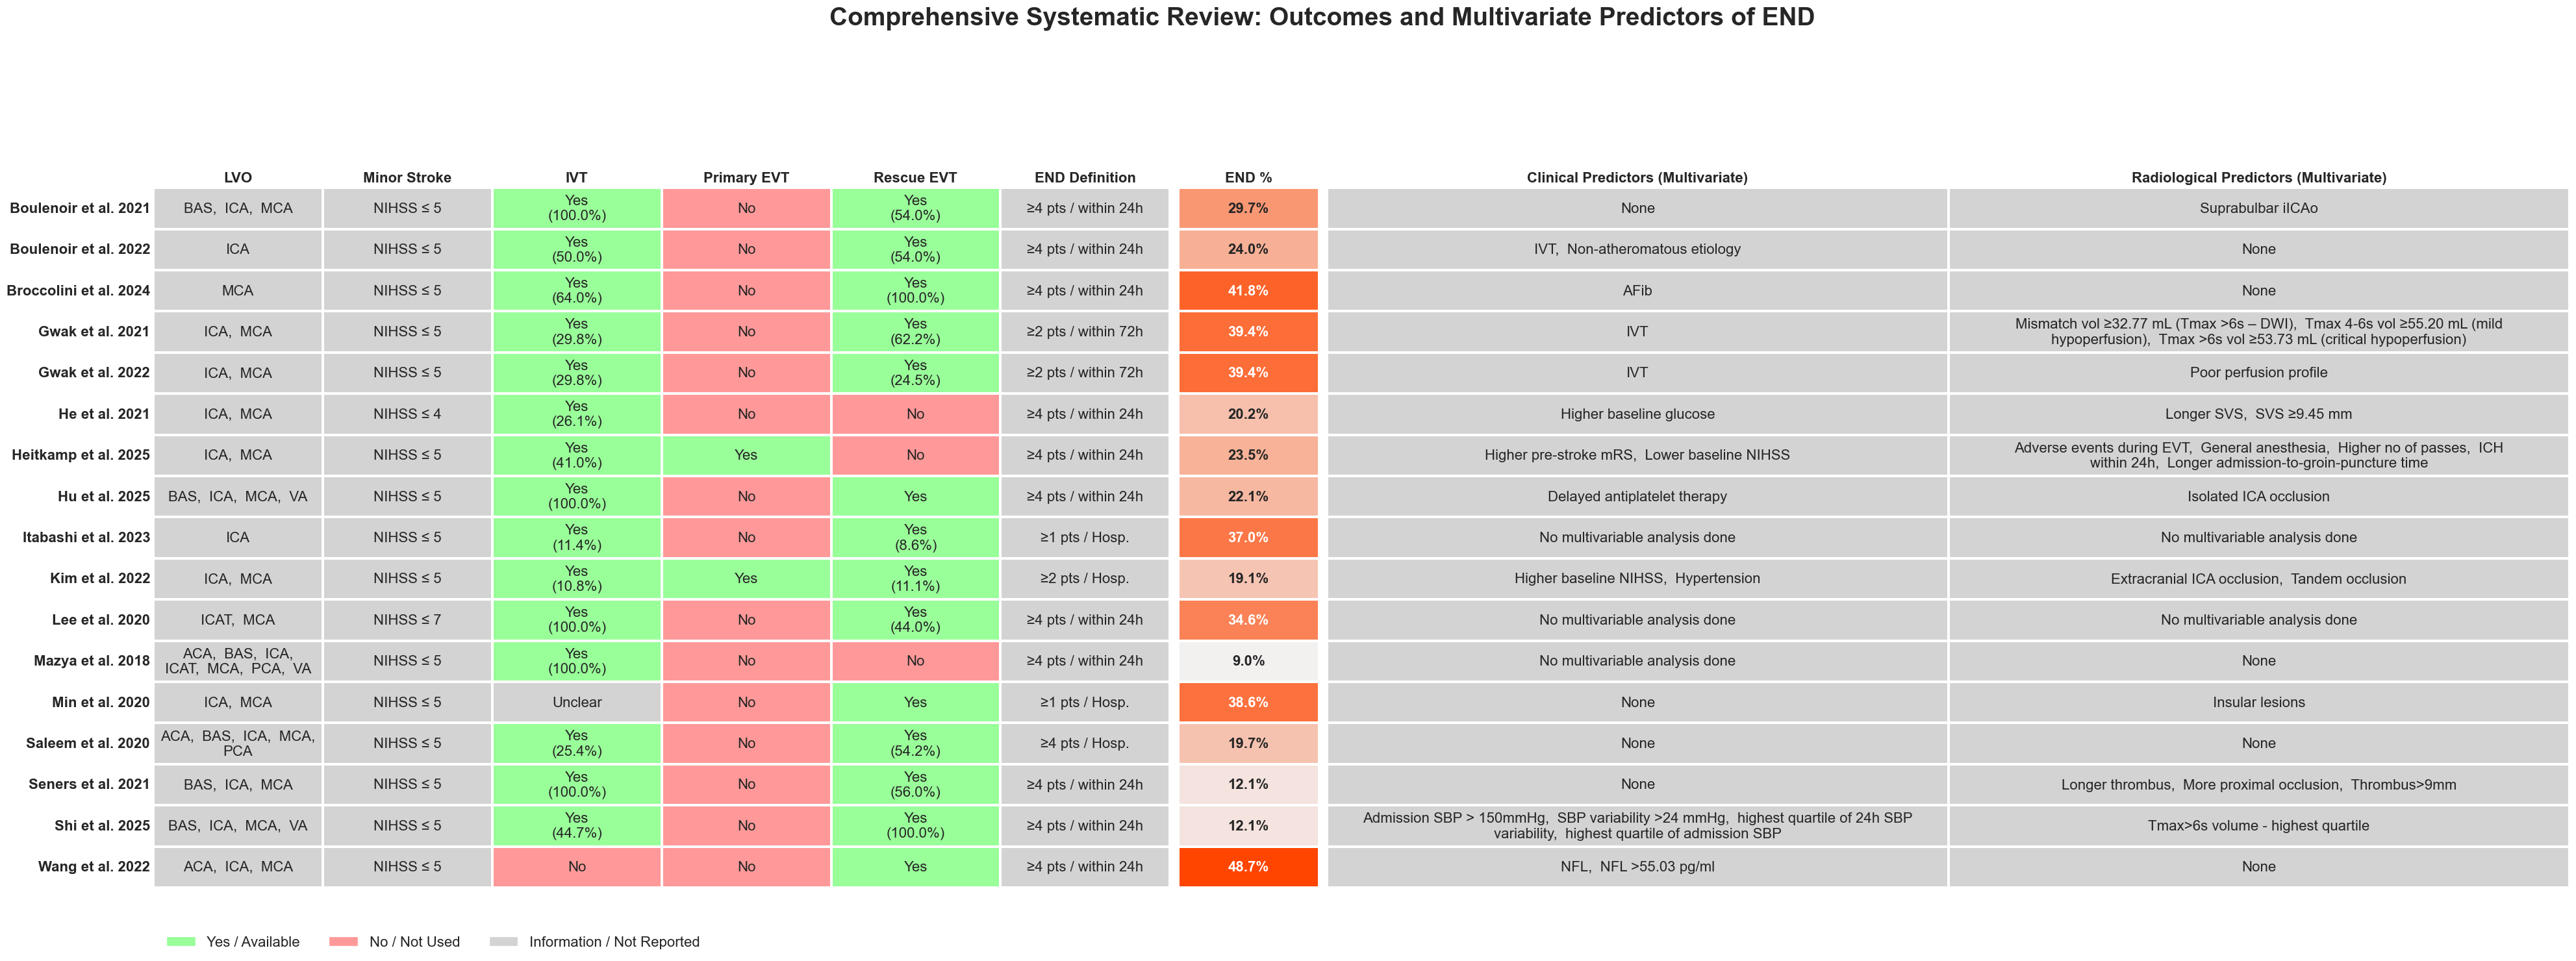

In [76]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('display_name', ascending=True).reset_index(drop=True)

# 2. SETUP COLORMAPS
# Table 1 & 3: Solid Red/Gray/Green
cat_cmap = ListedColormap(["#ff9999", "#d3d3d3", "#99ff99"]) 
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# Table 2 (END %): Sequential Gradient (Light Orange to Deep Red/Orange)
end_cmap = sns.light_palette("#ff4500", as_cmap=True) 

# 3. HELPERS
def safe_wrap(text, width=65): 
    if isinstance(text, (list, set, np.ndarray)):
        text = ", ".join(map(str, text)) if len(text) > 0 else "None"
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "None"
    return "\n".join(textwrap.wrap(str(text).replace(',', ', '), width=width))

def get_end_definition(row):
    delta, hours = row.get('end_delta_nihss'), row.get('end_hours')
    d_str = f"≥{int(delta)} pts" if pd.notna(delta) else "Any Δ"
    t_str = "Hosp." if pd.isna(hours) else f"within {int(hours)}h"
    return f"{d_str} / {t_str}"

# 4. DATA PREPARATION
# --- Group 1: Categorical ---
cols1 = ['LVO', 'Minor Stroke', 'IVT', 'Primary EVT', 'Rescue EVT', 'END Definition']
color_df1 = pd.DataFrame(index=df.index)
annot_df1 = pd.DataFrame(index=df.index)

for col in cols1:
    if col in ['IVT', 'Primary EVT', 'Rescue EVT']:
        key = col.lower().replace(' ', '_')
        color_df1[col] = df[key].map(color_map).fillna(0.5).values
    else: color_df1[col] = 0.5

annot_df1['LVO'] = [safe_wrap(x, 22) for x in df['lvo_definition_list']]
annot_df1['Minor Stroke'] = [f"NIHSS ≤ {int(x)}" if pd.notna(x) else "N/R" for x in df['ms_max_nihss']]
annot_df1['IVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END Definition'] = df.apply(get_end_definition, axis=1)

# --- Group 2: Gradient (END %) ---
# We use raw numeric values for the color intensity
end_values = df['pct_end'].fillna(0).values
annot_end = [f"{p*100:.1f}%" if pd.notna(p) else "N/R" for p in df['pct_end']]

# --- Group 3: Predictors ---
cols3 = ['Clinical Predictors (Multivariate)', 'Radiological Predictors (Multivariate)']
annot_df3 = pd.DataFrame(index=df.index)
annot_df3['Clinical Predictors (Multivariate)'] = [safe_wrap(x, 80) for x in df['clinical_predictors_multi_list']]
annot_df3['Radiological Predictors (Multivariate)'] = [safe_wrap(x, 80) for x in df['radiological_predictors_multi_list']]

# 5. PLOTTING
# width_ratios: [Categorical, Gradient, Narrative]
fig, (ax1, ax_end, ax2) = plt.subplots(1, 3, figsize=(48, 14), 
                                       gridspec_kw={'width_ratios': [1.8, 0.25, 2.2], 'wspace': 0.01})

# Table 1: Categorical
sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=cat_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 16}, ax=ax1)

# Table 2: Gradient END %
sns.heatmap(end_values.reshape(-1, 1), annot=np.array(annot_end).reshape(-1, 1), fmt="", 
            cmap=end_cmap, cbar=False, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 16, "weight": "bold"}, ax=ax_end)
ax_end.set_xticklabels(['END %'], fontsize=16, fontweight='bold')

# Table 3: Predictors
sns.heatmap(pd.DataFrame(0.5, index=df.index, columns=cols3), annot=annot_df3, fmt="", 
            cmap=cat_cmap, cbar=False, vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 16, "va": "center"}, ax=ax2)

# 6. LEGEND
legend_elements = [
    Patch(facecolor='#99ff99', edgecolor='white', label='Yes / Available'),
    Patch(facecolor='#ff9999', edgecolor='white', label='No / Not Used'),
    Patch(facecolor='#d3d3d3', edgecolor='white', label='Information / Not Reported')
]
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, -0.05), 
           ncol=3, fontsize=16, frameon=False)

# 7. FINAL FORMATTING
ax1.set_yticklabels(df['display_name'], rotation=0, fontsize=16, fontweight='bold')
ax_end.set_yticklabels([]); ax2.set_yticklabels([])

for ax in [ax1, ax_end, ax2]:
    ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_ylabel("")

plt.setp(ax1.get_xticklabels(), fontsize=16, fontweight='bold')
plt.setp(ax2.get_xticklabels(), fontsize=16, fontweight='bold')

fig.suptitle('Comprehensive Systematic Review: Outcomes and Multivariate Predictors of END', 
             fontsize=28, y=1.08, fontweight='bold')

plt.tight_layout()
plt.savefig("Master_Matrix_Gradient.pdf", bbox_inches='tight')
plt.show()

#### Color coded END% ascending

C:\Users\Catalina\AppData\Local\Temp\ipykernel_295576\2590688106.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


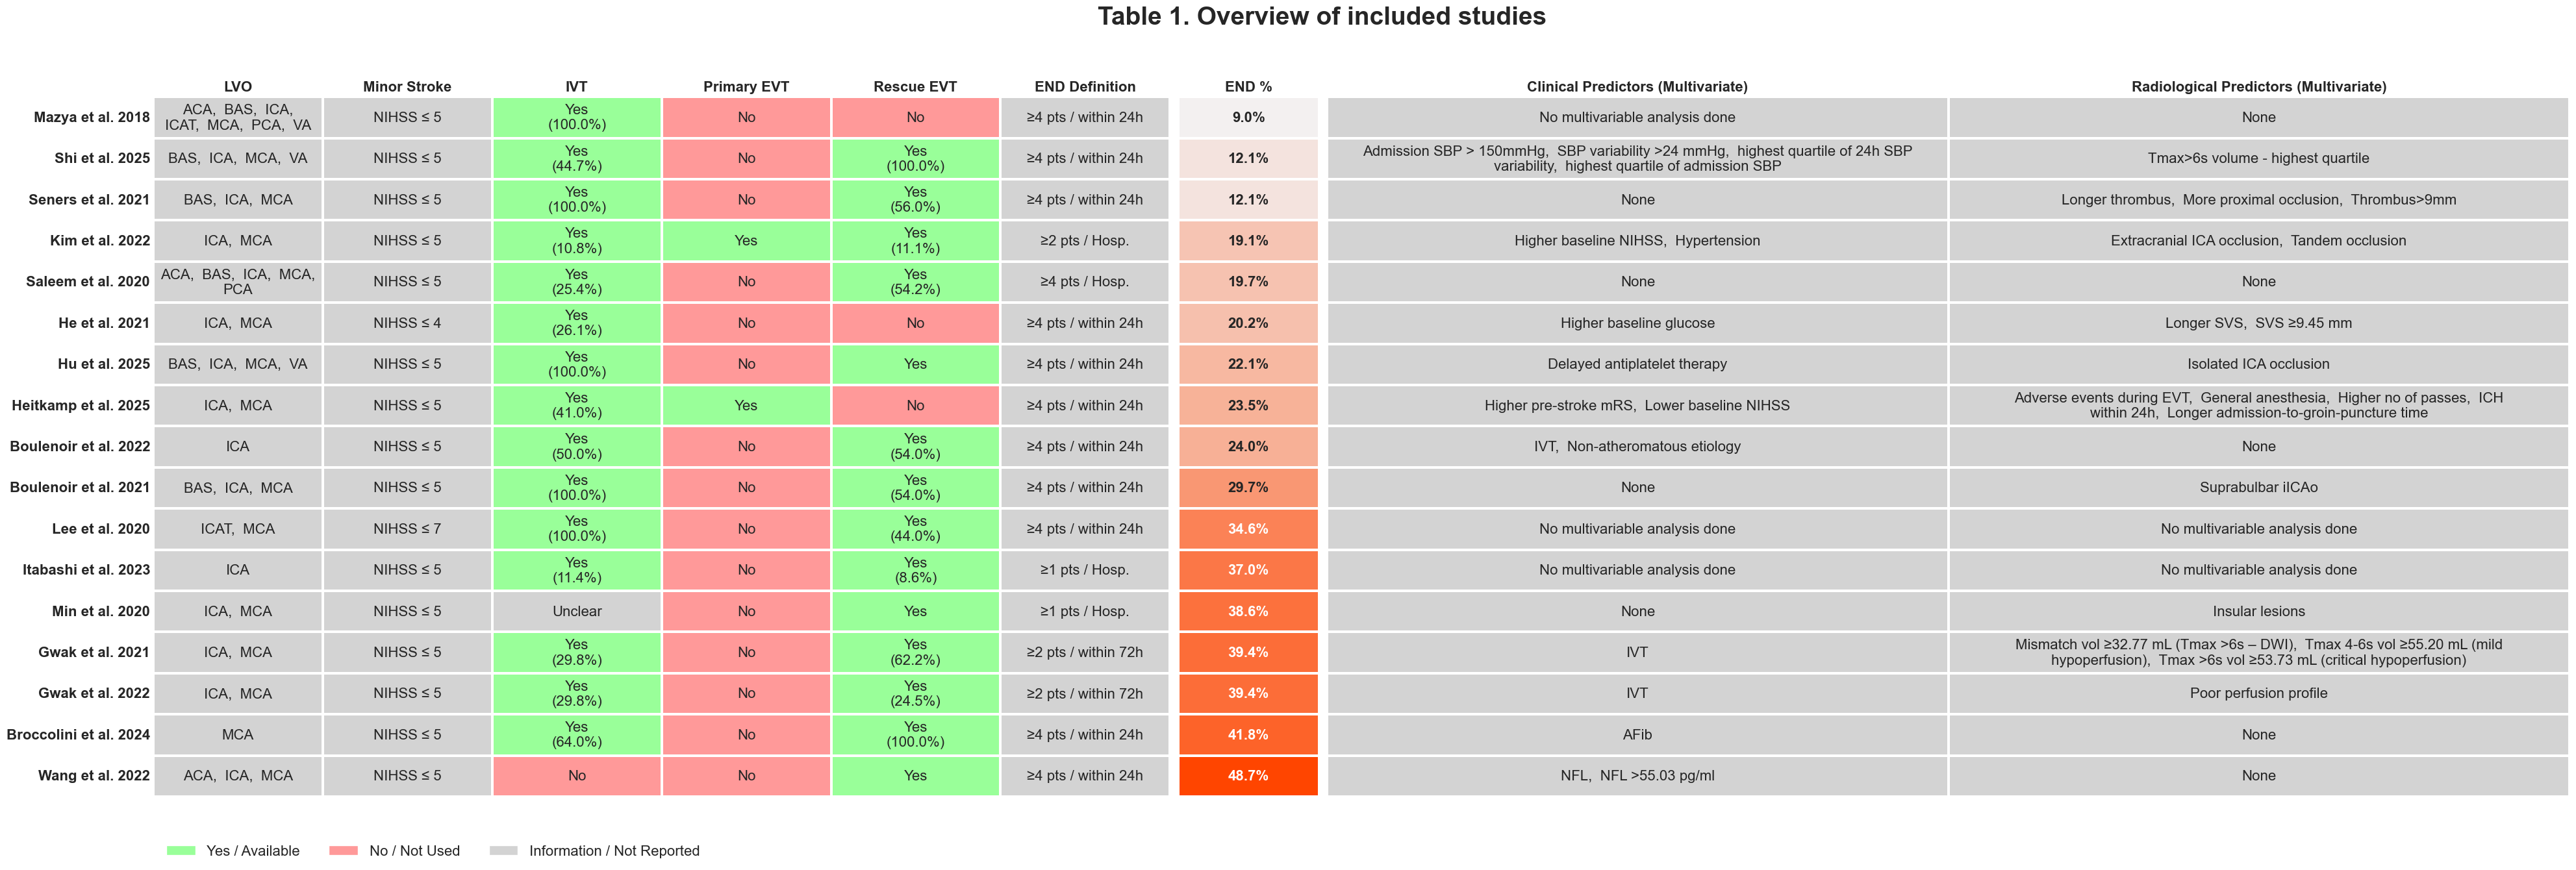

In [79]:
# 1. CLEAN AND SORT
df.columns = df.columns.str.strip().str.lower()
df = df.sort_values('pct_end', ascending=True).reset_index(drop=True)

# 2. SETUP COLORMAPS
# Table 1 & 3: Solid Red/Gray/Green
cat_cmap = ListedColormap(["#ff9999", "#d3d3d3", "#99ff99"]) 
color_map = {'No': 0, 'Unclear': 0.5, 'Yes': 1}

# Table 2 (END %): Sequential Gradient (Light Orange to Deep Red/Orange)
end_cmap = sns.light_palette("#ff4500", as_cmap=True) 

# 3. HELPERS
def safe_wrap(text, width=65): 
    if isinstance(text, (list, set, np.ndarray)):
        text = ", ".join(map(str, text)) if len(text) > 0 else "None"
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "n/a"]:
        return "None"
    return "\n".join(textwrap.wrap(str(text).replace(',', ', '), width=width))

def get_end_definition(row):
    delta, hours = row.get('end_delta_nihss'), row.get('end_hours')
    d_str = f"≥{int(delta)} pts" if pd.notna(delta) else "Any Δ"
    t_str = "Hosp." if pd.isna(hours) else f"within {int(hours)}h"
    return f"{d_str} / {t_str}"

# 4. DATA PREPARATION
# --- Group 1: Categorical ---
cols1 = ['LVO', 'Minor Stroke', 'IVT', 'Primary EVT', 'Rescue EVT', 'END Definition']
color_df1 = pd.DataFrame(index=df.index)
annot_df1 = pd.DataFrame(index=df.index)

for col in cols1:
    if col in ['IVT', 'Primary EVT', 'Rescue EVT']:
        key = col.lower().replace(' ', '_')
        color_df1[col] = df[key].map(color_map).fillna(0.5).values
    else: color_df1[col] = 0.5

annot_df1['LVO'] = [safe_wrap(x, 22) for x in df['lvo_definition_list']]
annot_df1['Minor Stroke'] = [f"NIHSS ≤ {int(x)}" if pd.notna(x) else "N/R" for x in df['ms_max_nihss']]
annot_df1['IVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['ivt'], df['pct_ivt'])]
annot_df1['Primary EVT'] = df['primary_evt'].astype(str).replace('nan', 'N/R')
annot_df1['Rescue EVT'] = [f"{v}\n({p*100:.1f}%)" if pd.notna(p) and p>0 else str(v) for v, p in zip(df['rescue_evt'], df['pct_rescue_evt_end'])]
annot_df1['END Definition'] = df.apply(get_end_definition, axis=1)

# --- Group 2: Gradient (END %) ---
# We use raw numeric values for the color intensity
end_values = df['pct_end'].fillna(0).values
annot_end = [f"{p*100:.1f}%" if pd.notna(p) else "N/R" for p in df['pct_end']]

# --- Group 3: Predictors ---
cols3 = ['Clinical Predictors (Multivariate)', 'Radiological Predictors (Multivariate)']
annot_df3 = pd.DataFrame(index=df.index)
annot_df3['Clinical Predictors (Multivariate)'] = [safe_wrap(x, 80) for x in df['clinical_predictors_multi_list']]
annot_df3['Radiological Predictors (Multivariate)'] = [safe_wrap(x, 80) for x in df['radiological_predictors_multi_list']]

# 5. PLOTTING
# width_ratios: [Categorical, Gradient, Narrative]
fig, (ax1, ax_end, ax2) = plt.subplots(1, 3, figsize=(48, 14), 
                                       gridspec_kw={'width_ratios': [1.8, 0.25, 2.2], 'wspace': 0.01})

# Table 1: Categorical
sns.heatmap(color_df1[cols1], annot=annot_df1[cols1], fmt="", cmap=cat_cmap, cbar=False, 
            vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 16}, ax=ax1)

# Table 2: Gradient END %
sns.heatmap(end_values.reshape(-1, 1), annot=np.array(annot_end).reshape(-1, 1), fmt="", 
            cmap=end_cmap, cbar=False, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 16, "weight": "bold"}, ax=ax_end)
ax_end.set_xticklabels(['END %'], fontsize=16, fontweight='bold')

# Table 3: Predictors
sns.heatmap(pd.DataFrame(0.5, index=df.index, columns=cols3), annot=annot_df3, fmt="", 
            cmap=cat_cmap, cbar=False, vmin=0, vmax=1, linewidths=1.5, linecolor='white', 
            annot_kws={"size": 16, "va": "center"}, ax=ax2)

# 6. LEGEND
legend_elements = [
    Patch(facecolor='#99ff99', edgecolor='white', label='Yes / Available'),
    Patch(facecolor='#ff9999', edgecolor='white', label='No / Not Used'),
    Patch(facecolor='#d3d3d3', edgecolor='white', label='Information / Not Reported')
]
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, -0.05), 
           ncol=3, fontsize=16, frameon=False)

# 7. FINAL FORMATTING
ax1.set_yticklabels(df['display_name'], rotation=0, fontsize=16, fontweight='bold')
ax_end.set_yticklabels([]); ax2.set_yticklabels([])

for ax in [ax1, ax_end, ax2]:
    ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_ylabel("")

plt.setp(ax1.get_xticklabels(), fontsize=16, fontweight='bold')
plt.setp(ax2.get_xticklabels(), fontsize=16, fontweight='bold')

fig.suptitle('Table 1. Overview of included studies', 
             fontsize=28, fontweight='bold')

plt.tight_layout()
plt.savefig("Master_Matrix_Gradient.pdf", bbox_inches='tight')
plt.show()